In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from datetime import datetime
from pathlib import Path
from IPython.display import display, Markdown

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from datetime import datetime

def docker_stats_analysis(file_path, target_container, db_container="cw_db_test",cache_container="cw_cache_test"):
    if not os.path.exists(file_path):
        return

    with open(file_path, 'r') as f:
        data = json.load(f)
    
    data_list = data if isinstance(data, list) else [data]
    
    rows = []
    # Only keep the specific app container and the database
    target_names = [target_container.strip('/'), db_container, cache_container]

    for entry in data_list:
        ts = datetime.fromtimestamp(entry['timestamp'])
        for name, stats in entry['containers'].items():
            clean_name = name.strip('/')
            
            if clean_name not in target_names:
                continue

            cpu_delta = stats['cpu_stats']['cpu_usage']['total_usage'] - stats['precpu_stats']['cpu_usage']['total_usage']
            sys_delta = stats['cpu_stats']['system_cpu_usage'] - stats['precpu_stats']['system_cpu_usage']
            cpus = stats['cpu_stats'].get('online_cpus', 1)
            cpu_pct = (cpu_delta / sys_delta) * cpus * 100.0 if sys_delta > 0 else 0

            blkio = stats.get('blkio_stats', {}).get('io_service_bytes_recursive') or []

            rows.append({
                'timestamp': ts,
                'container': clean_name,
                'cpu_pct': cpu_pct,
                'mem_mb': stats['memory_stats']['usage'] / (1024**2),
                'net_rx_kb': sum(n['rx_bytes'] for n in stats['networks'].values()) / 1024,
                'net_tx_kb': sum(n['tx_bytes'] for n in stats['networks'].values()) / 1024,
                'io_read_kb': sum(i['value'] for i in blkio if i.get('op') == 'read') / 1024,
                'io_write_kb': sum(i['value'] for i in blkio if i.get('op') == 'write') / 1024,
                'pids': stats['pids_stats'].get('current', 0)
            })
    
    if not rows:
        print(f"No data found for containers: {target_names}")
        return

    df = pd.DataFrame(rows).sort_values(['container', 'timestamp'])
    
    for col in ['net_rx_kb', 'net_tx_kb', 'io_read_kb', 'io_write_kb']:
        df[f'{col}_rate'] = df.groupby('container')[col].diff().fillna(0)

    test_name = os.path.basename(file_path)
    summary = df.groupby('container').agg({
        'cpu_pct': ['mean', 'max'],
        'mem_mb': ['mean', 'max'],
        'pids': 'max'
    }).round(2)
    
    print(f"--- {test_name} ---")
    print(summary)

    sns.set_theme(style="darkgrid")
    fig, axes = plt.subplots(4, 2, figsize=(18, 22))
    fig.suptitle(f"{test_name} ({target_container} vs {db_container})", fontsize=22, y=1.02, fontweight='bold')

    plots = [
        ('cpu_pct', 'CPU %', axes[0, 0], 'magma'),
        ('mem_mb', 'Memory (MB)', axes[0, 1], 'viridis'),
        ('net_rx_kb_rate', 'Net RX (KB/Δ)', axes[1, 0], 'Blues_d'),
        ('net_tx_kb_rate', 'Net TX (KB/Δ)', axes[1, 1], 'Greens_d'),
        ('io_read_kb_rate', 'IO Read (KB/Δ)', axes[2, 0], 'Purples_d'),
        ('io_write_kb_rate', 'IO Write (KB/Δ)', axes[2, 1], 'Oranges_d'),
        ('pids', 'PIDs', axes[3, 0], 'rocket'),
        ('cpu_pct', 'CPU Var', axes[3, 1], 'magma')
    ]

    for i, (col, title, ax, pal) in enumerate(plots):
        if i == 7:
            sns.boxplot(data=df, x='container', y=col, ax=ax, palette=pal, hue='container', legend=False)
        else:
            sns.lineplot(data=df, x='timestamp', y=col, hue='container', ax=ax, palette=pal, marker='o', markersize=4)
        
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=35)

    plt.tight_layout()
    output_filename = os.path.basename(file_path).replace('.json', '_analysis.png')
    folder = os.path.dirname(file_path)
    output_path = os.path.join(folder, output_filename)
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"Diagram exported as: {output_path}")
    plt.show()

# Example usage:
# analyze_docker_test('your_file.json', 'cw_fastapi_baseline')

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
import numpy as np
from pathlib import Path

def hey_stats_analysis(path: Path):
    try:
        df = pd.read_csv(path)
        if 'response-time' not in df.columns:
            df = pd.read_csv(path, sep=r'\s+')
    except Exception:
        return

    response_times = pd.to_numeric(df['response-time'], errors='coerce').dropna()

    fig, axes = plt.subplots(1, 3, figsize=(22, 6), gridspec_kw={'width_ratios': [2, 2, 1]})

    ax1 = axes[0]
    sns.histplot(response_times, bins=50, stat='density', alpha=0.6, color='steelblue', label='Actual Data', ax=ax1)

    mu, std = norm.fit(response_times)
    xmin, xmax = ax1.get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, std)
    
    ax1.plot(x, p, 'k', linewidth=2, label=f'Normal Fit\n(mu={mu:.4f}, std={std:.4f})')
    ax1.set_title('Response Time Distribution')
    ax1.set_xlabel('Response Time (s)')
    ax1.set_ylabel('Density')
    ax1.legend()

    ax2 = axes[1]
    ax2.plot(response_times.index, response_times, color='crimson', linewidth=1, alpha=0.8)
    
    window_size = max(int(len(response_times) * 0.05), 1) 
    if len(response_times) > window_size:
        rolling_mean = response_times.rolling(window=window_size).mean()
        ax2.plot(response_times.index, rolling_mean, color='black', linestyle='--', linewidth=1.5, label=f'{window_size}-Req Moving Avg')
        ax2.legend()

    ax2.set_title('Response Time Evolution (Sequential)')
    ax2.set_xlabel('Request Number')
    ax2.set_ylabel('Response Time (s)')
    ax2.grid(True, linestyle='--', alpha=0.5)

    ax3 = axes[2]
    ax3.axis('off')
    
    stats_text = (
        f"Backend Response Stats:\n\n"
        f"Total Requests: {len(response_times)}\n"
        f"Mean:   {response_times.mean():.5f} s\n"
        f"Median: {response_times.median():.5f} s\n"
        f"StdDev: {response_times.std():.5f} s\n"
        f"Min:    {response_times.min():.5f} s\n"
        f"Max:    {response_times.max():.5f} s\n"
        f"p90:    {np.percentile(response_times, 90):.5f} s\n"
        f"p95:    {np.percentile(response_times, 95):.5f} s\n"
        f"p99:    {np.percentile(response_times, 99):.5f} s\n"
    )
    
    ax3.text(0.1, 0.5, stats_text, fontsize=12, family='monospace', va='center')
    ax3.set_title('Statistical Summary')

    plt.tight_layout()
    output_filename = os.path.basename(path).replace('.csv', '_analysis.png')
    folder = os.path.dirname(path)
    output_path = os.path.join(folder, output_filename)
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"Diagram exported as: {output_path}")
    plt.show()

In [4]:
import json
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def locust_stats_analysis(path):
    if not os.path.exists(path):
        return

    with open(path, 'r') as f:
        data = json.load(f)

    raw_stats = []
    for entry in data:
        name = entry.get('name', 'unknown')
        
        # Grouping logic: replaces specific IDs with a generic placeholder
        # Converts "/recipes/recipes/94" -> "/recipes/recipes/{id}"
        group_name = re.sub(r'/\d+', '/{id}', name)
        
        raw_stats.append({
            'Endpoint': group_name,
            'Requests': entry.get('num_requests', 0),
            'Failures': entry.get('num_failures', 0),
            'Total_RT': entry.get('total_response_time', 0),
            'Max_RT': entry.get('max_response_time', 0),
            'Min_RT': entry.get('min_response_time', 0),
            'Content': entry.get('total_content_length', 0),
            'Start': entry.get('start_time', 0),
            'End': entry.get('last_request_timestamp', 0)
        })

    full_df = pd.DataFrame(raw_stats)
    
    # Aggregate data by the new grouped Endpoint name
    df = full_df.groupby('Endpoint').agg({
        'Requests': 'sum',
        'Failures': 'sum',
        'Total_RT': 'sum',
        'Max_RT': 'max',
        'Min_RT': 'min',
        'Content': 'sum',
        'Start': 'min',
        'End': 'max'
    }).reset_index()

    df['Avg RT (ms)'] = df['Total_RT'] / df['Requests']
    df['Duration'] = df['End'] - df['Start']
    df['RPS'] = df['Requests'] / df['Duration'].replace(0, 1)
    df['Total MB'] = df['Content'] / (1024**2)

    df = df.sort_values('Requests', ascending=False)

    print(f"--- Grouped Locust Analysis: {os.path.basename(path)} ---")
    print(df[['Endpoint', 'Requests', 'Avg RT (ms)', 'Max_RT', 'RPS']].to_string(index=False))

    sns.set_theme(style="darkgrid")
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f"Aggregated Performance: {os.path.basename(path)}", fontsize=20, fontweight='bold')

    # Fix for FutureWarnings: using hue=Endpoint and legend=False
    metrics = [
        ('Requests', 'Request Distribution', axes[0, 0], 'viridis'),
        ('Avg RT (ms)', 'Average Latency (ms)', axes[0, 1], 'magma'),
        ('RPS', 'Throughput (Req/s)', axes[1, 0], 'rocket'),
        ('Max_RT', 'Worst Case Latency (ms)', axes[1, 1], 'flare')
    ]

    for i, (col, title, ax, pal) in enumerate(metrics):
        sns.barplot(data=df, x=col, y='Endpoint', ax=ax, palette=pal, hue='Endpoint', legend=False)
        ax.set_title(title, fontweight='bold')
        ax.set_ylabel('')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    output_filename = os.path.basename(path).replace('.json', '_analysis.png')
    folder = os.path.dirname(path)
    output_path = os.path.join(folder, output_filename)
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"Diagram exported as: {output_path}")
    plt.show()

In [5]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def k6_stats_analysis(path):
    if not os.path.exists(path):
        print(f"Error: {path} not found.")
        return

    with open(path, 'r') as f:
        data = json.load(f)

    metrics = data.get('metrics', {})
    
    total_reqs = metrics.get('http_reqs', {}).get('count', 0)
    rps = metrics.get('http_reqs', {}).get('rate', 0)
    fail_rate = metrics.get('http_req_failed', {}).get('value', 0) * 100
    vus_max = metrics.get('vus_max', {}).get('value', 0)
    
    duration = metrics.get('http_req_duration', {})
    waiting = metrics.get('http_req_waiting', {})
    connecting = metrics.get('http_req_connecting', {})

    print(f"{'='*40}")
    print(f" K6 LOAD TEST ANALYSIS: {os.path.basename(path)}")
    print(f"{'='*40}")
    print(f"Throughput:      {rps:.2f} req/s")
    print(f"Total Requests:  {total_reqs:,}")
    print(f"Max Concurrency: {vus_max} VUs")
    print(f"Failure Rate:    {fail_rate:.2f}%")
    print(f"{'-'*40}")
    print(f"Latency (Duration):")
    print(f"  Avg: {duration.get('avg', 0):.2f}ms")
    print(f"  Med: {duration.get('med', 0):.2f}ms")
    print(f"  p(90): {duration.get('p(90)', 0):.2f}ms")
    print(f"  p(95): {duration.get('p(95)', 0):.2f}ms")
    print(f"  Max: {duration.get('max', 0):.2f}ms")
    print(f"{'='*40}\n")

    sns.set_theme(style="whitegrid")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    latency_data = {
        'Metric': ['Connecting', 'Waiting (TTFB)', 'Receiving/Sending'],
        'Time (ms)': [
            connecting.get('avg', 0),
            waiting.get('avg', 0),
            max(0, duration.get('avg', 0) - waiting.get('avg', 0) - connecting.get('avg', 0))
        ]
    }
    
    df_latency = pd.DataFrame(latency_data)
    sns.barplot(data=df_latency, x='Metric', y='Time (ms)', ax=ax1, palette='mako', hue='Metric', legend=False)
    ax1.set_title("Average Latency Breakdown", fontweight='bold')

    percentiles = {
        'p(90)': duration.get('p(90)', 0),
        'p(95)': duration.get('p(95)', 0),
        'Avg': duration.get('avg', 0),
        'Med': duration.get('med', 0)
    }
    df_p = pd.DataFrame(list(percentiles.items()), columns=['Percentile', 'ms'])
    sns.barplot(data=df_p, x='Percentile', y='ms', ax=ax2, palette='flare', hue='Percentile', legend=False)
    ax2.set_title("Duration Percentiles", fontweight='bold')
    plt.tight_layout()
    output_filename = os.path.basename(path).replace('.json', '_analysis.png')
    folder = os.path.dirname(path)
    output_path = os.path.join(folder, output_filename)
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"Diagram exported as: {output_path}")
    plt.show()

# ITERATION 1

---

# locust_v_1_0_0 / axum

---

## System Usage

---

--- raw_docker_metrics.json ---
             cpu_pct         mem_mb         pids
                mean    max    mean     max  max
container                                       
cw_axum_test   12.21  13.92   26.04   26.38    6
cw_db_test     34.82  54.37  754.47  754.95  109
Diagram exported as: test_results/locust_v_1_0_0/1/axum/raw_docker_metrics_analysis.png


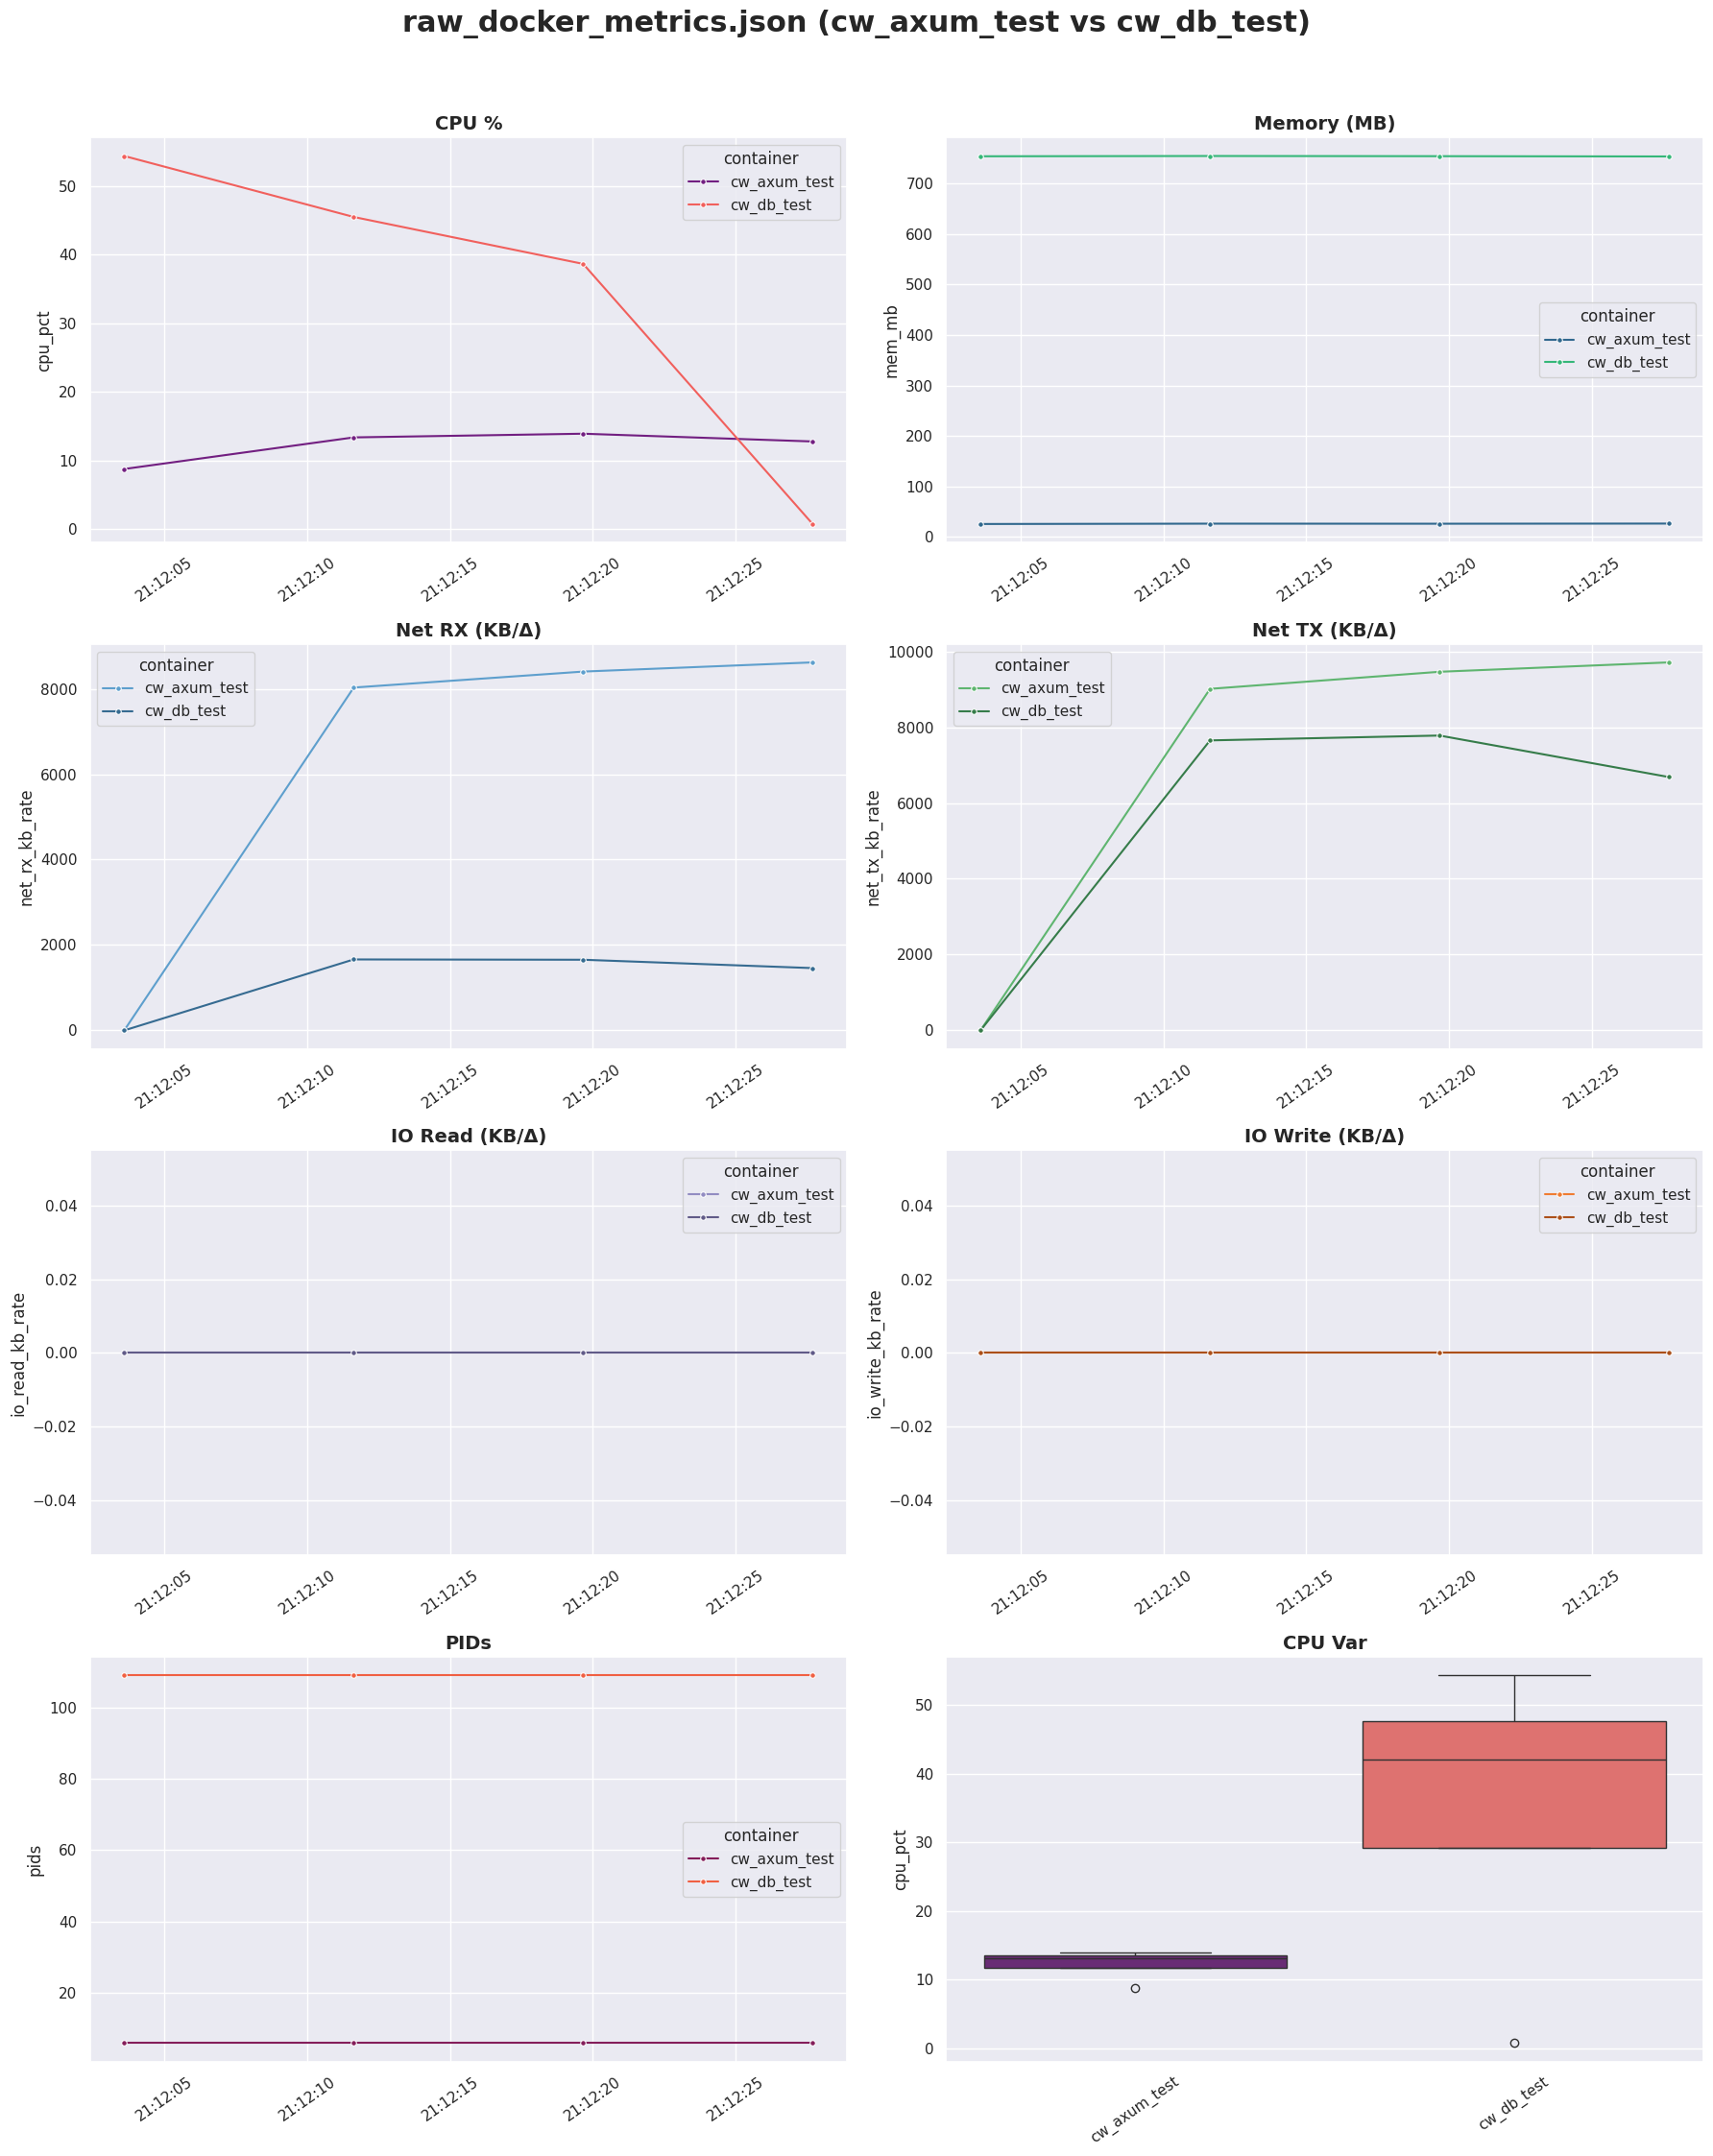

## Test Results

---

--- Grouped Locust Analysis: test_details.json ---
             Endpoint  Requests  Avg RT (ms)      Max_RT        RPS
 /recipes/recipe/{id}      3563    29.163619 3021.022077 119.196671
/recipes/recipes/{id}      3557     8.933586 3023.208303 118.970172
      /recipes/dishes      1679    14.654554 3018.539846  56.159859
Diagram exported as: test_results/locust_v_1_0_0/1/axum/test_details_analysis.png


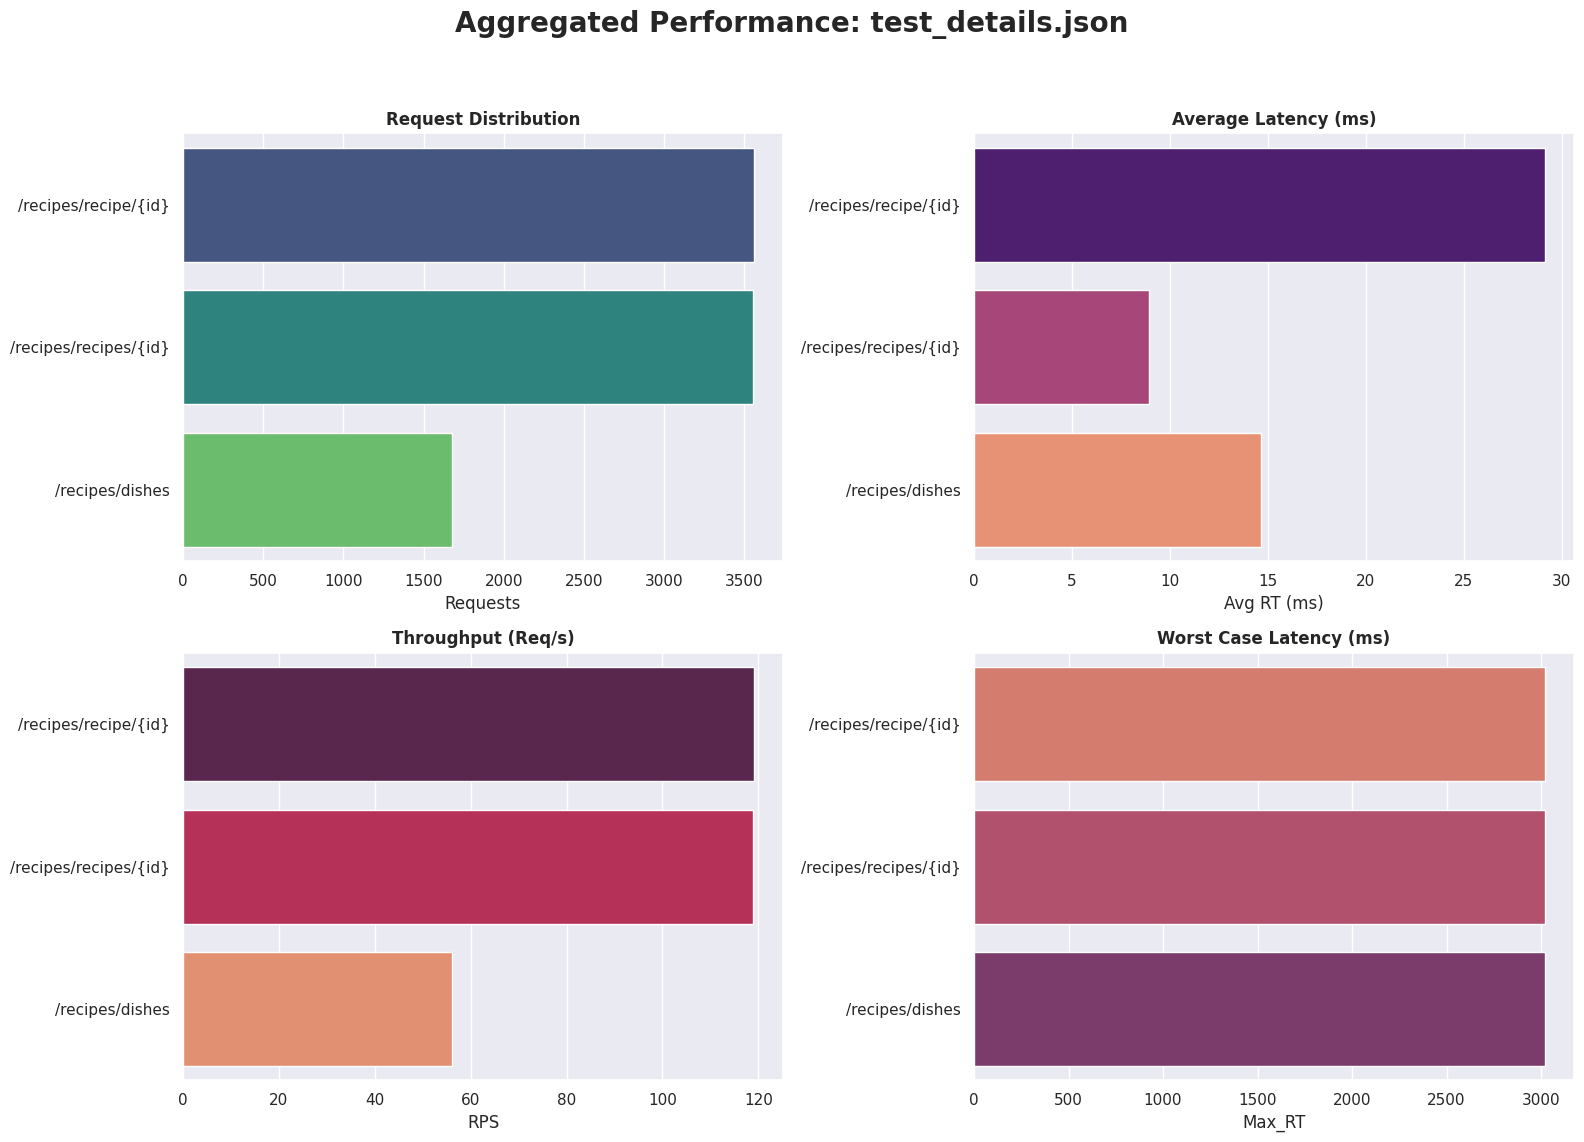

# locust_v_1_0_0 / custom

---

## System Usage

---

--- raw_docker_metrics.json ---
               cpu_pct         mem_mb         pids
                  mean    max    mean     max  max
container                                         
cw_custom_test   11.05  14.12   14.73   15.09   10
cw_db_test       50.54  83.42  754.19  754.67  109
Diagram exported as: test_results/locust_v_1_0_0/1/custom/raw_docker_metrics_analysis.png


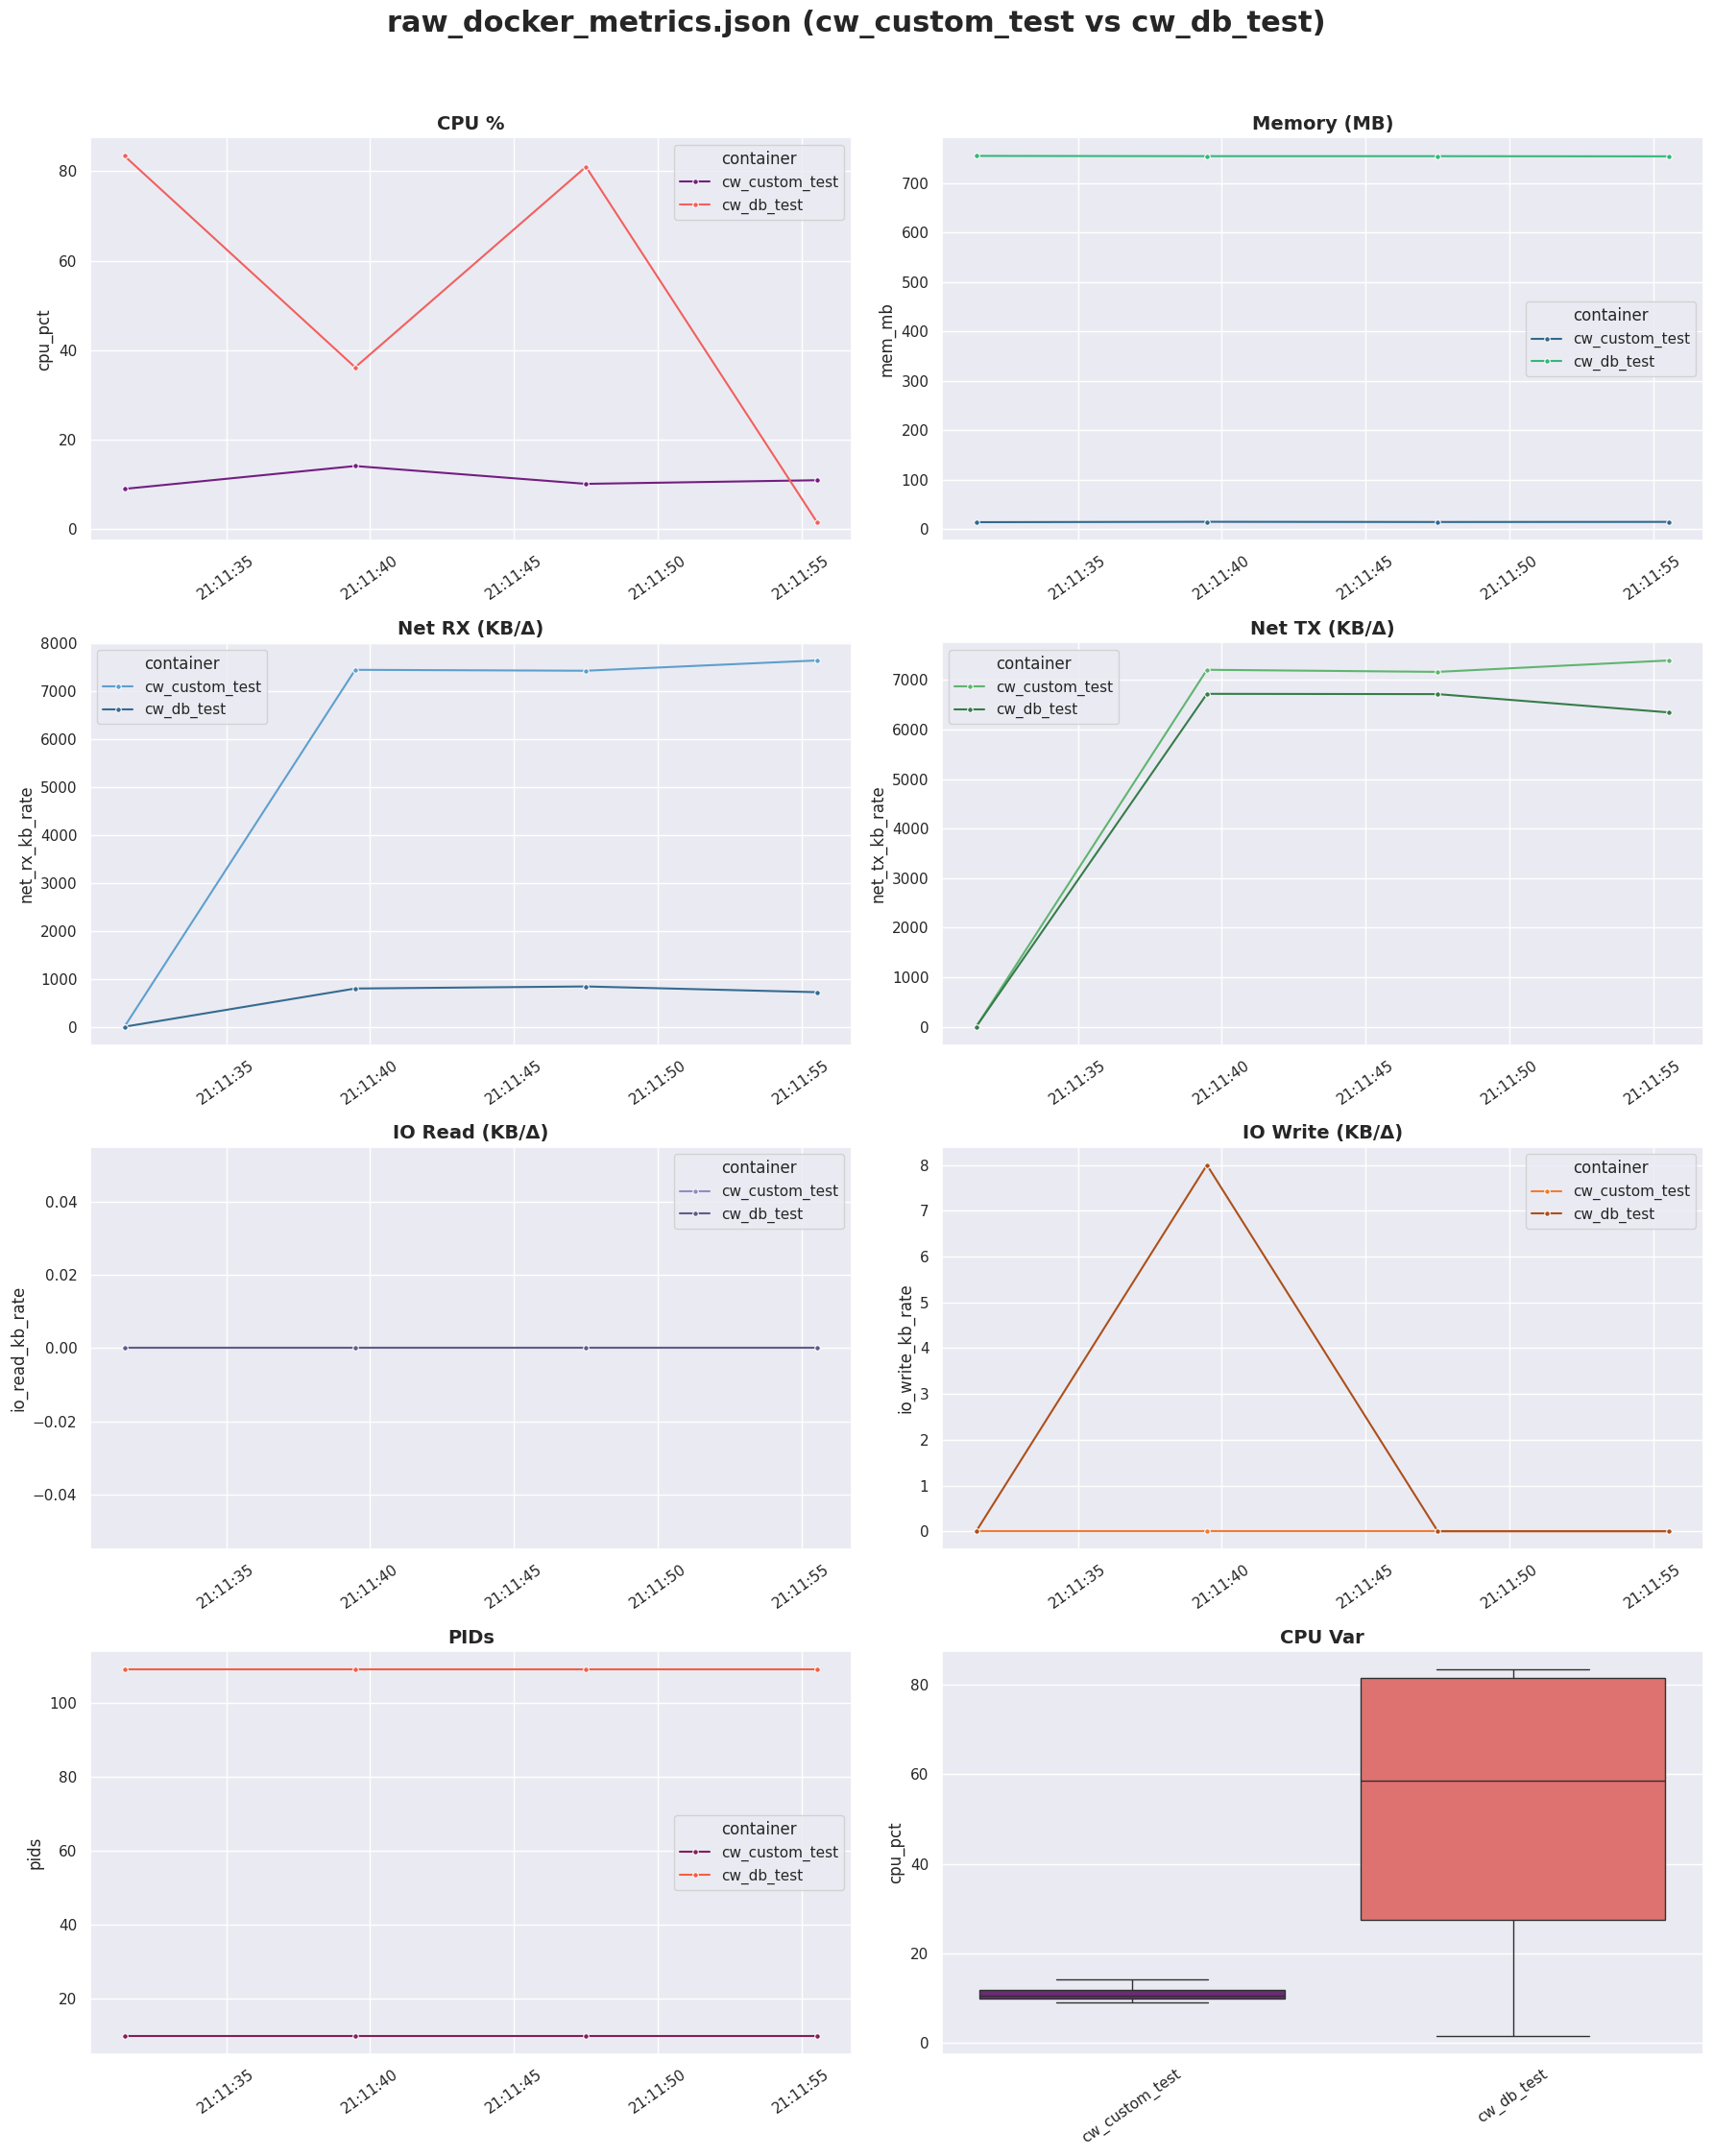

## Test Results

---

--- Grouped Locust Analysis: test_details.json ---
             Endpoint  Requests  Avg RT (ms)      Max_RT        RPS
/recipes/recipes/{id}      3031    62.780535 3017.731151 101.400915
 /recipes/recipe/{id}      2965    70.938875 3018.077697 102.577911
      /recipes/dishes      1540    77.505831 3020.830258  52.305752
Diagram exported as: test_results/locust_v_1_0_0/1/custom/test_details_analysis.png


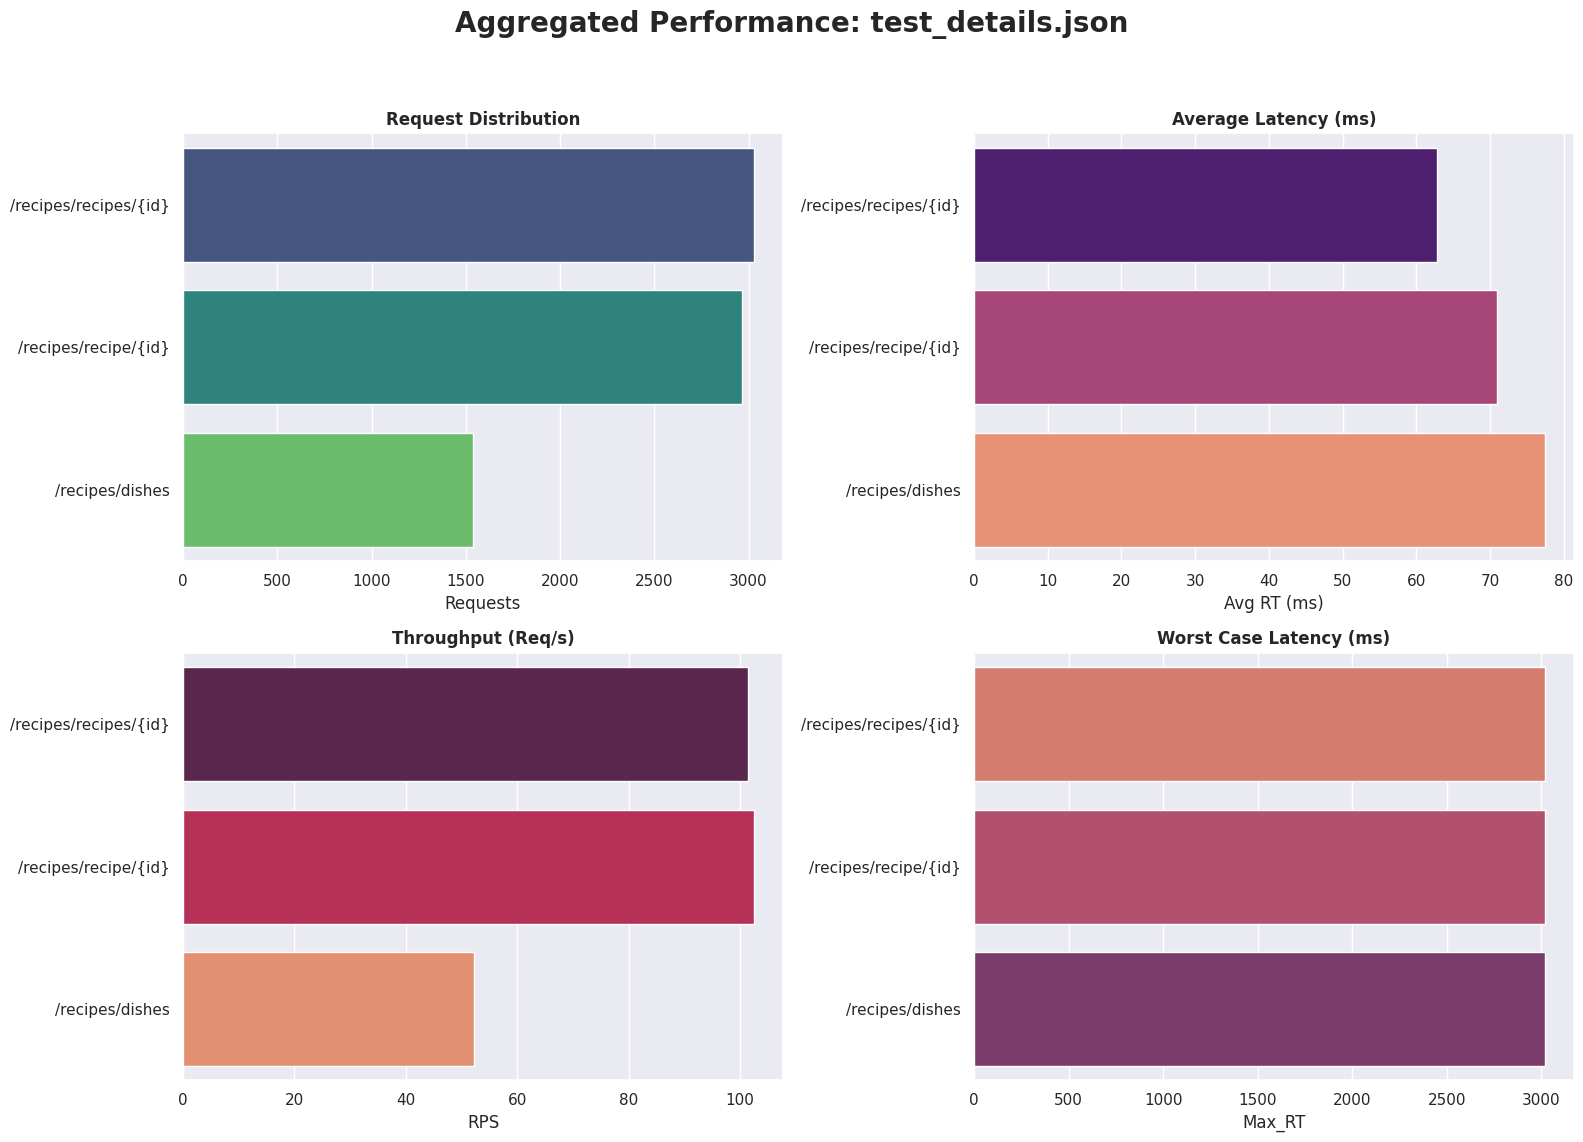

# locust_v_1_0_0 / fastapi

---

## System Usage

---

--- raw_docker_metrics.json ---
                    cpu_pct          mem_mb         pids
                       mean     max    mean     max  max
container                                               
cw_db_test            40.86   63.17  594.72  596.52   50
cw_fastapi_baseline  105.28  135.56  423.41  424.70   32
Diagram exported as: test_results/locust_v_1_0_0/1/fastapi/raw_docker_metrics_analysis.png


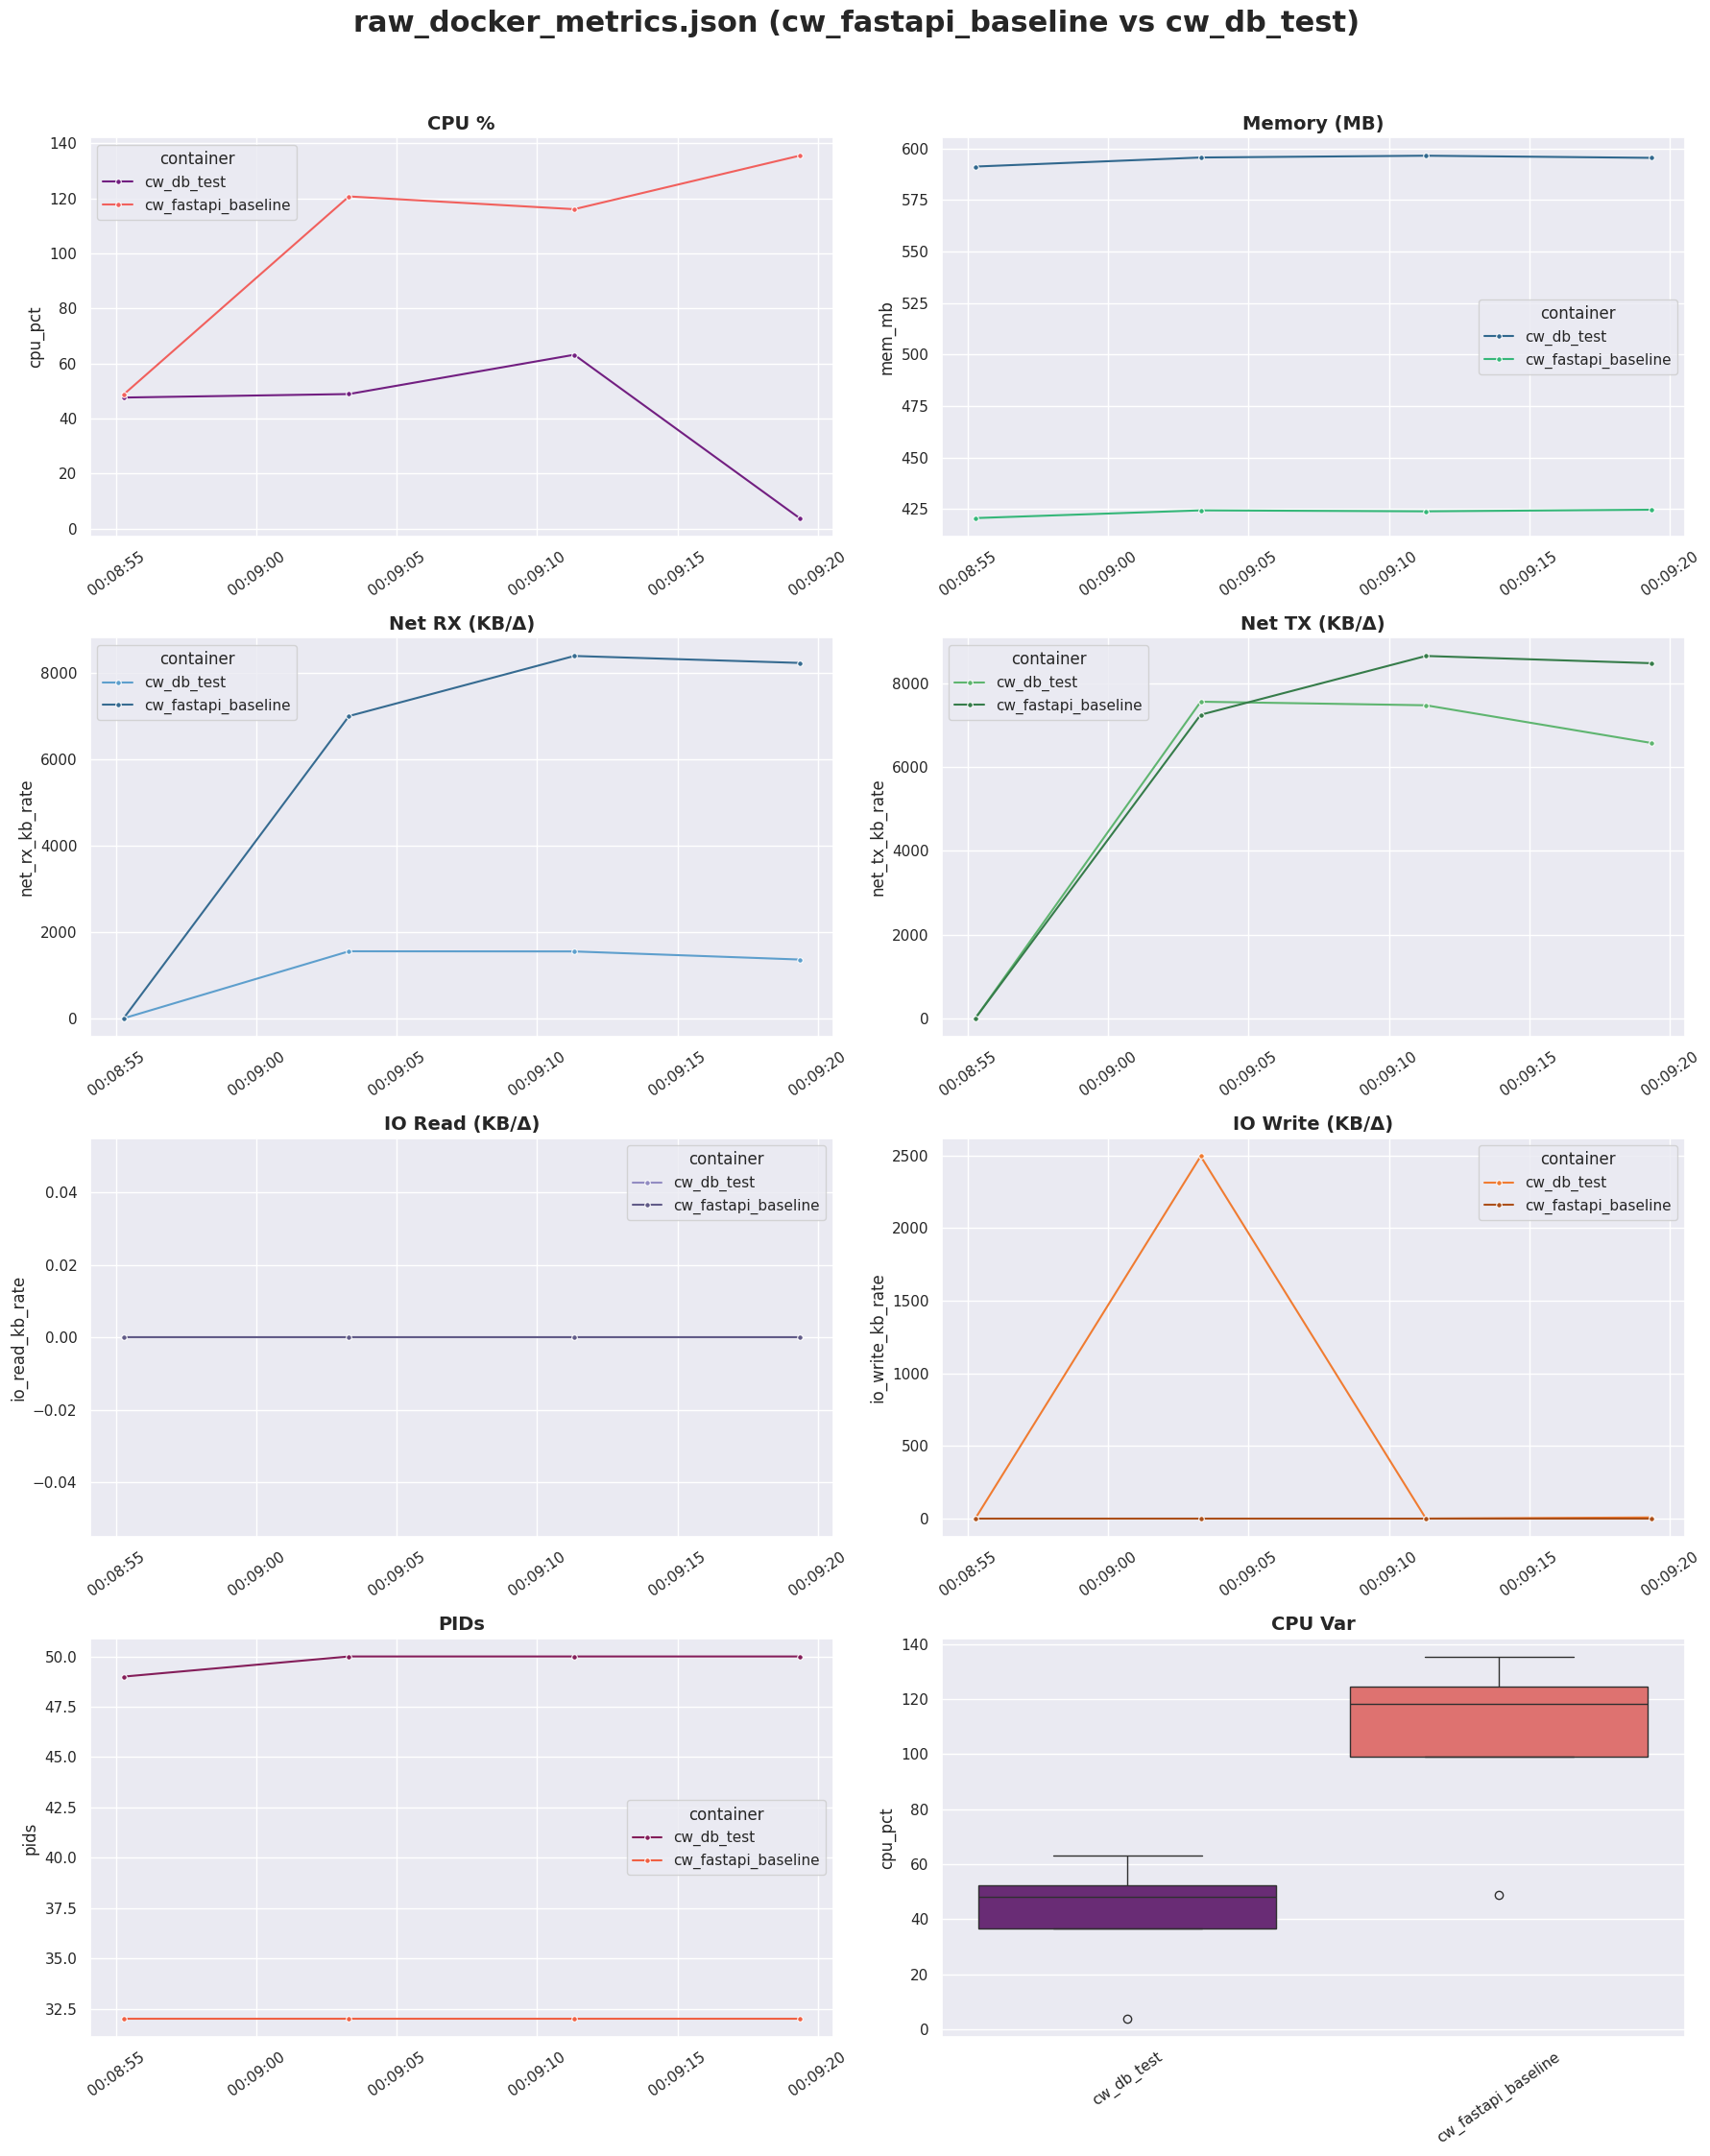

## Test Results

---

--- Grouped Locust Analysis: test_details.json ---
             Endpoint  Requests  Avg RT (ms)     Max_RT        RPS
 /recipes/recipe/{id}      3658    12.809592 124.800284 122.256177
/recipes/recipes/{id}      3644     5.230918 119.716149 121.894655
      /recipes/dishes      1788     5.594788  75.918306  59.796287
Diagram exported as: test_results/locust_v_1_0_0/1/fastapi/test_details_analysis.png


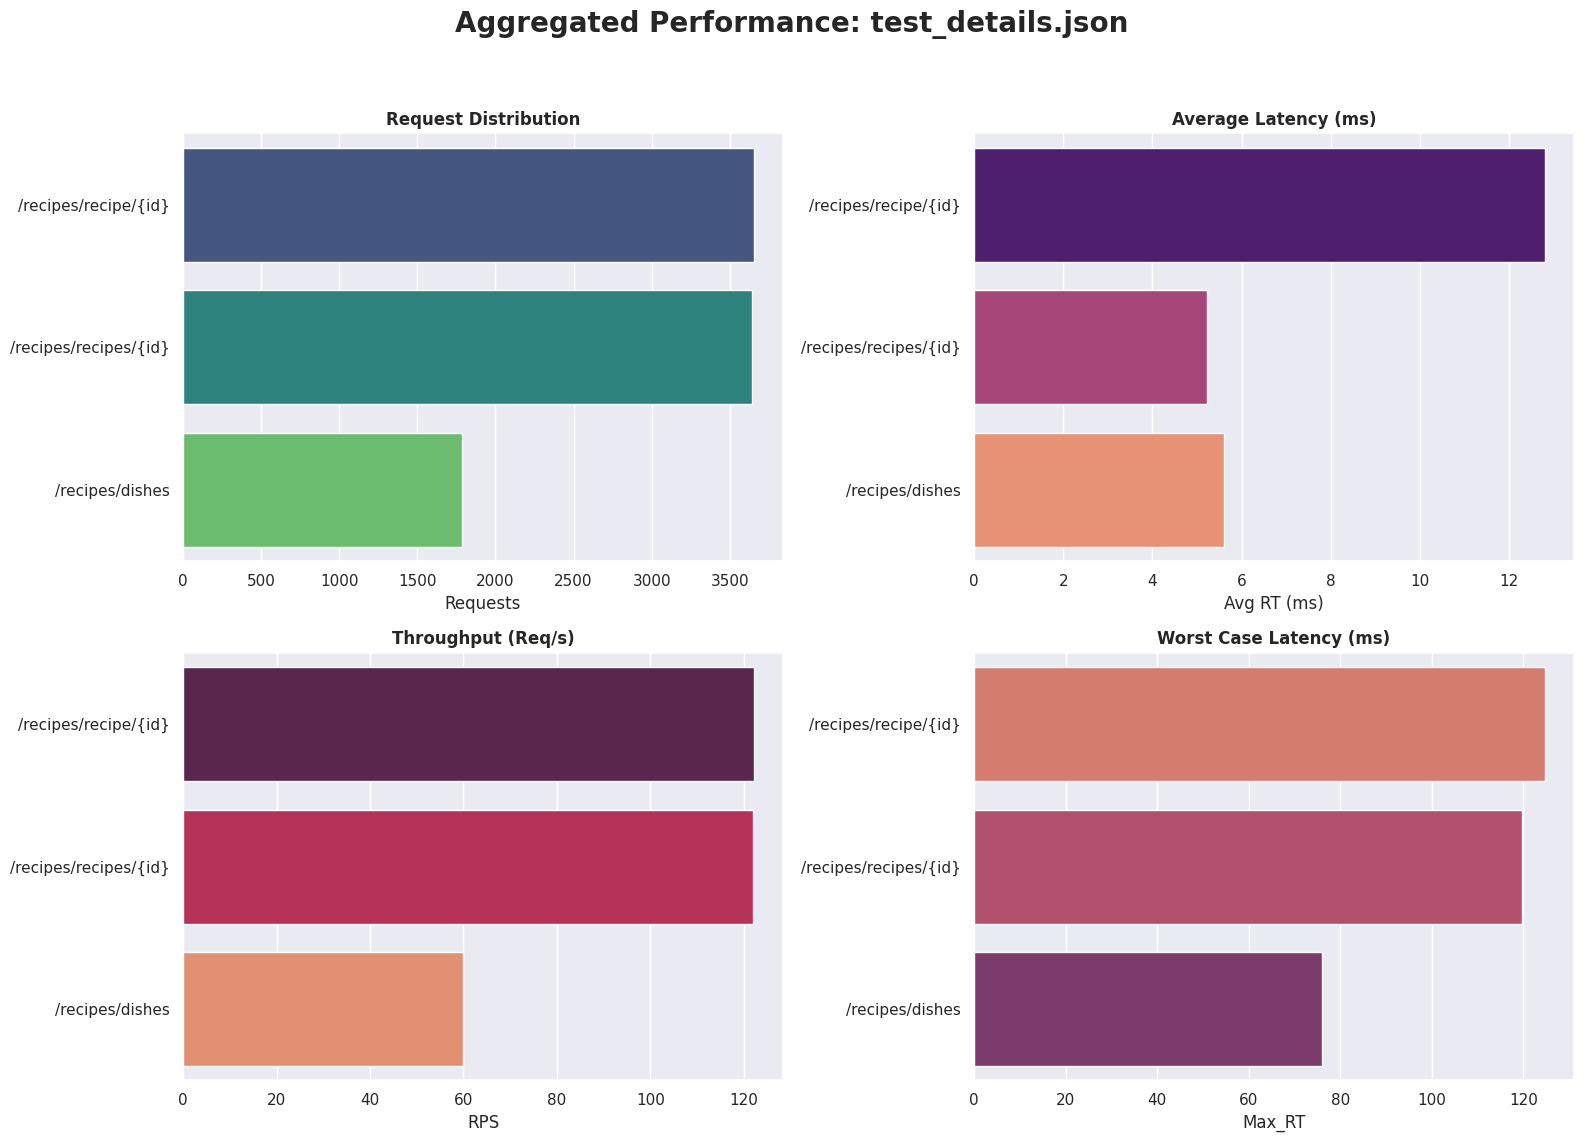

# k6_break_test / axum

---

## System Usage

---

--- raw_docker_metrics.json ---
             cpu_pct          mem_mb         pids
                mean     max    mean     max  max
container                                        
cw_axum_test   36.93   78.24   33.44   36.98    6
cw_db_test     94.27  138.22  757.87  758.72  109
Diagram exported as: test_results/k6_break_test/1/axum/raw_docker_metrics_analysis.png


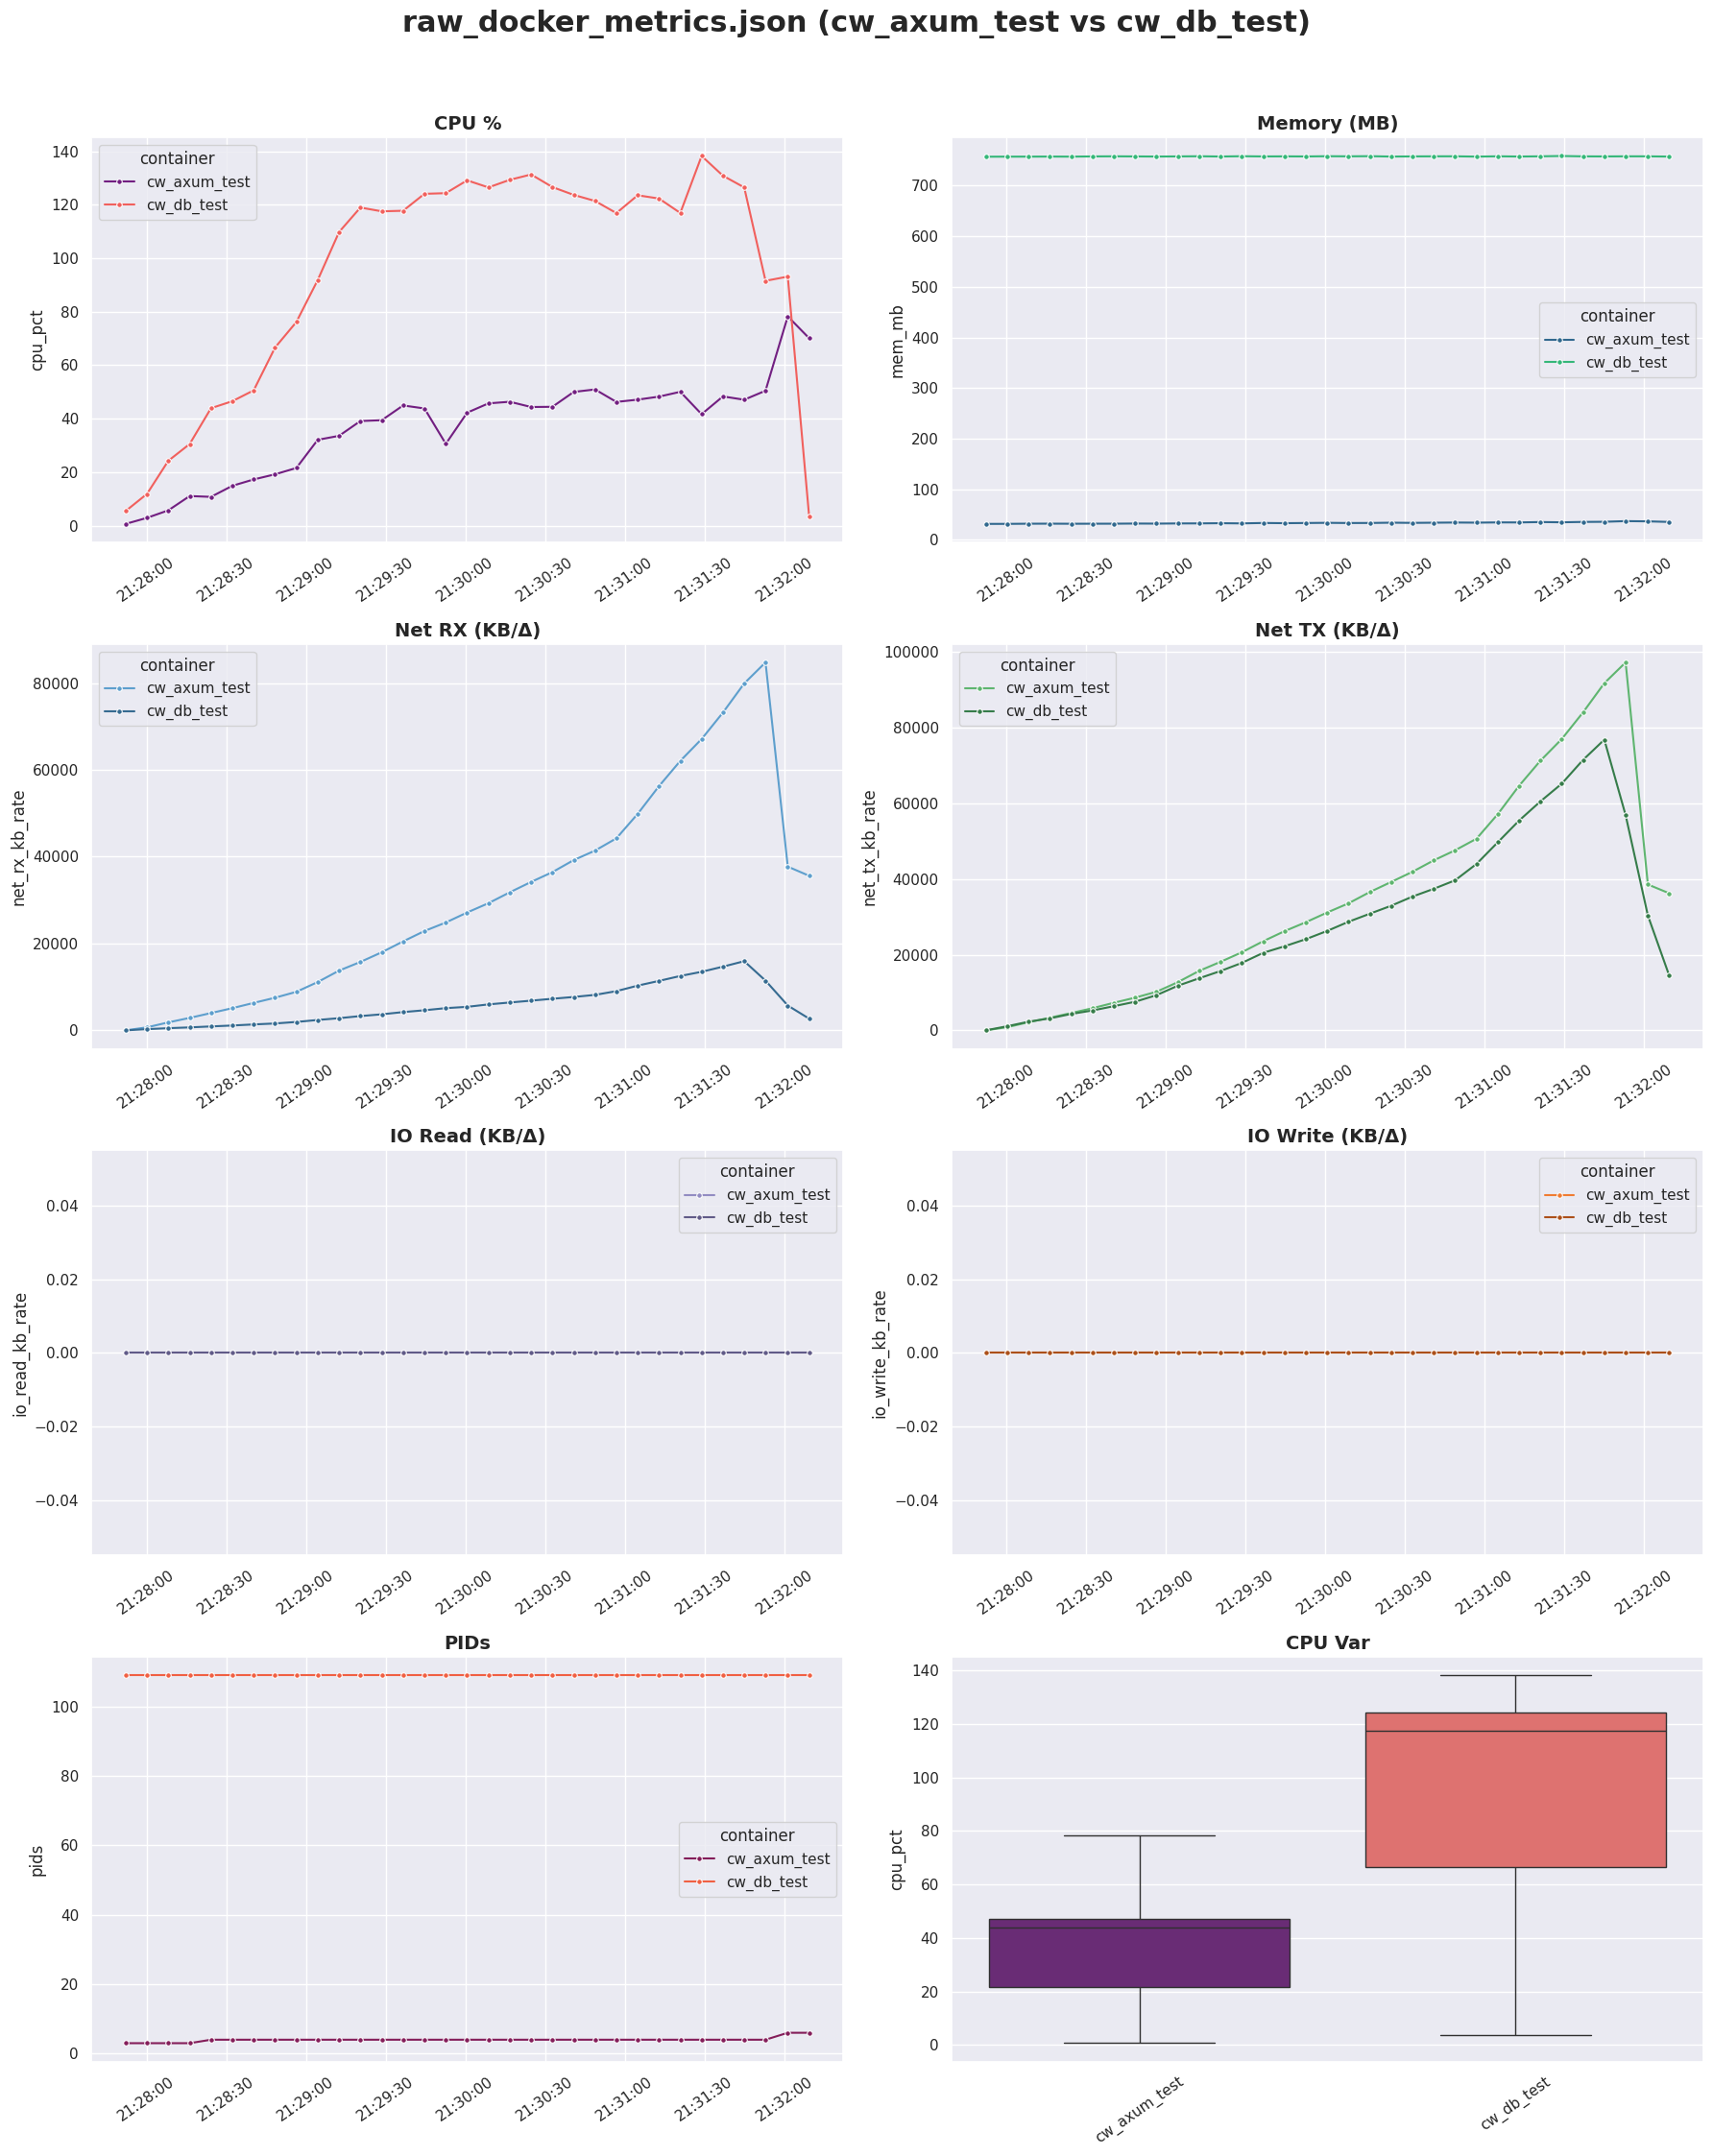

## Test Results

---

 K6 LOAD TEST ANALYSIS: test_details.json
Throughput:      1301.32 req/s
Total Requests:  335,625
Max Concurrency: 50000 VUs
Failure Rate:    10.15%
----------------------------------------
Latency (Duration):
  Avg: 3.24ms
  Med: 0.98ms
  p(90): 4.40ms
  p(95): 6.11ms
  Max: 3028.69ms

Diagram exported as: test_results/k6_break_test/1/axum/test_details_analysis.png


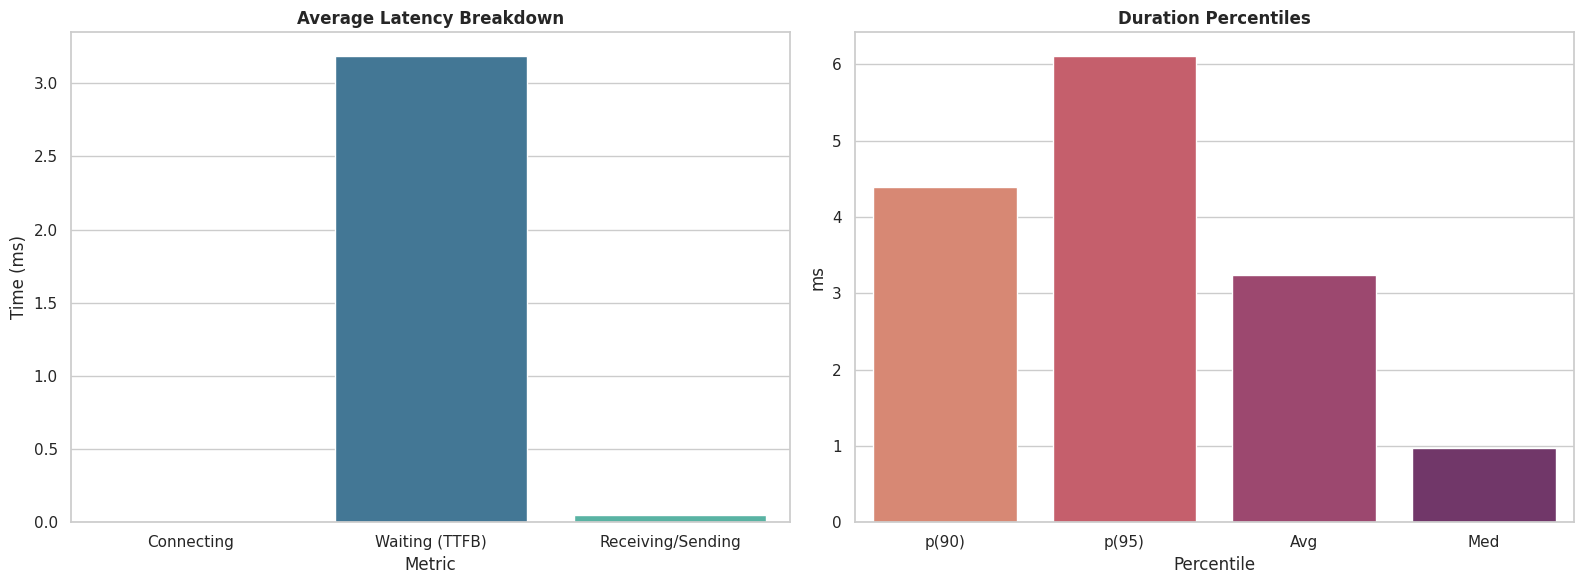

# k6_break_test / custom

---

## System Usage

---

--- raw_docker_metrics.json ---
               cpu_pct          mem_mb         pids
                  mean     max    mean     max  max
container                                          
cw_custom_test   72.29  101.81   25.85   30.21   20
cw_db_test       76.25  179.06  758.02  761.34  113
Diagram exported as: test_results/k6_break_test/1/custom/raw_docker_metrics_analysis.png


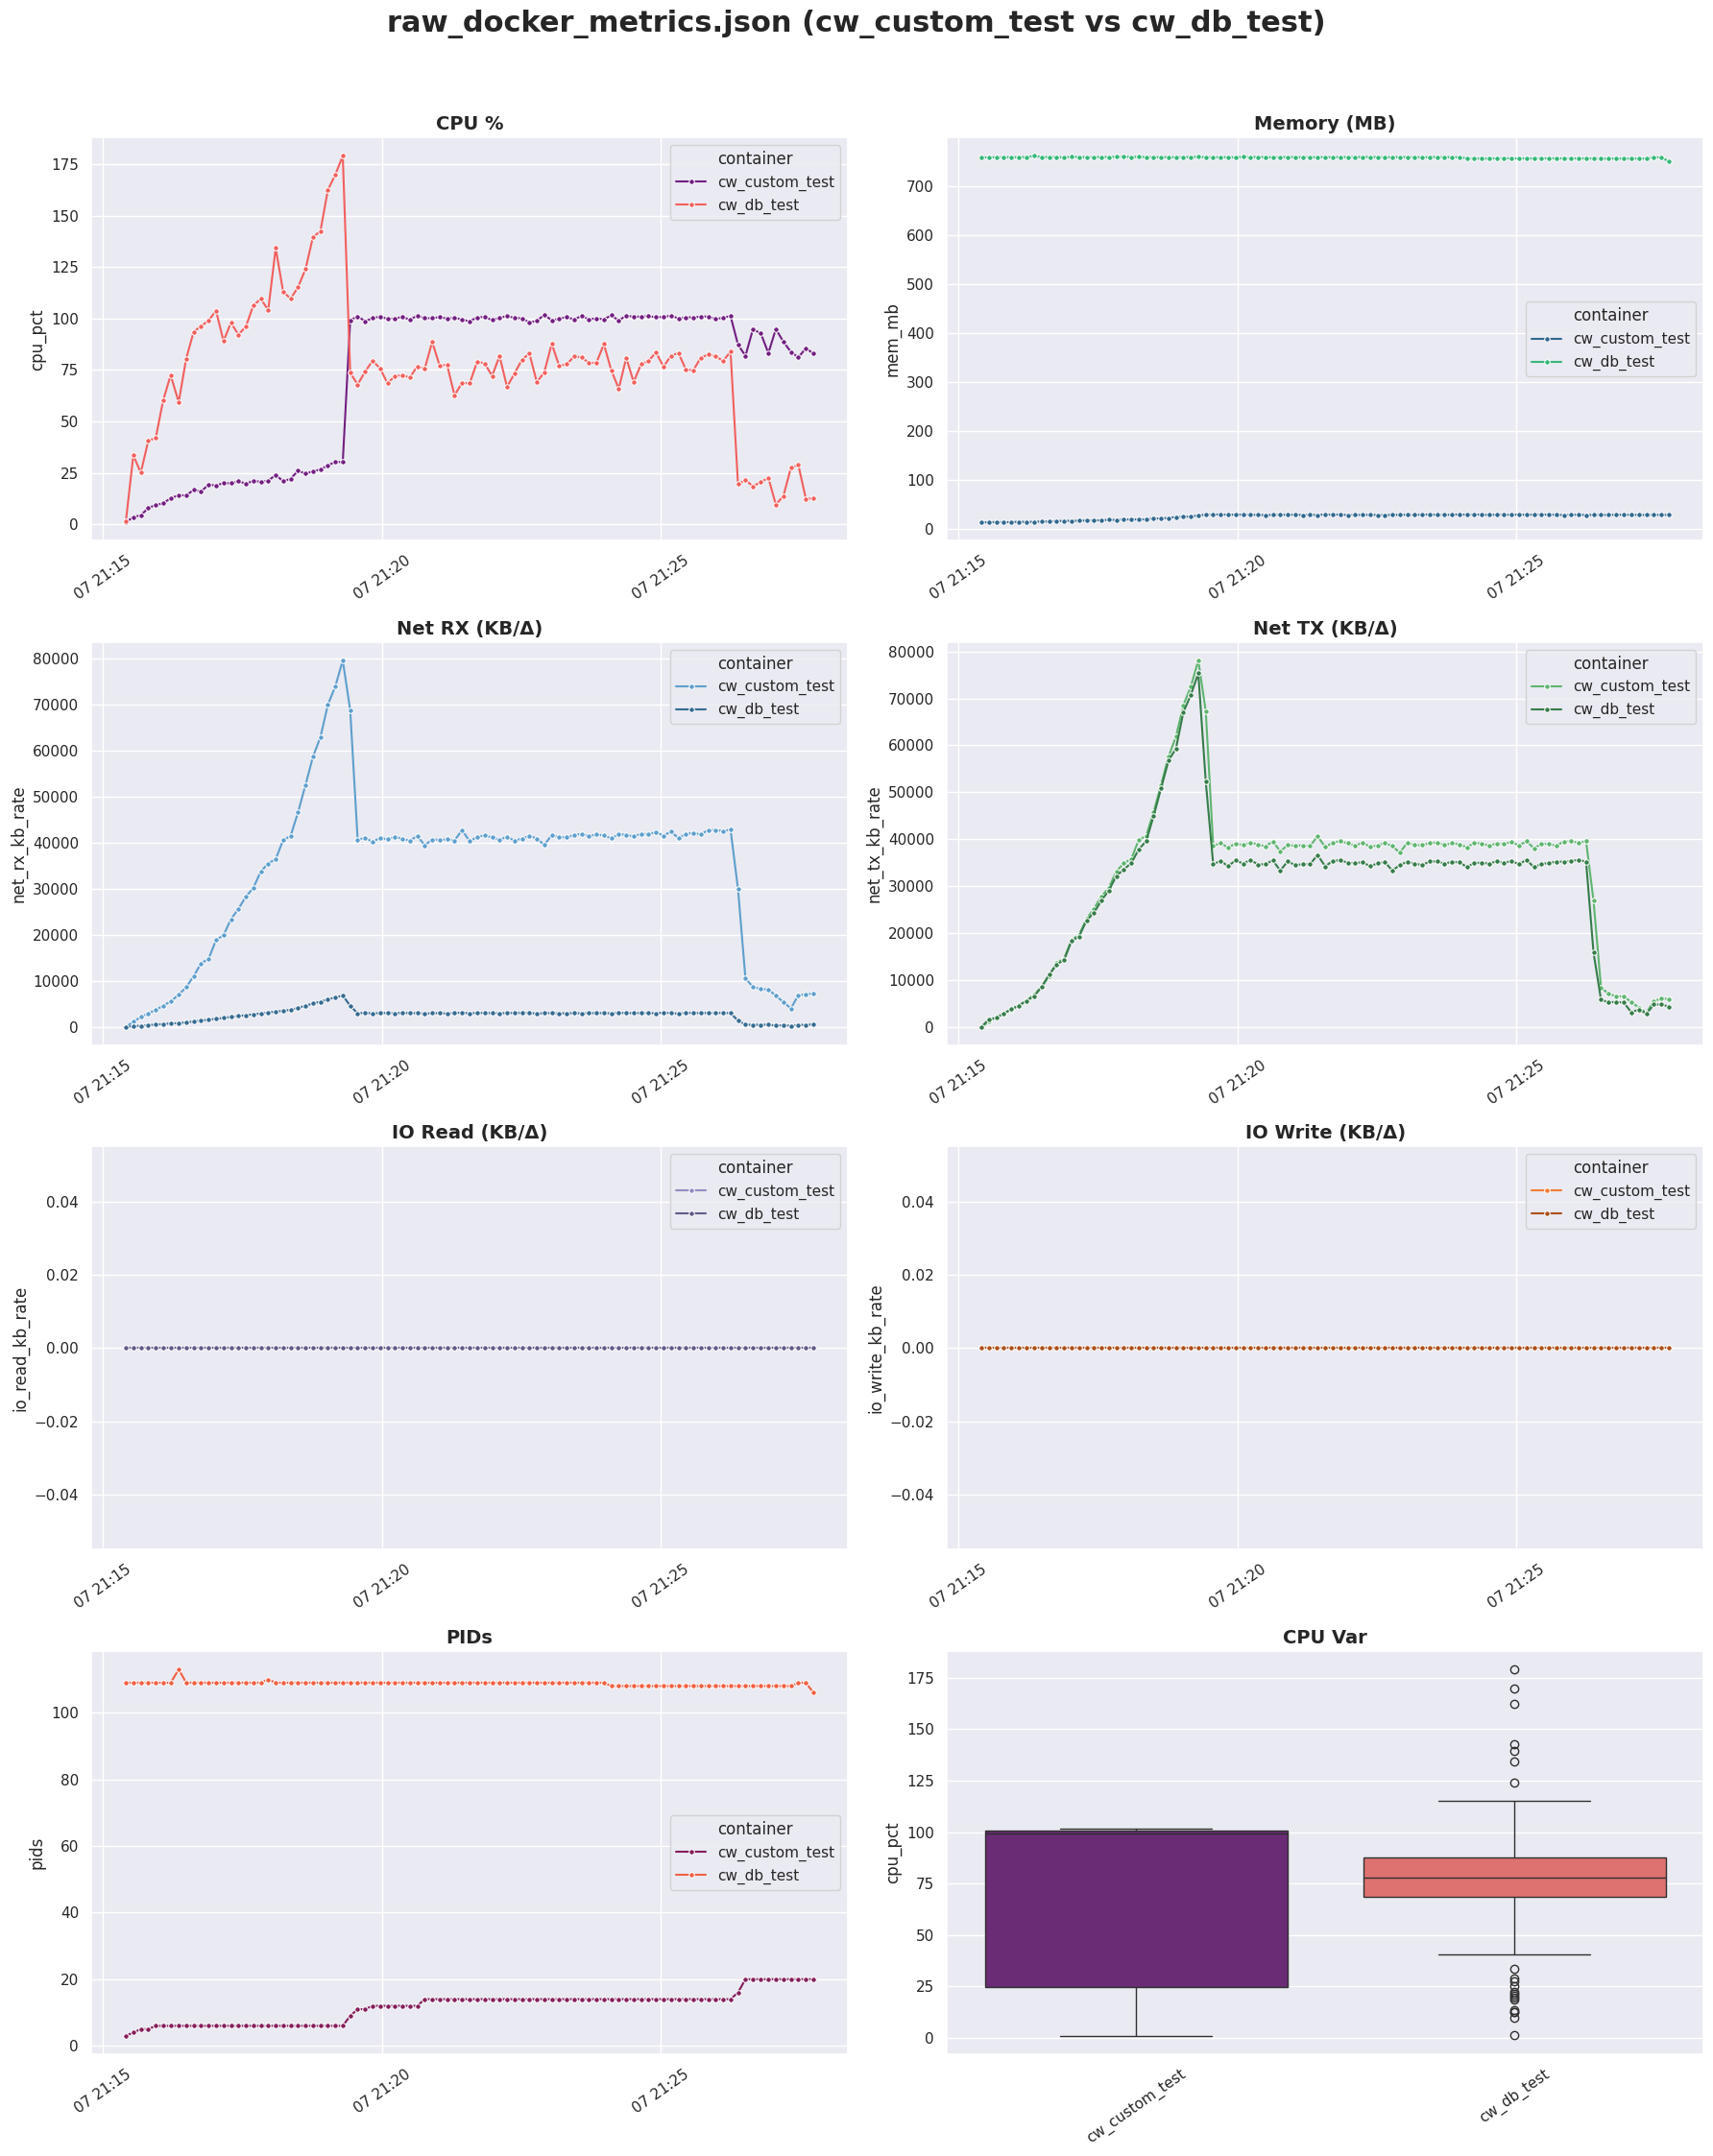

## Test Results

---

 K6 LOAD TEST ANALYSIS: test_details.json
Throughput:      2505.78 req/s
Total Requests:  1,861,795
Max Concurrency: 50000 VUs
Failure Rate:    6.38%
----------------------------------------
Latency (Duration):
  Avg: 1499.30ms
  Med: 0.21ms
  p(90): 20.18ms
  p(95): 1747.80ms
  Max: 61717.17ms

Diagram exported as: test_results/k6_break_test/1/custom/test_details_analysis.png


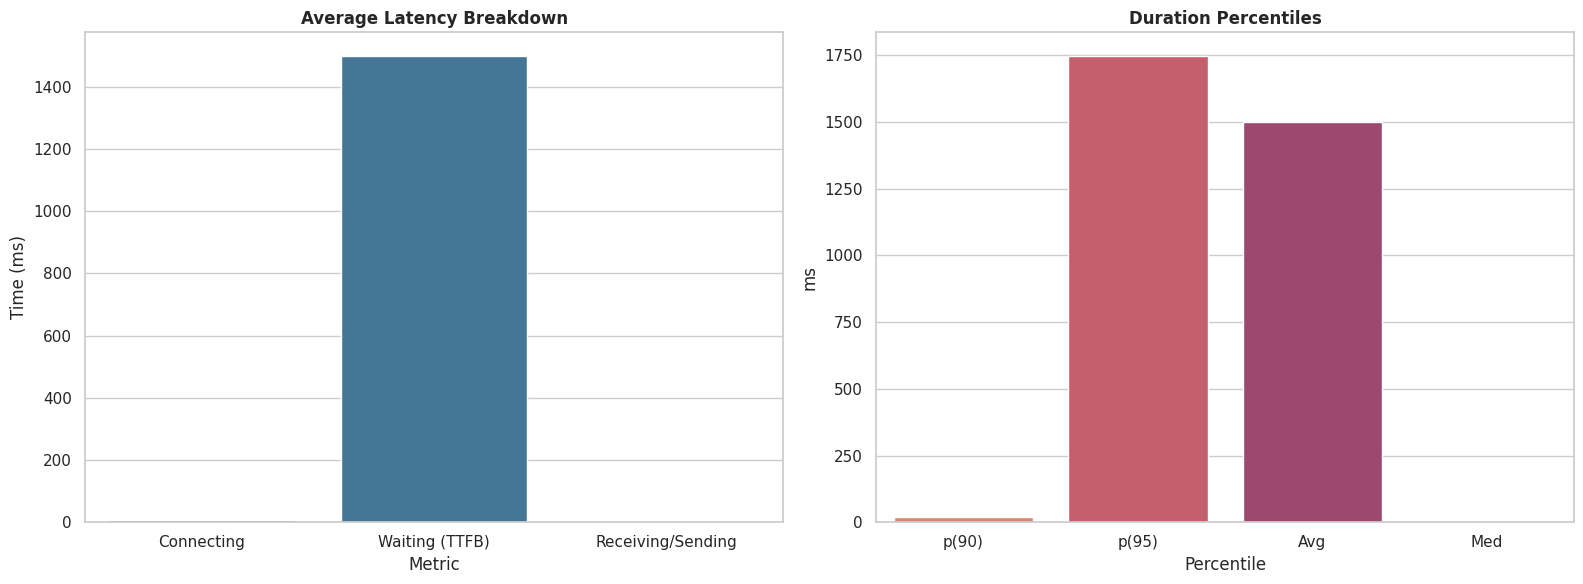

# k6_break_test / fastapi

---

## System Usage

---

--- raw_docker_metrics.json ---
                    cpu_pct          mem_mb        pids
                       mean     max    mean    max  max
container                                              
cw_db_test           241.41  407.07  667.89  716.0  102
cw_fastapi_baseline  420.99  617.10  471.63  641.2   32
Diagram exported as: test_results/k6_break_test/1/fastapi/raw_docker_metrics_analysis.png


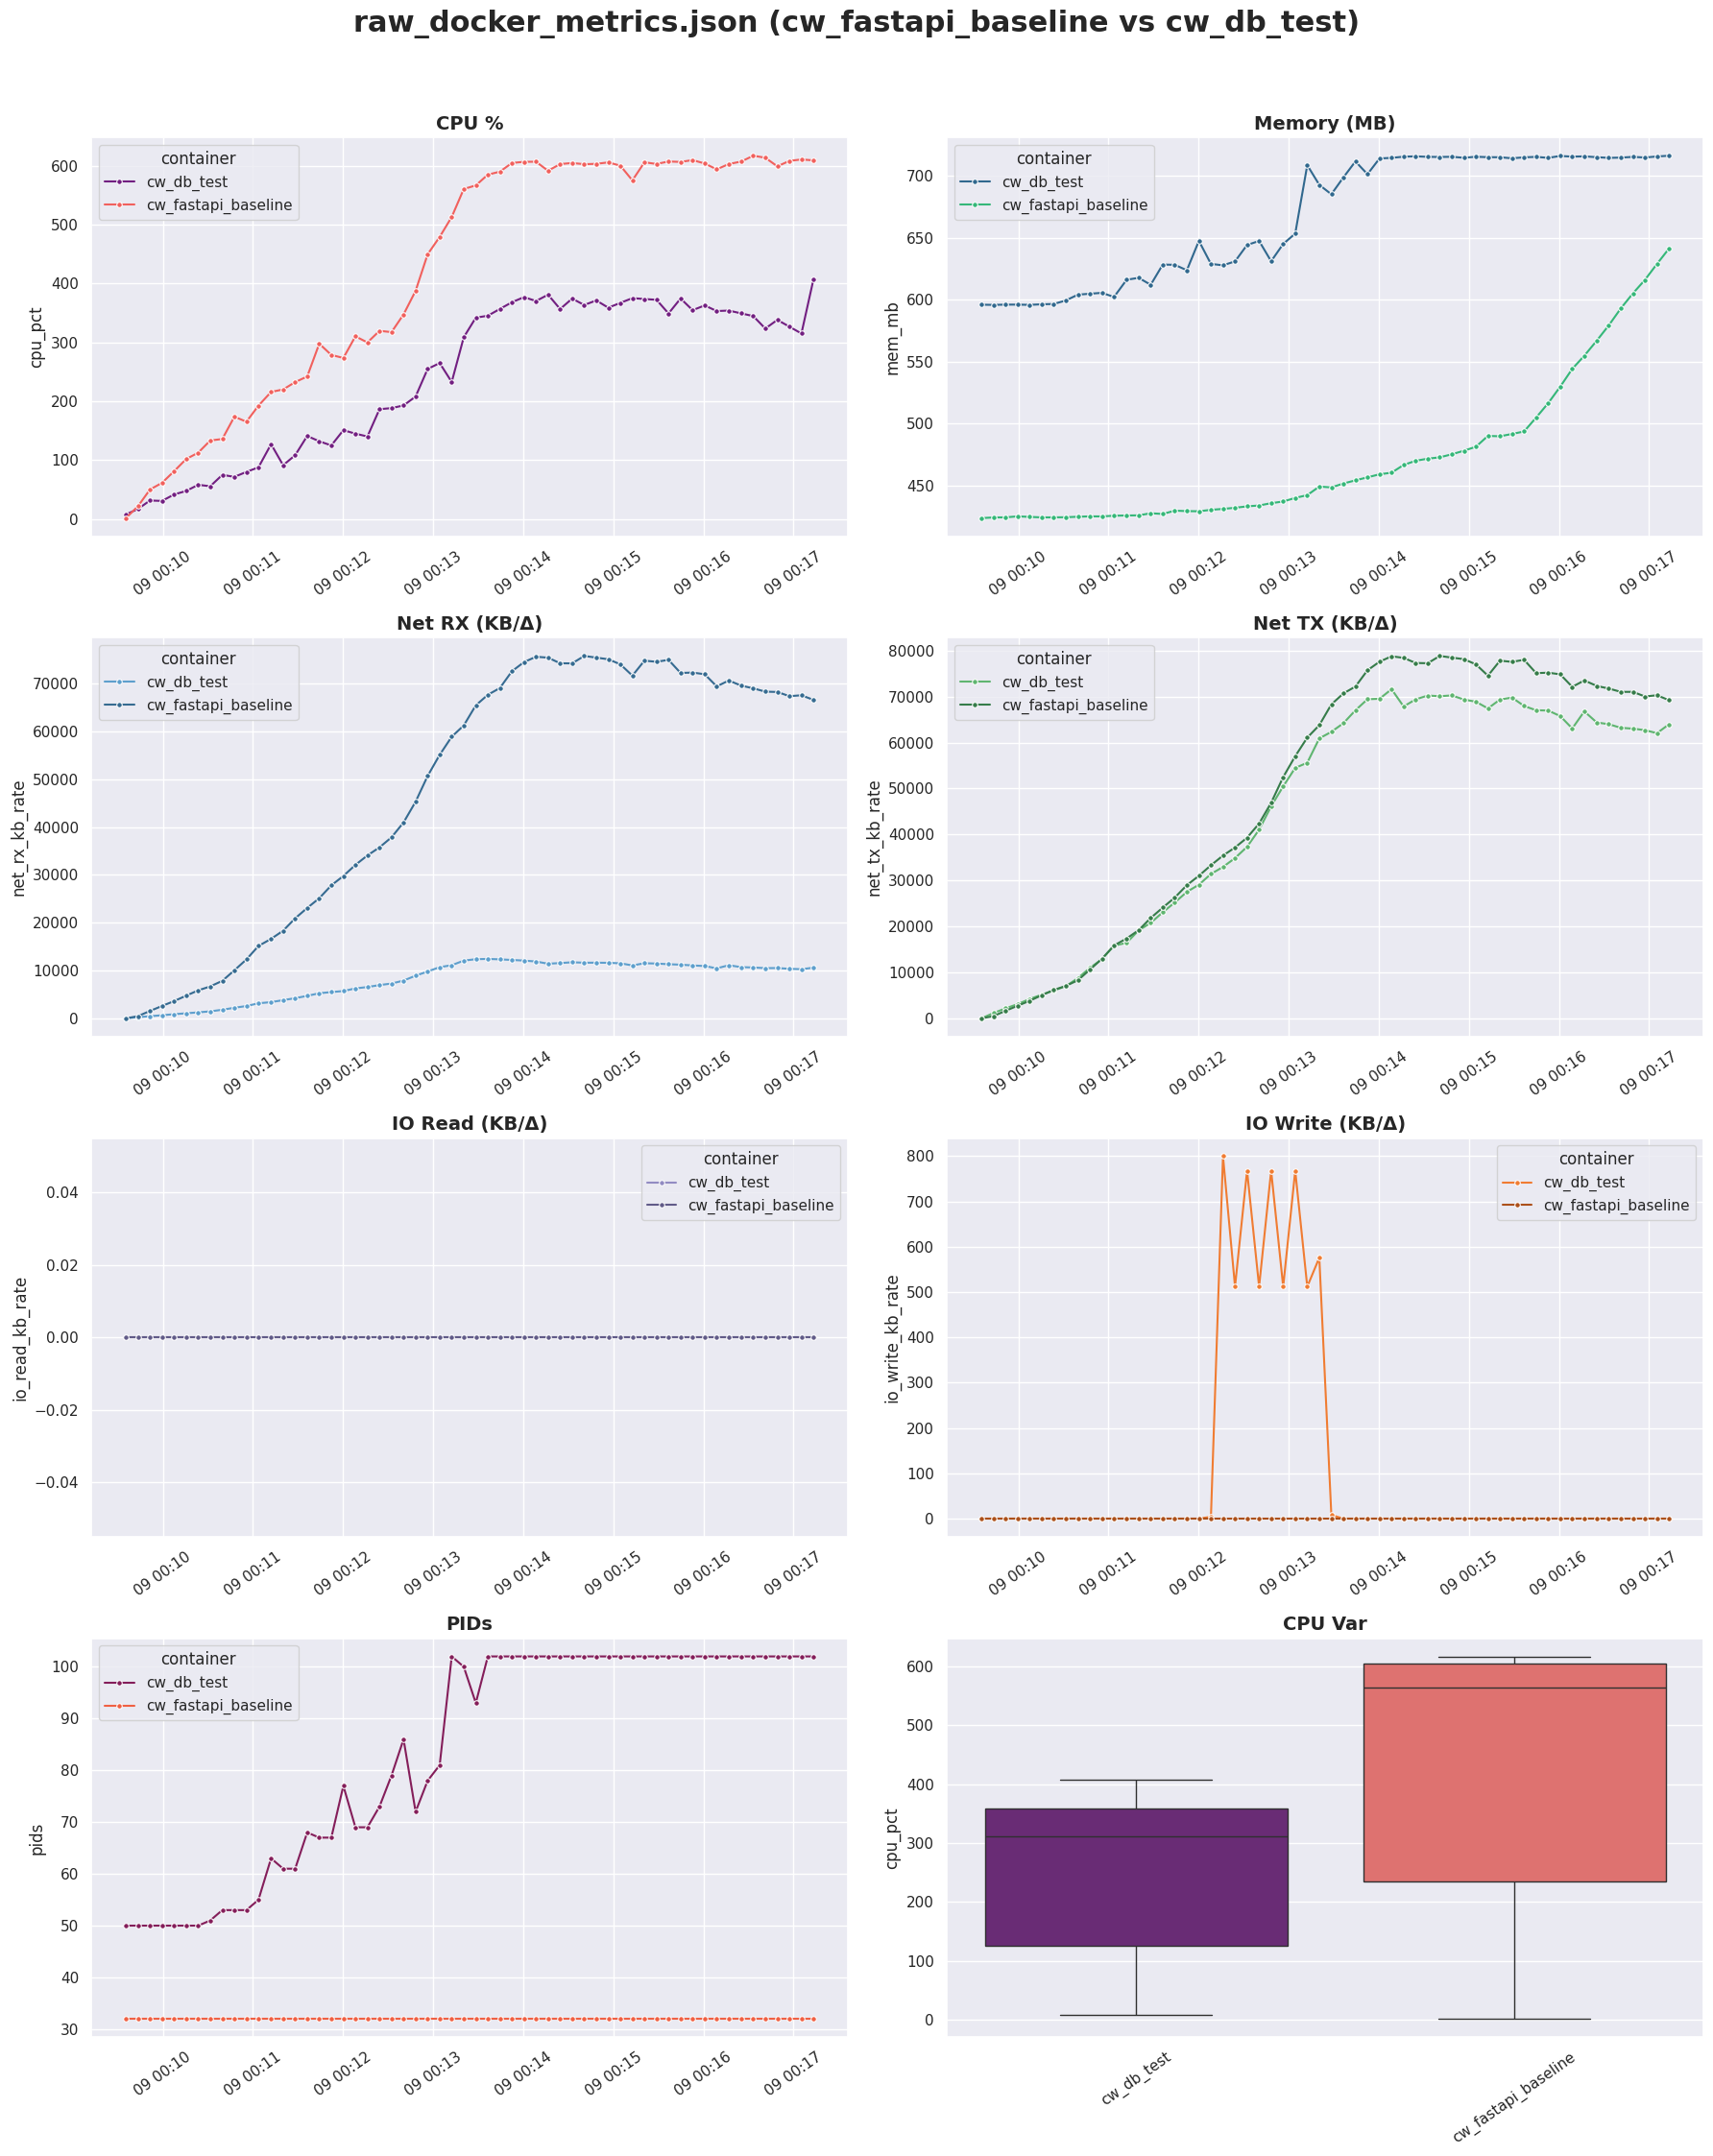

## Test Results

---

 K6 LOAD TEST ANALYSIS: test_details.json
Throughput:      1937.26 req/s
Total Requests:  895,829
Max Concurrency: 50000 VUs
Failure Rate:    0.00%
----------------------------------------
Latency (Duration):
  Avg: 410.67ms
  Med: 184.96ms
  p(90): 1276.57ms
  p(95): 1512.98ms
  Max: 6547.88ms

Diagram exported as: test_results/k6_break_test/1/fastapi/test_details_analysis.png


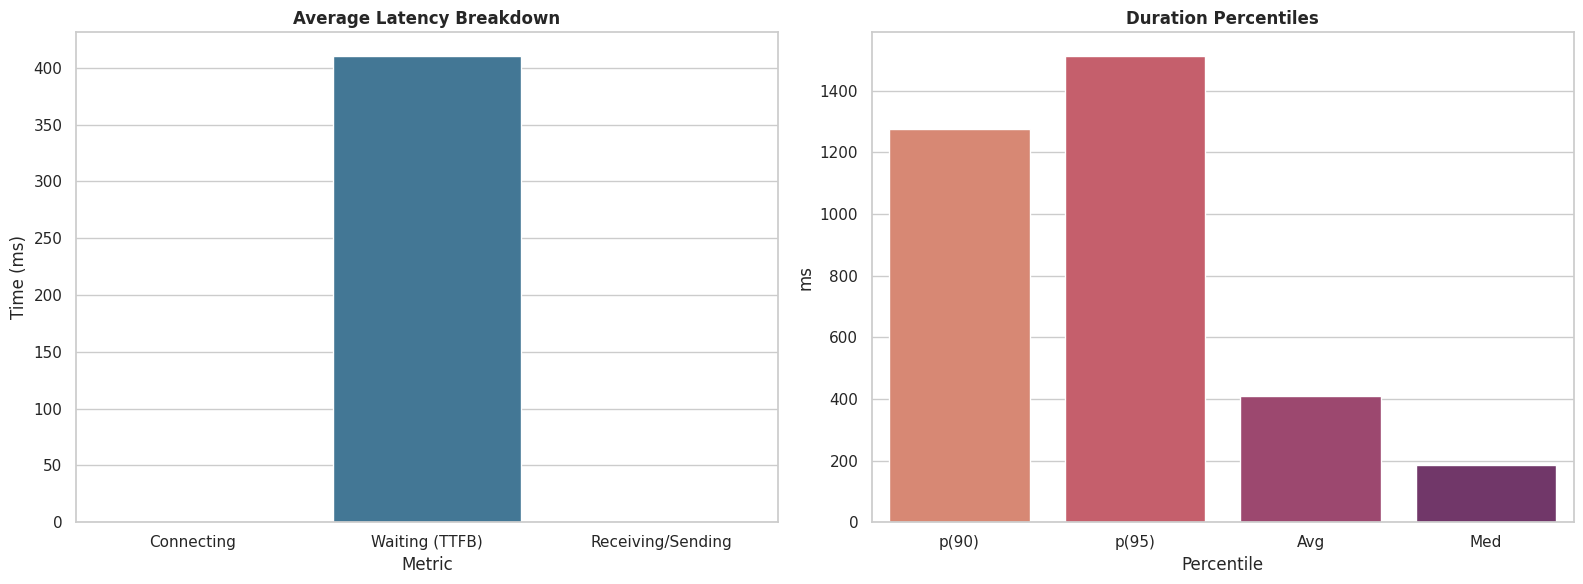

# hey_200000_100 / axum

---

## System Usage

---

--- raw_docker_metrics.json ---
             cpu_pct       mem_mb         pids
                mean  max    mean     max  max
container                                     
cw_axum_test     0.0  0.0   26.16   26.16    2
cw_db_test       0.0  0.0  754.02  754.02  109
Diagram exported as: test_results/hey_200000_100/1/axum/raw_docker_metrics_analysis.png


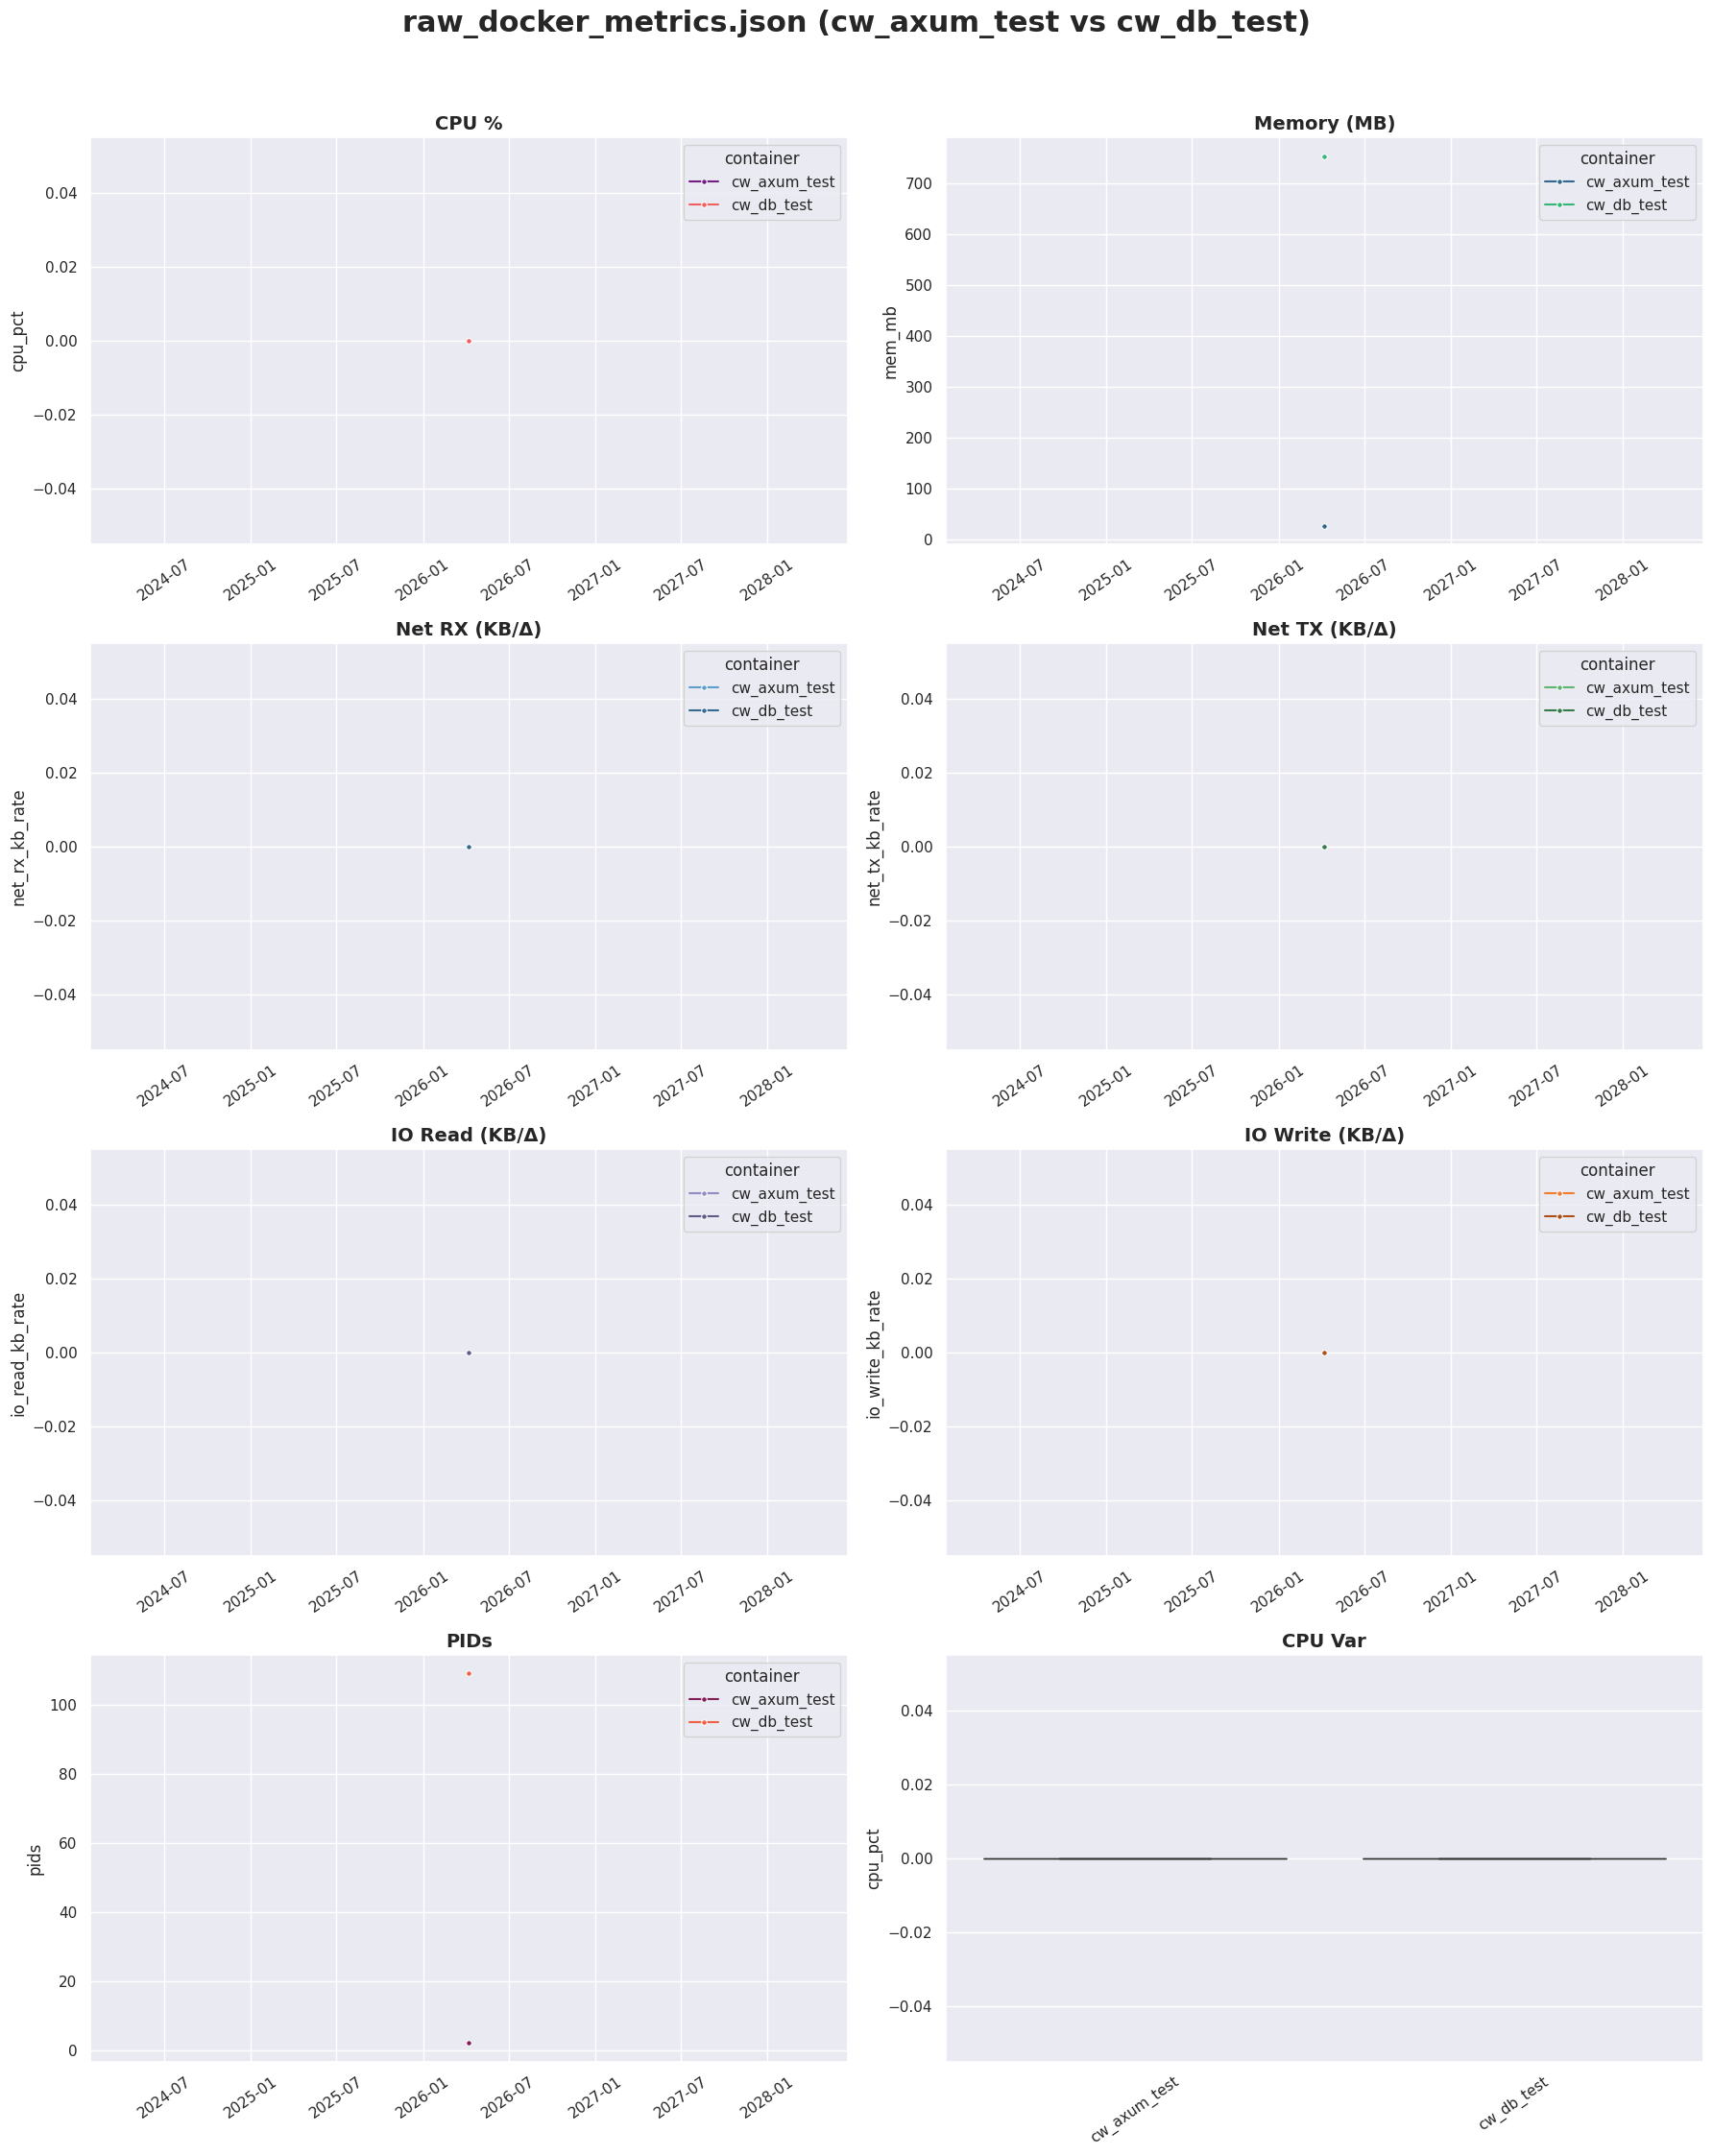

## Test Results

---

Diagram exported as: test_results/hey_200000_100/1/axum/test_details_analysis.png


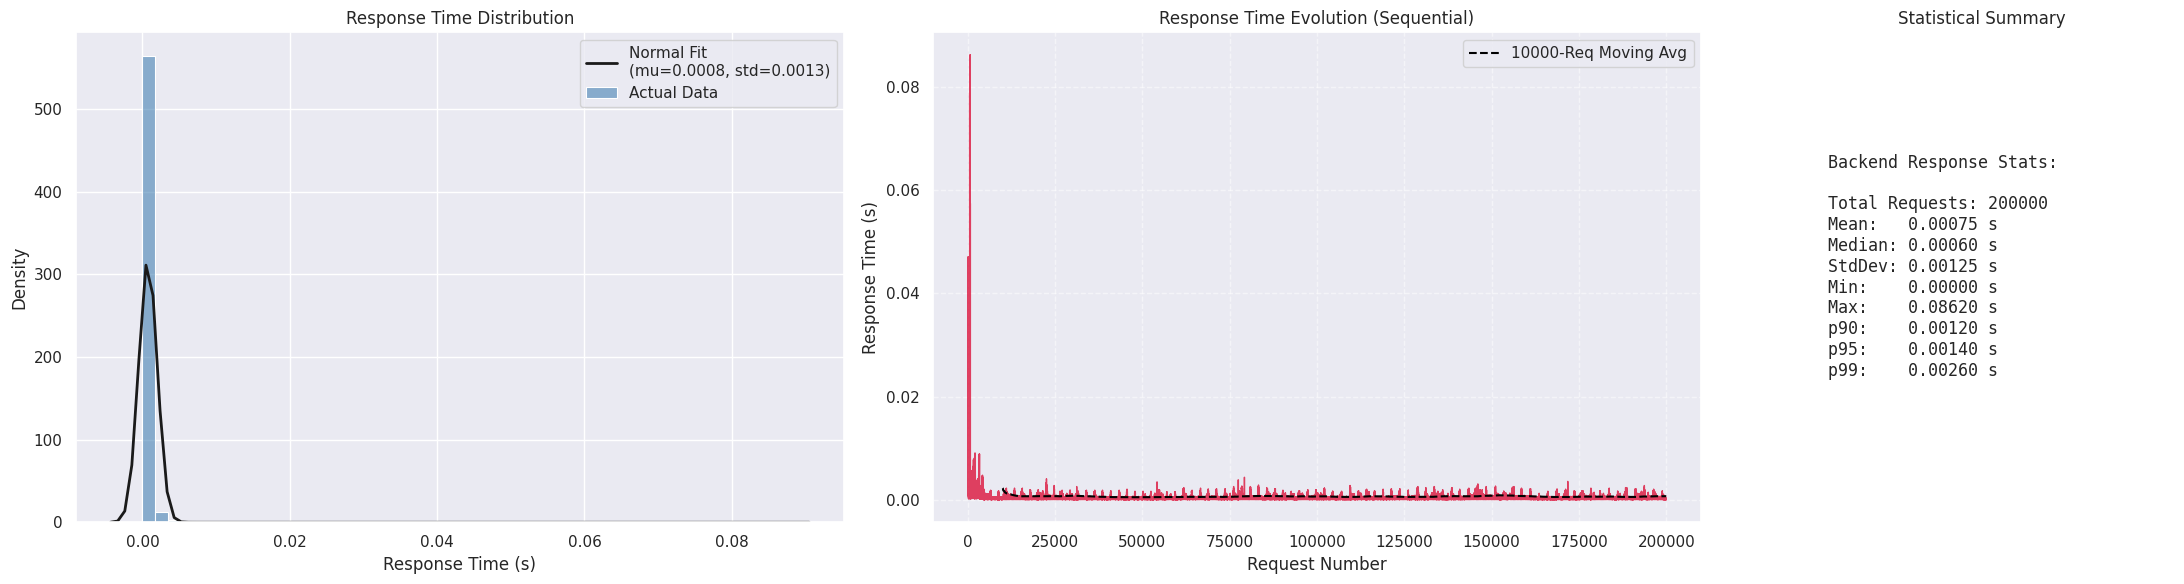

---

# hey_200000_100 / custom

---

## System Usage

---

--- raw_docker_metrics.json ---
               cpu_pct        mem_mb         pids
                  mean   max    mean     max  max
container                                        
cw_custom_test    0.00  0.00   13.79   13.79    2
cw_db_test        1.04  1.04  754.06  754.06  109
Diagram exported as: test_results/hey_200000_100/1/custom/raw_docker_metrics_analysis.png


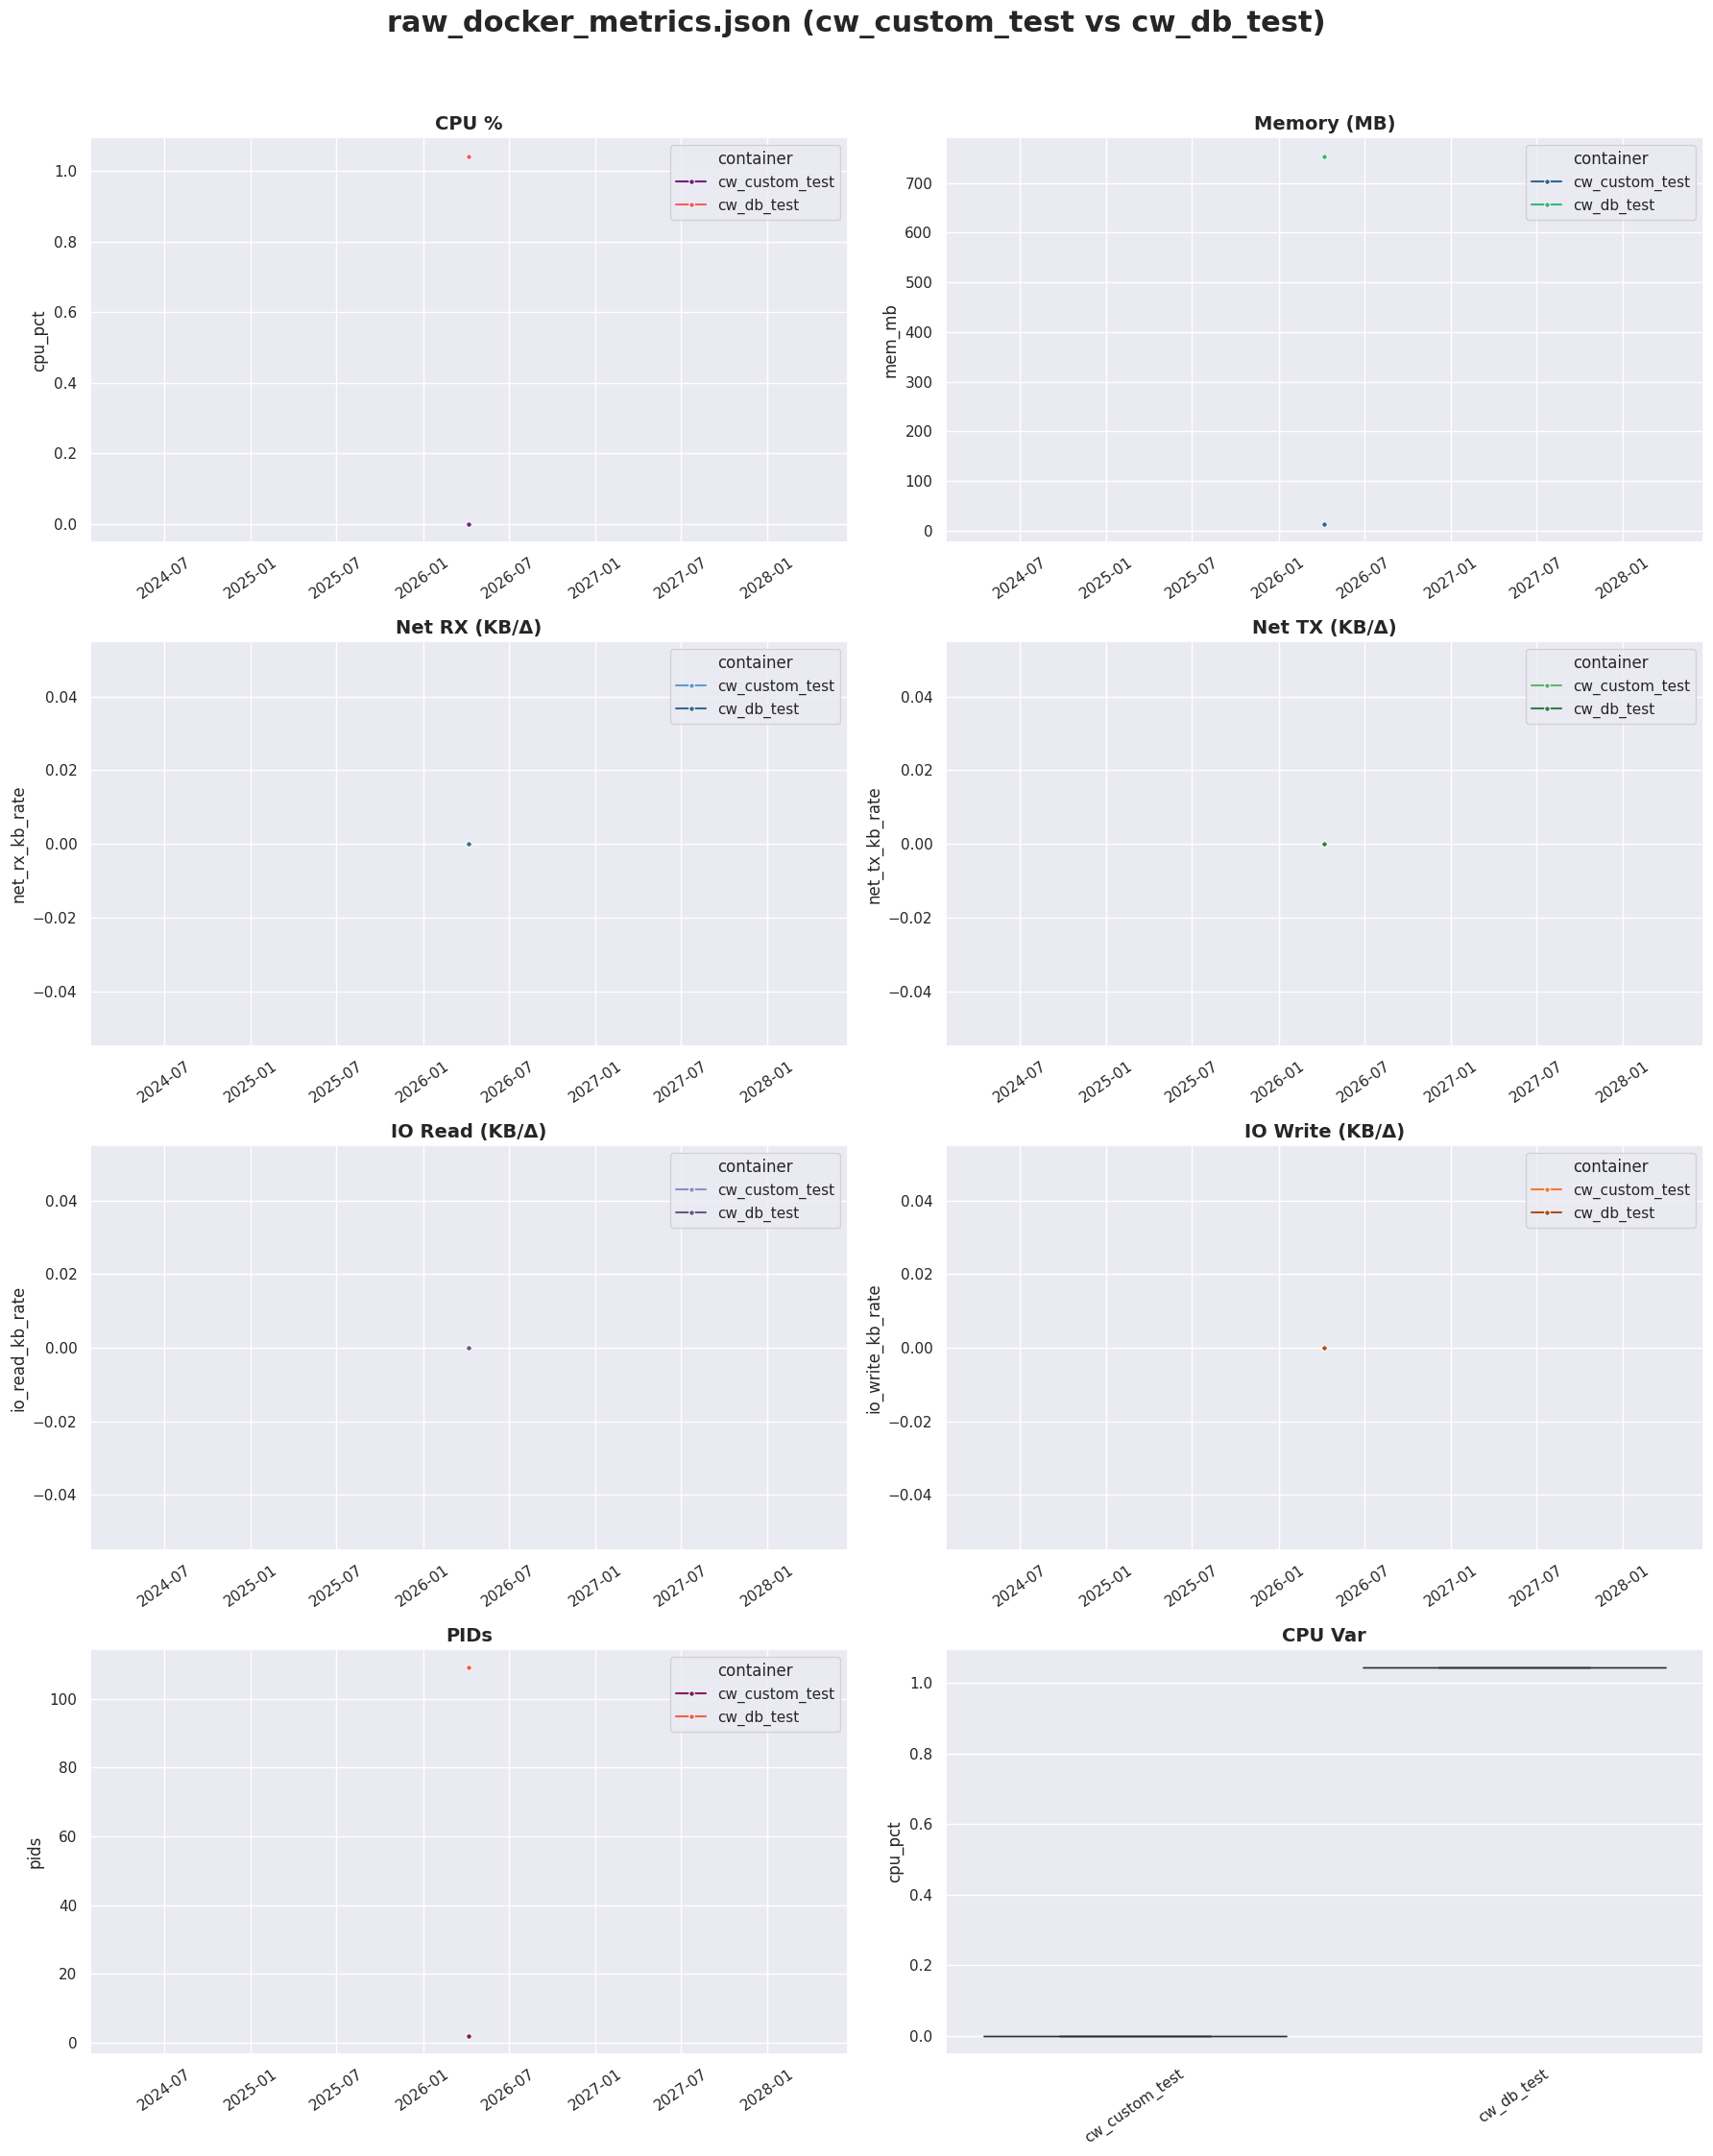

## Test Results

---

Diagram exported as: test_results/hey_200000_100/1/custom/test_details_analysis.png


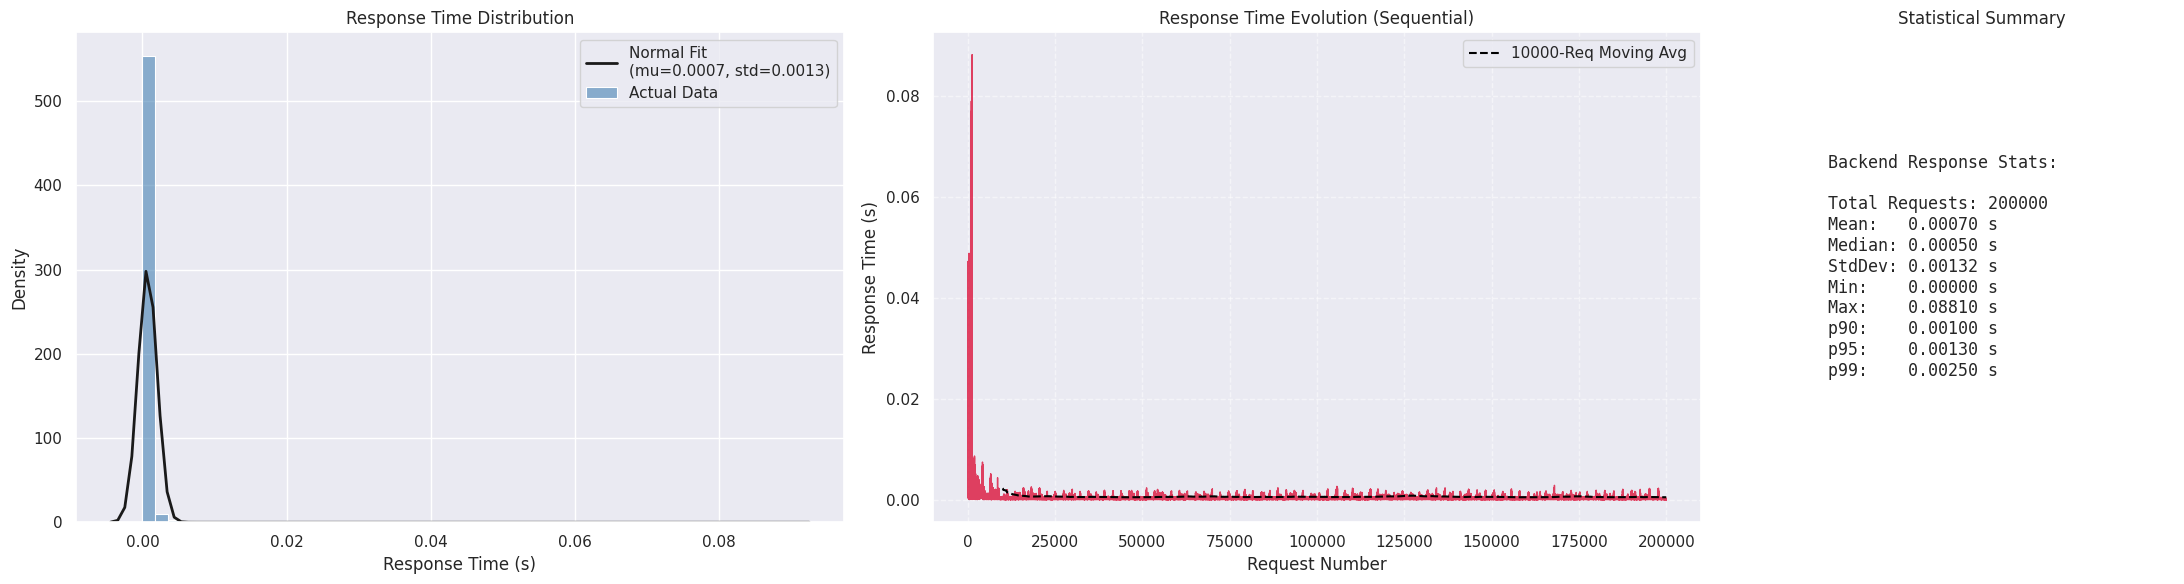

---

# hey_200000_100 / fastapi

---

## System Usage

---

--- raw_docker_metrics.json ---
                    cpu_pct          mem_mb         pids
                       mean     max    mean     max  max
container                                               
cw_db_test             4.79    4.79  596.00  596.00   50
cw_fastapi_baseline  562.24  562.24  425.13  425.13   32
Diagram exported as: test_results/hey_200000_100/1/fastapi/raw_docker_metrics_analysis.png


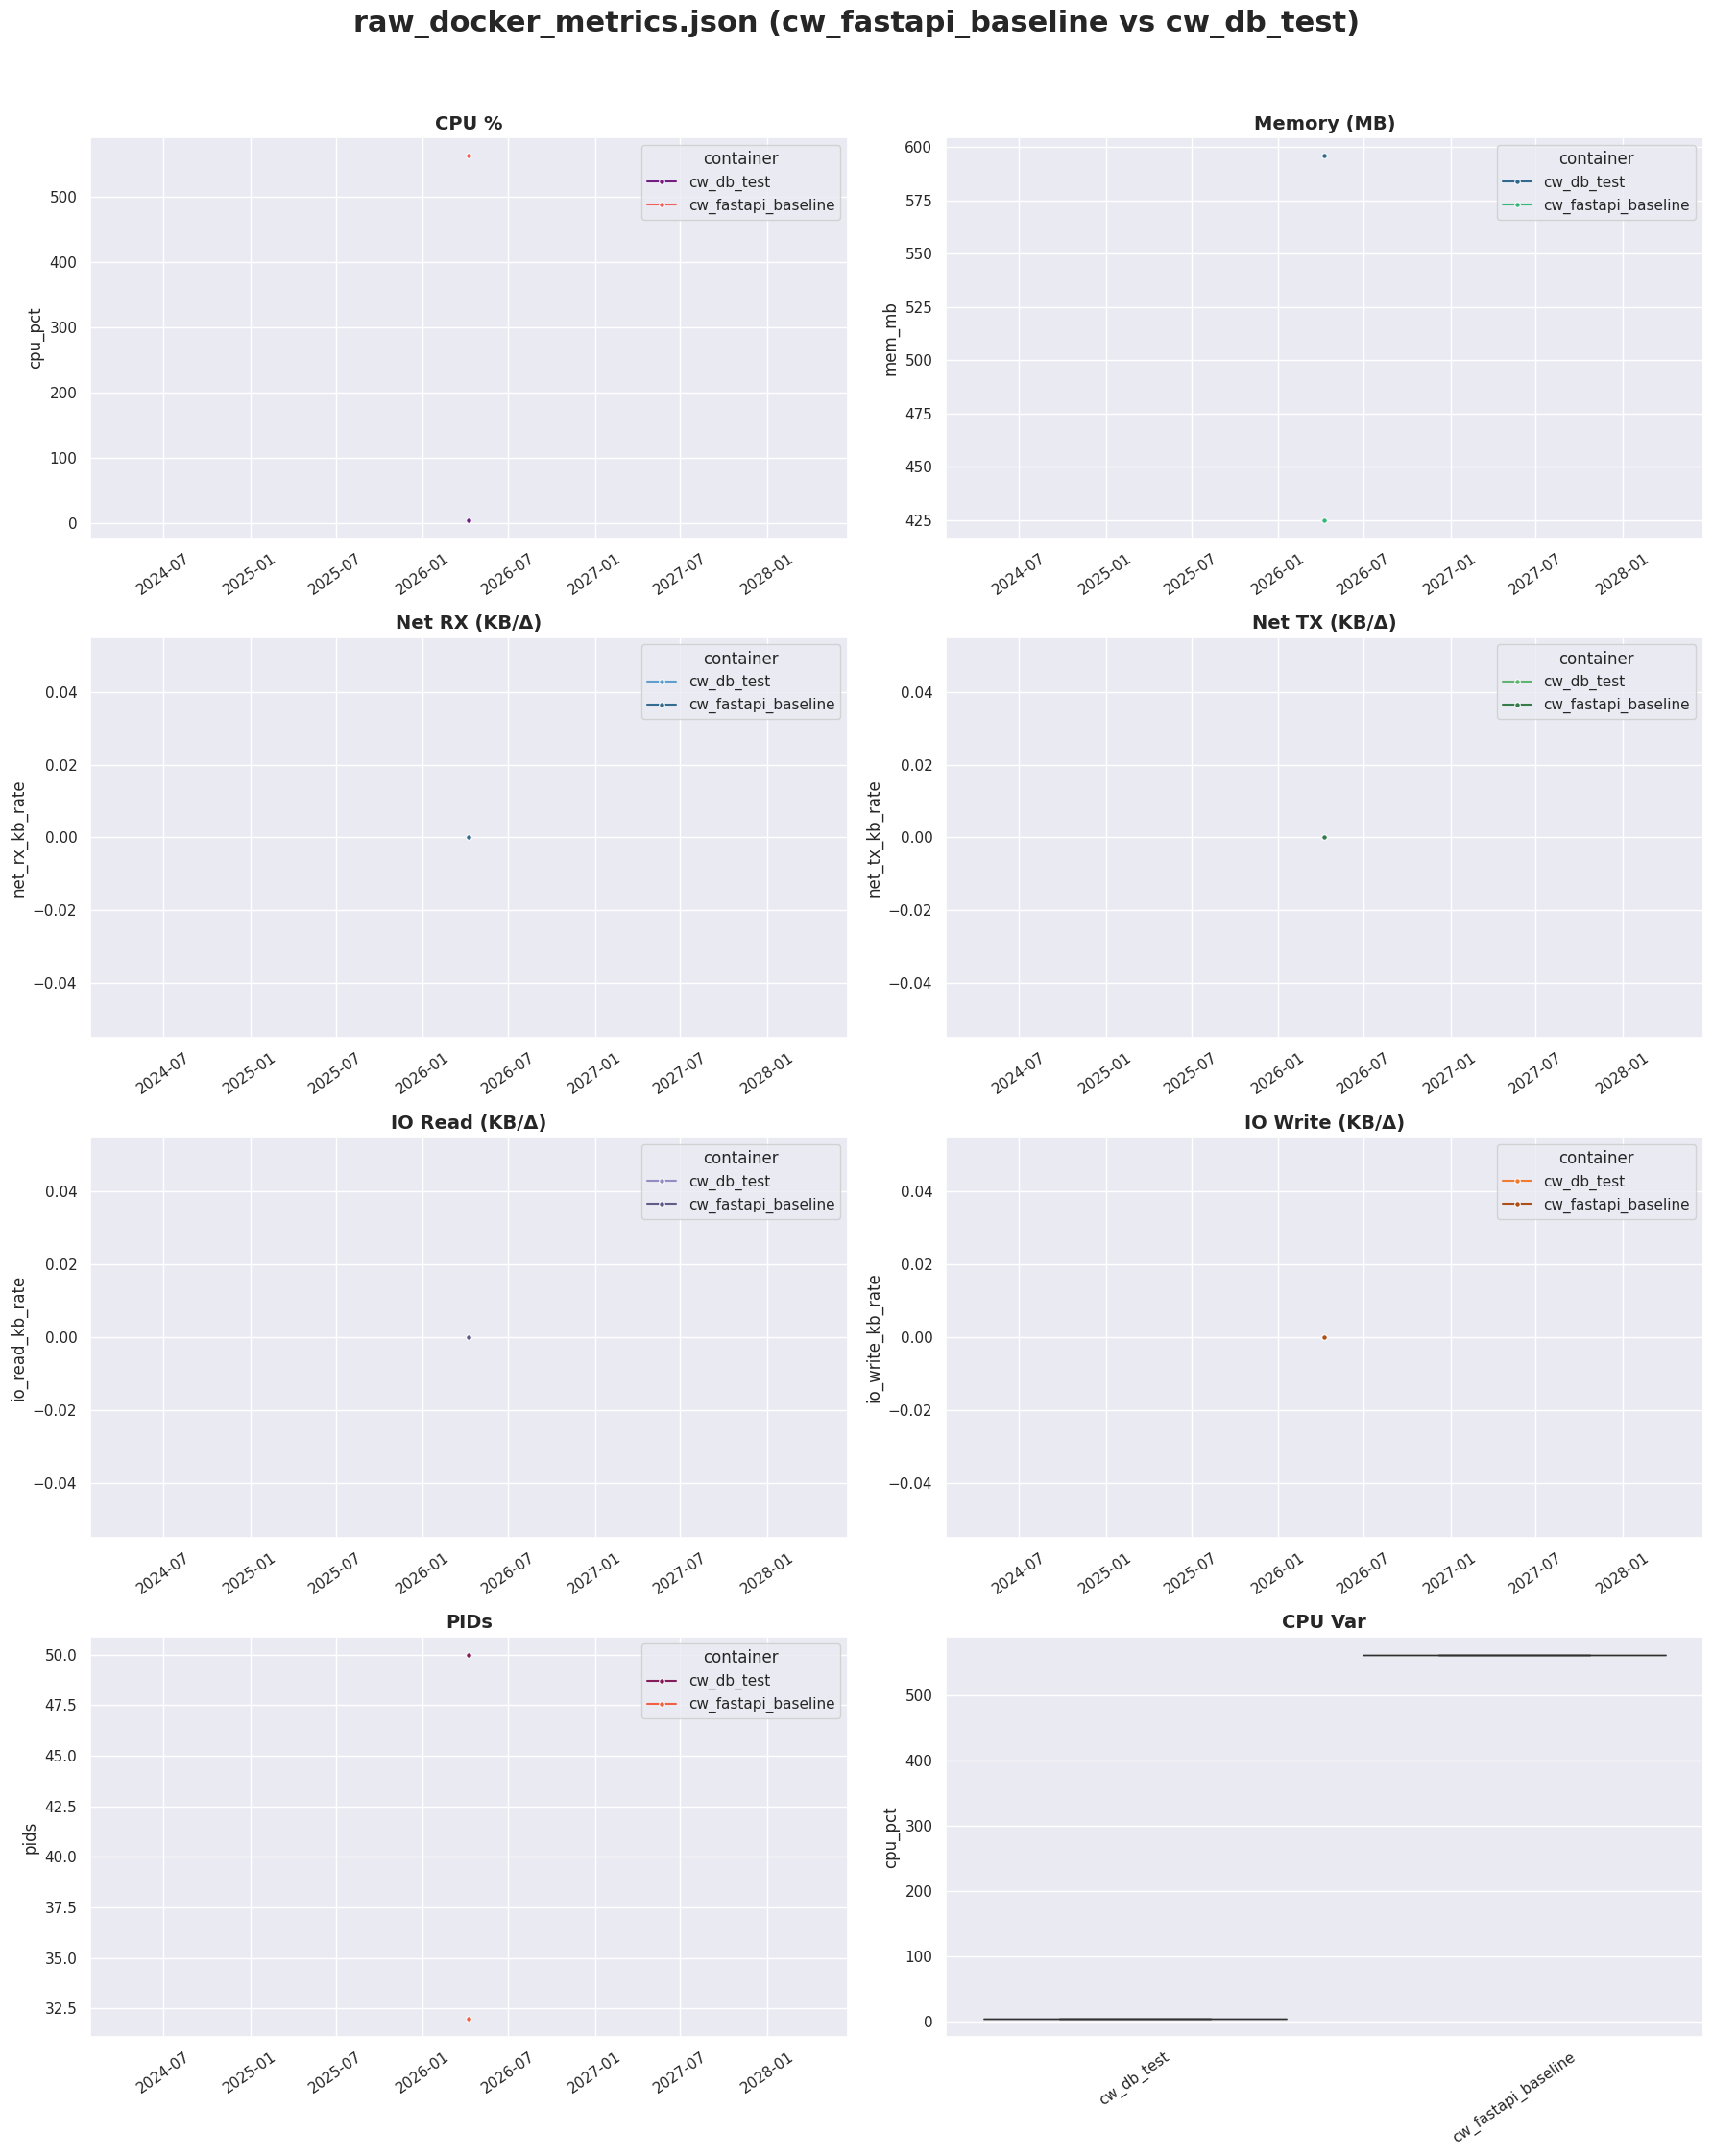

## Test Results

---

Diagram exported as: test_results/hey_200000_100/1/fastapi/test_details_analysis.png


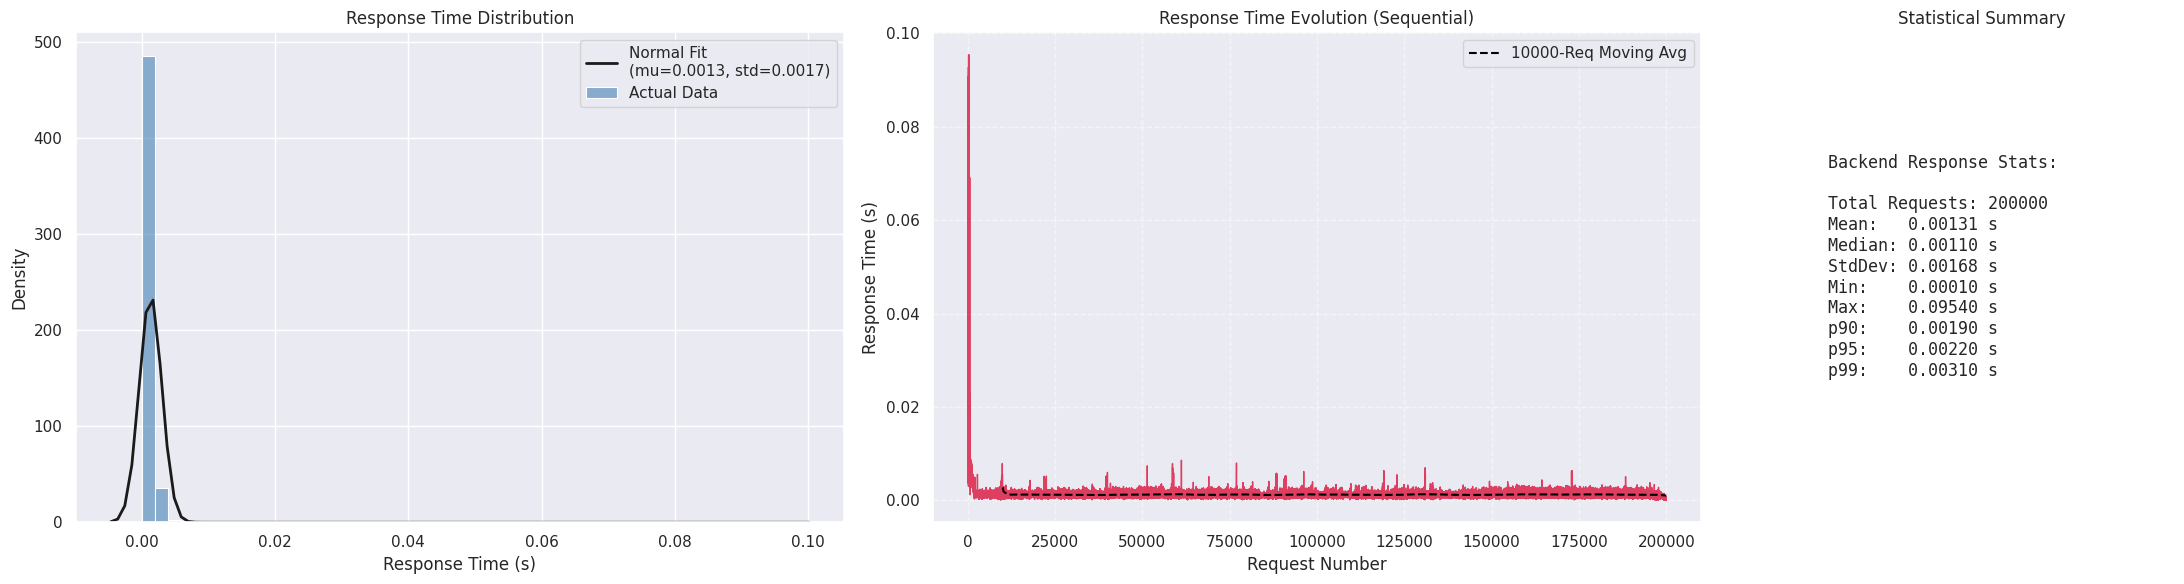

---

# hey_2m_1k / axum

---

## System Usage

---

--- raw_docker_metrics.json ---
             cpu_pct          mem_mb         pids
                mean     max    mean     max  max
container                                        
cw_axum_test   70.43  108.06   30.73   32.77    2
cw_db_test      0.12    0.37  464.80  464.80   12
Diagram exported as: test_results/hey_2m_1k/1/axum/raw_docker_metrics_analysis.png


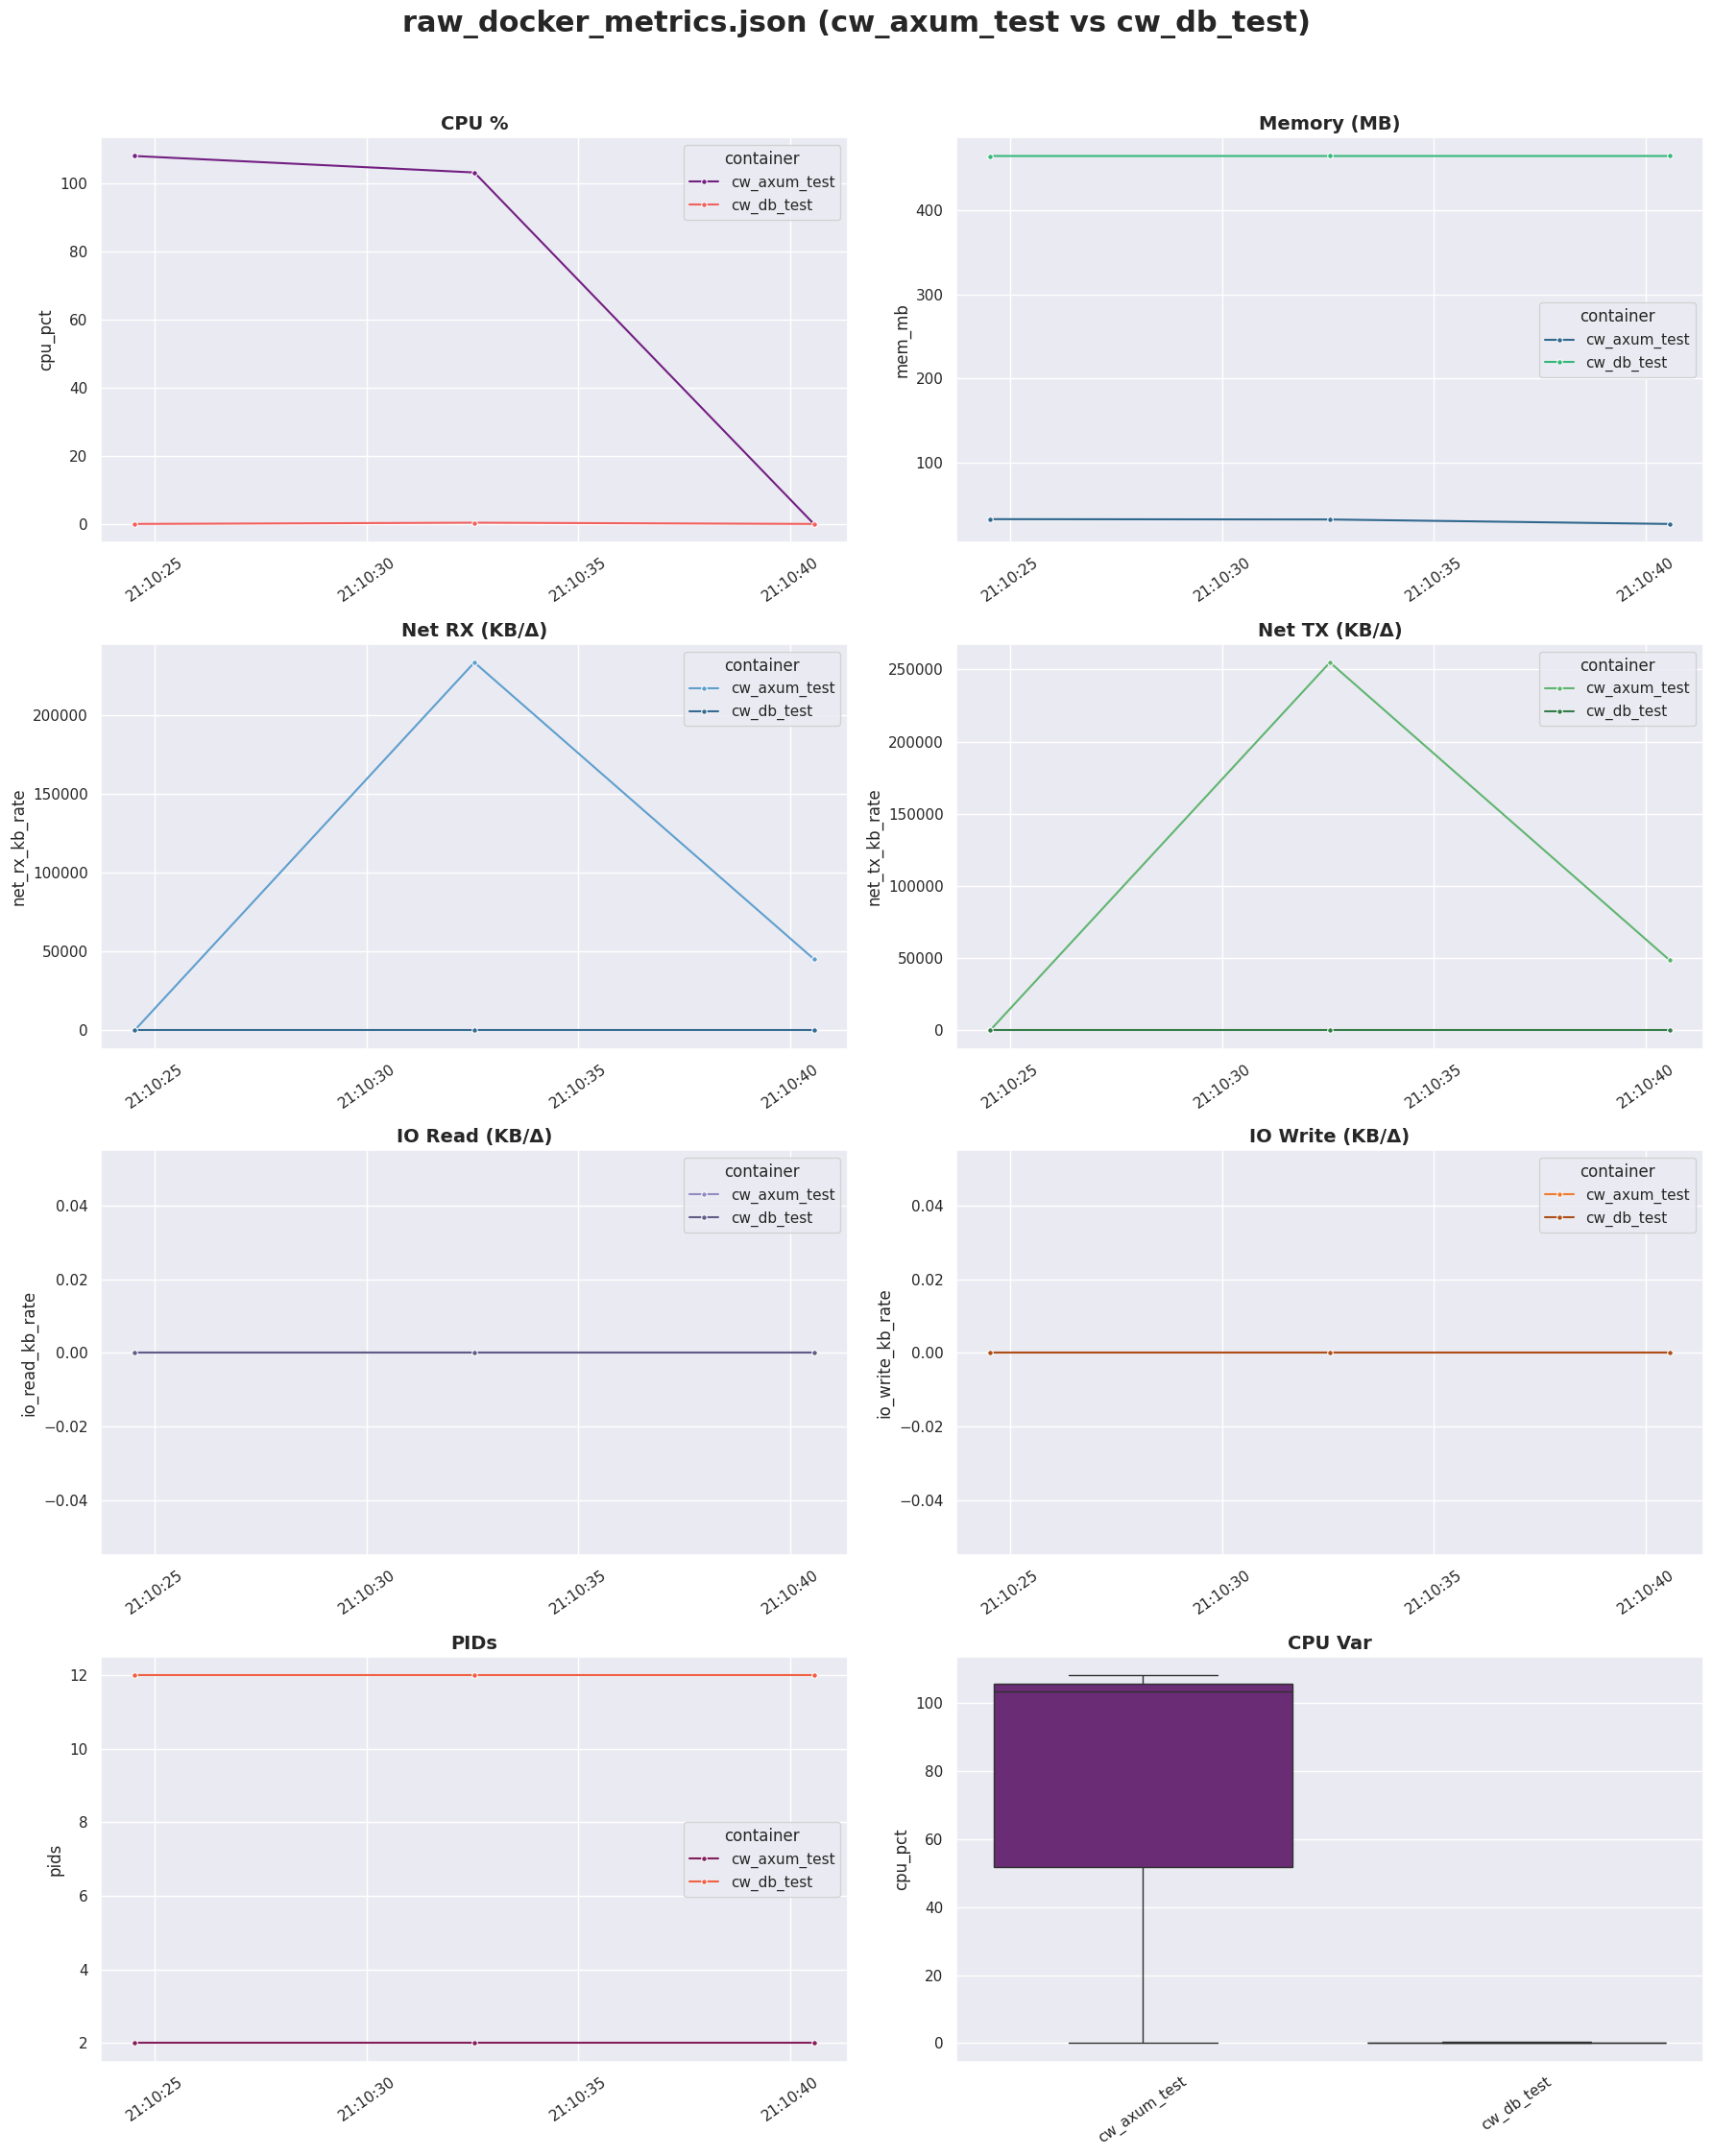

## Test Results

---

Diagram exported as: test_results/hey_2m_1k/1/axum/test_details_analysis.png


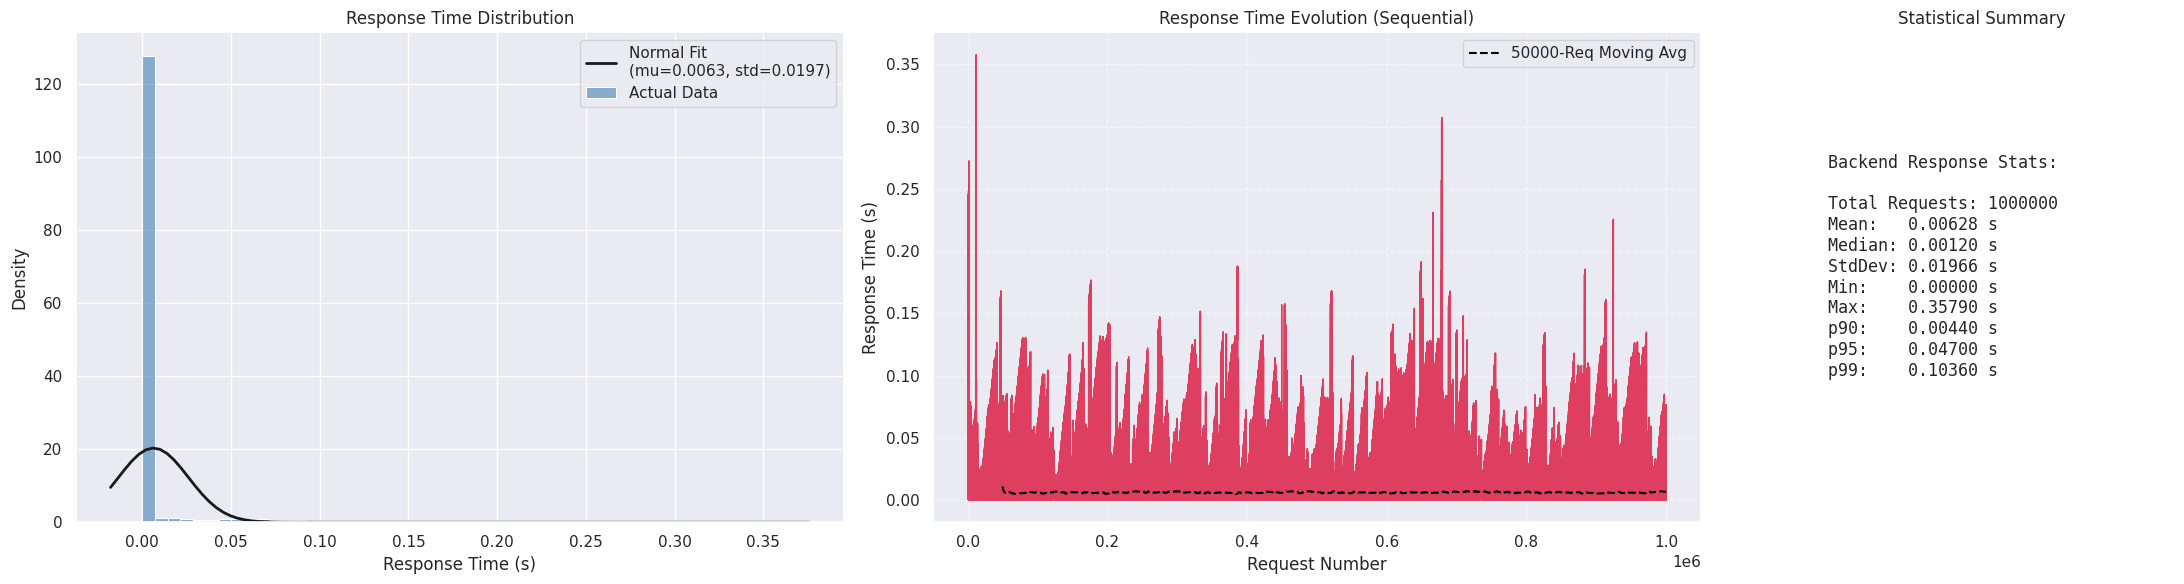

---

# hey_2m_1k / custom

---

## System Usage

---

--- raw_docker_metrics.json ---
               cpu_pct          mem_mb         pids
                  mean     max    mean     max  max
container                                          
cw_custom_test   53.28  111.39   15.97   20.52    2
cw_db_test        1.53    4.25  464.96  465.13   12
Diagram exported as: test_results/hey_2m_1k/1/custom/raw_docker_metrics_analysis.png


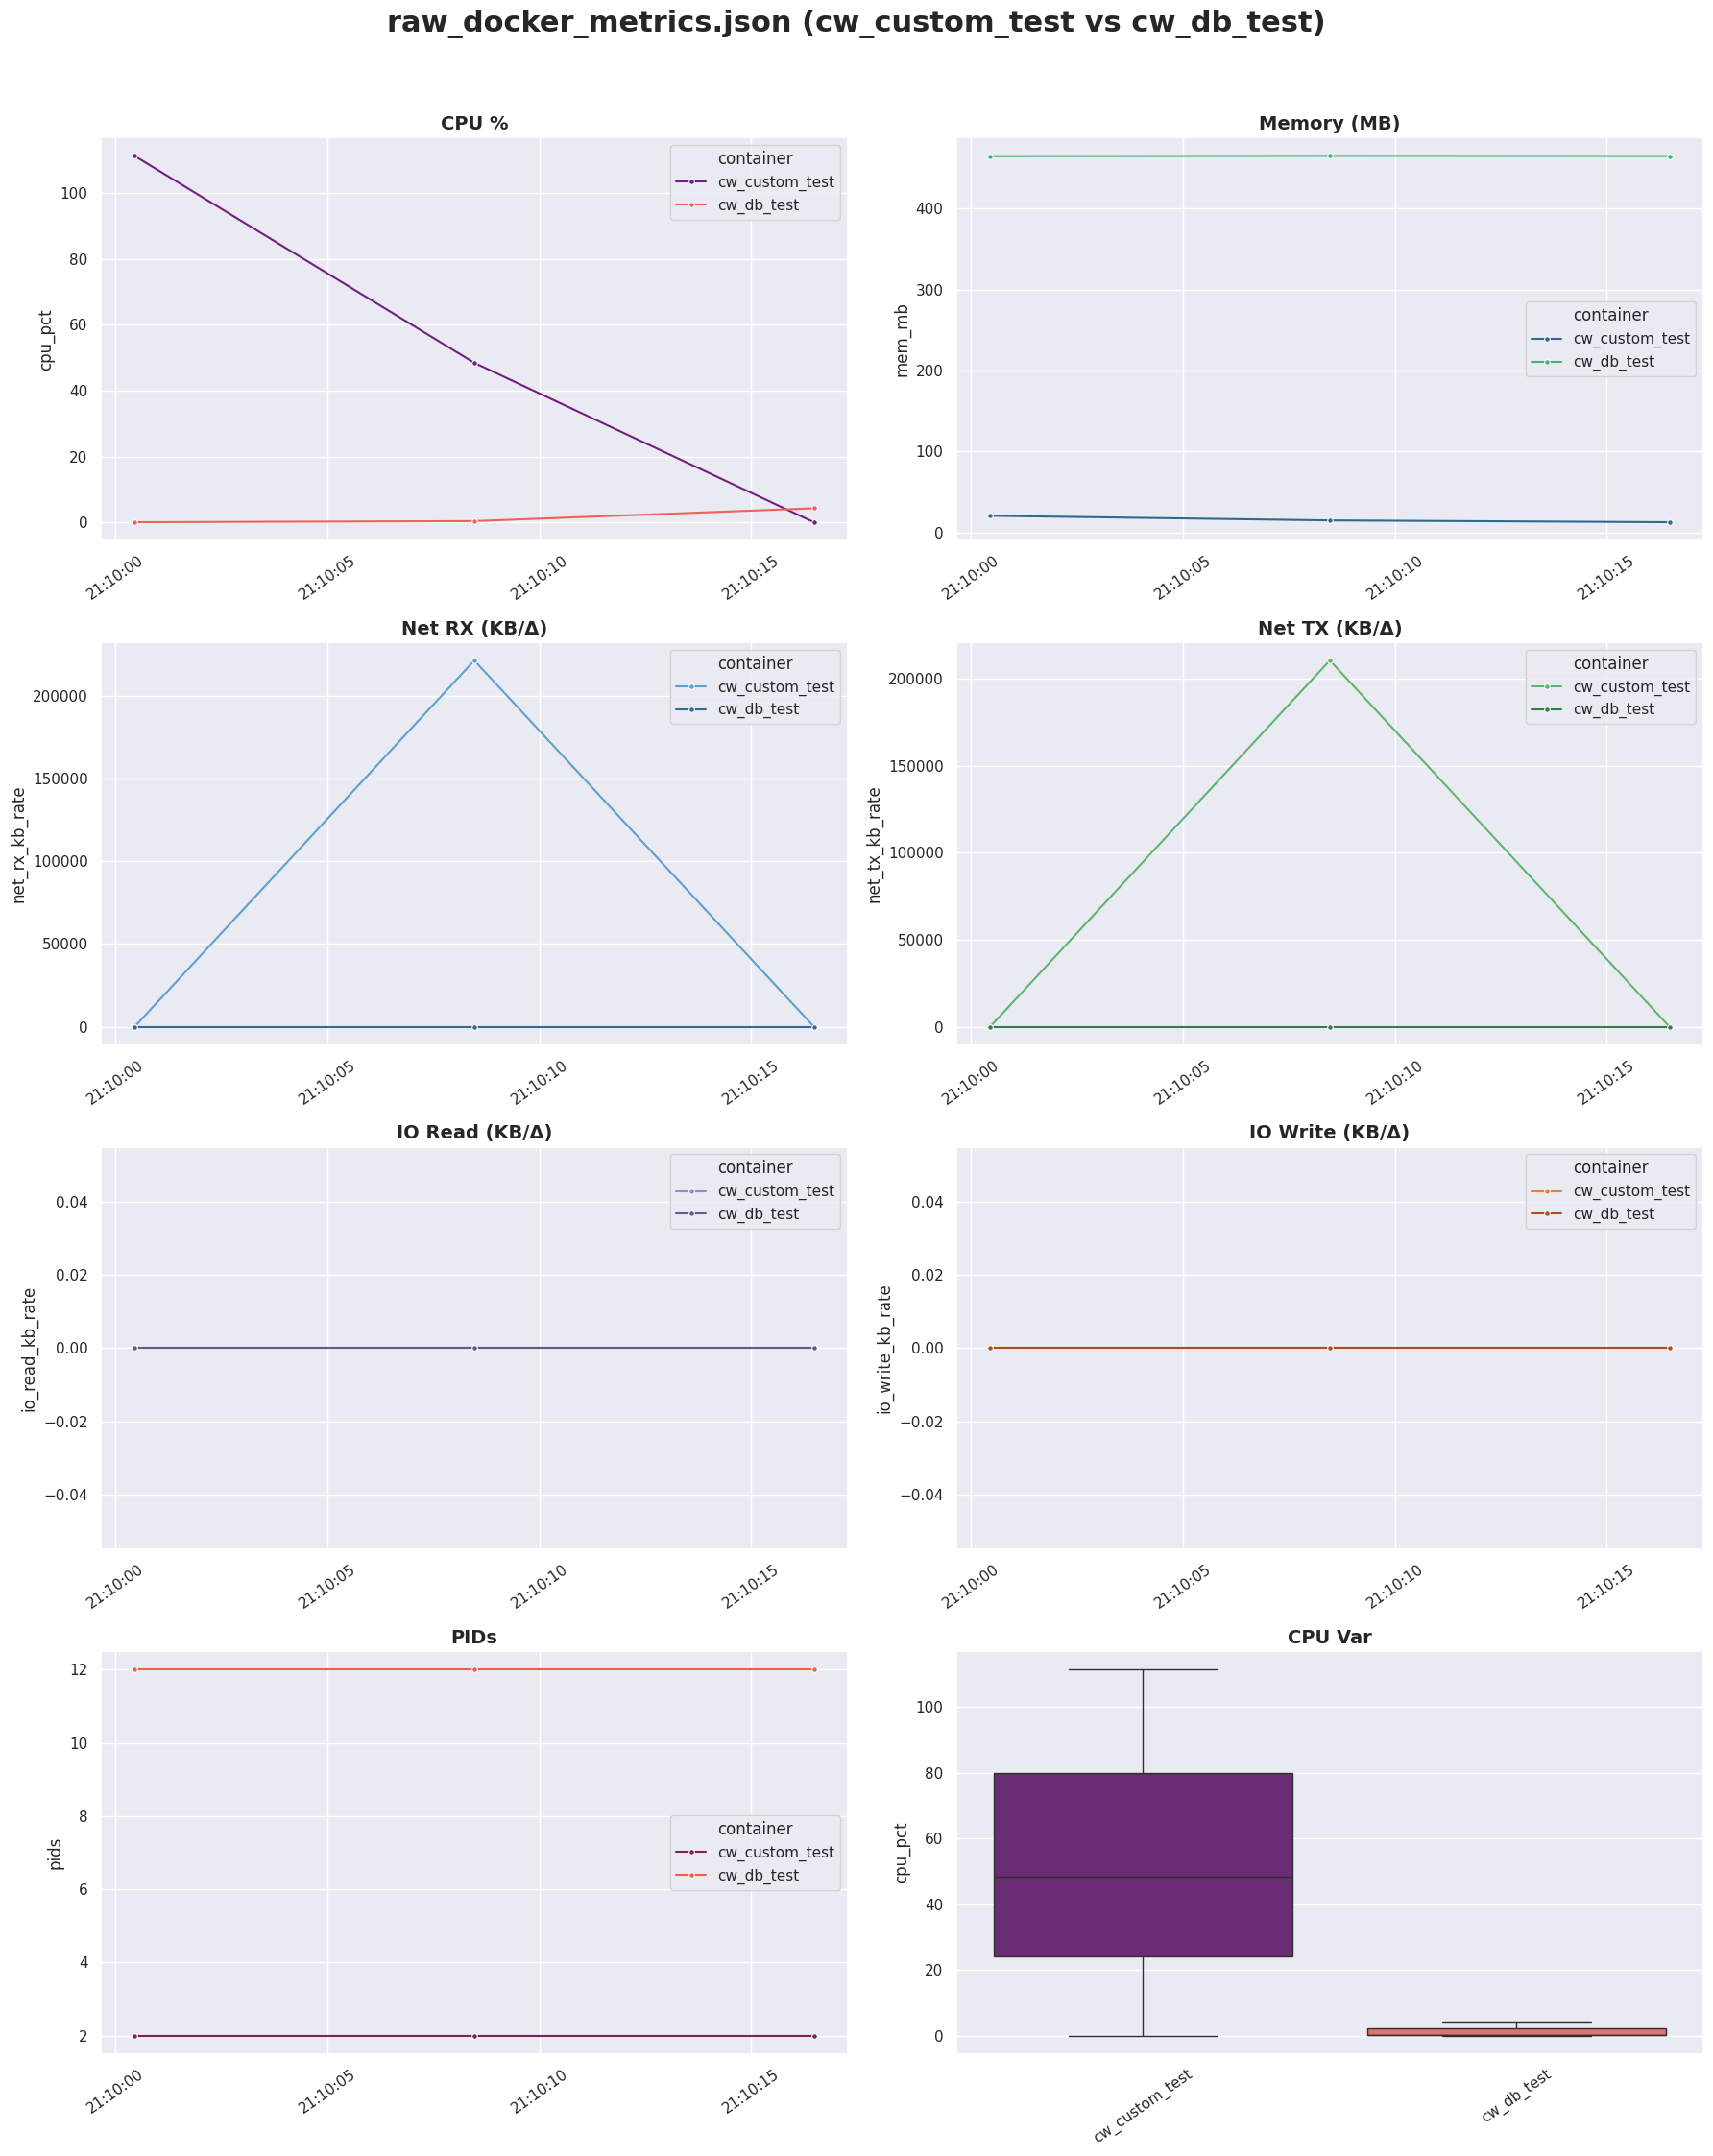

## Test Results

---

Diagram exported as: test_results/hey_2m_1k/1/custom/test_details_analysis.png


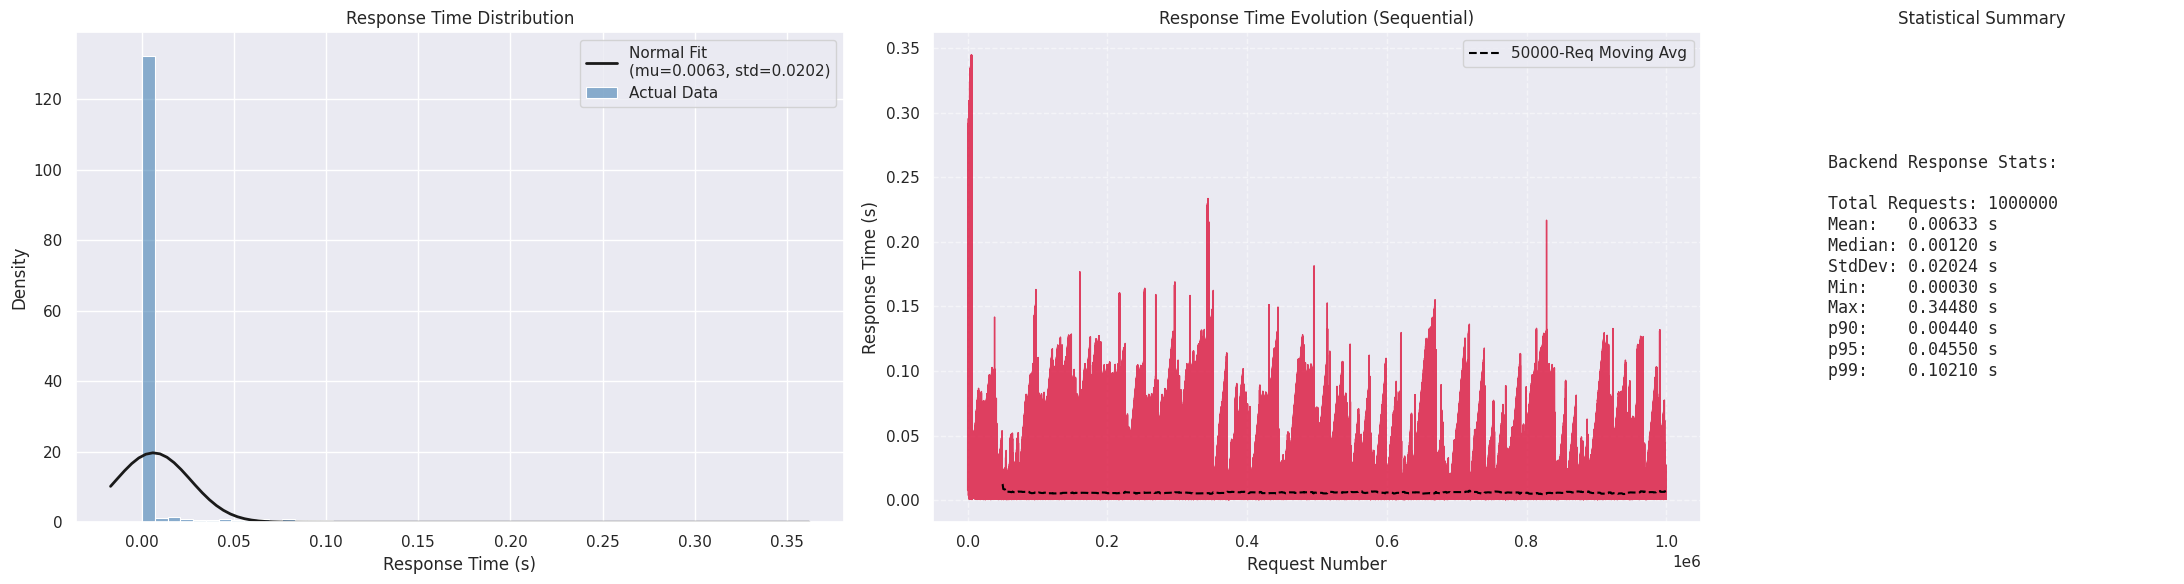

---

# hey_2m_1k / fastapi

---

## System Usage

---

--- raw_docker_metrics.json ---
                    cpu_pct          mem_mb         pids
                       mean     max    mean     max  max
container                                               
cw_db_test             0.94    4.04  464.53  464.61   12
cw_fastapi_baseline  487.58  639.07  417.33  419.49    8
Diagram exported as: test_results/hey_2m_1k/1/fastapi/raw_docker_metrics_analysis.png


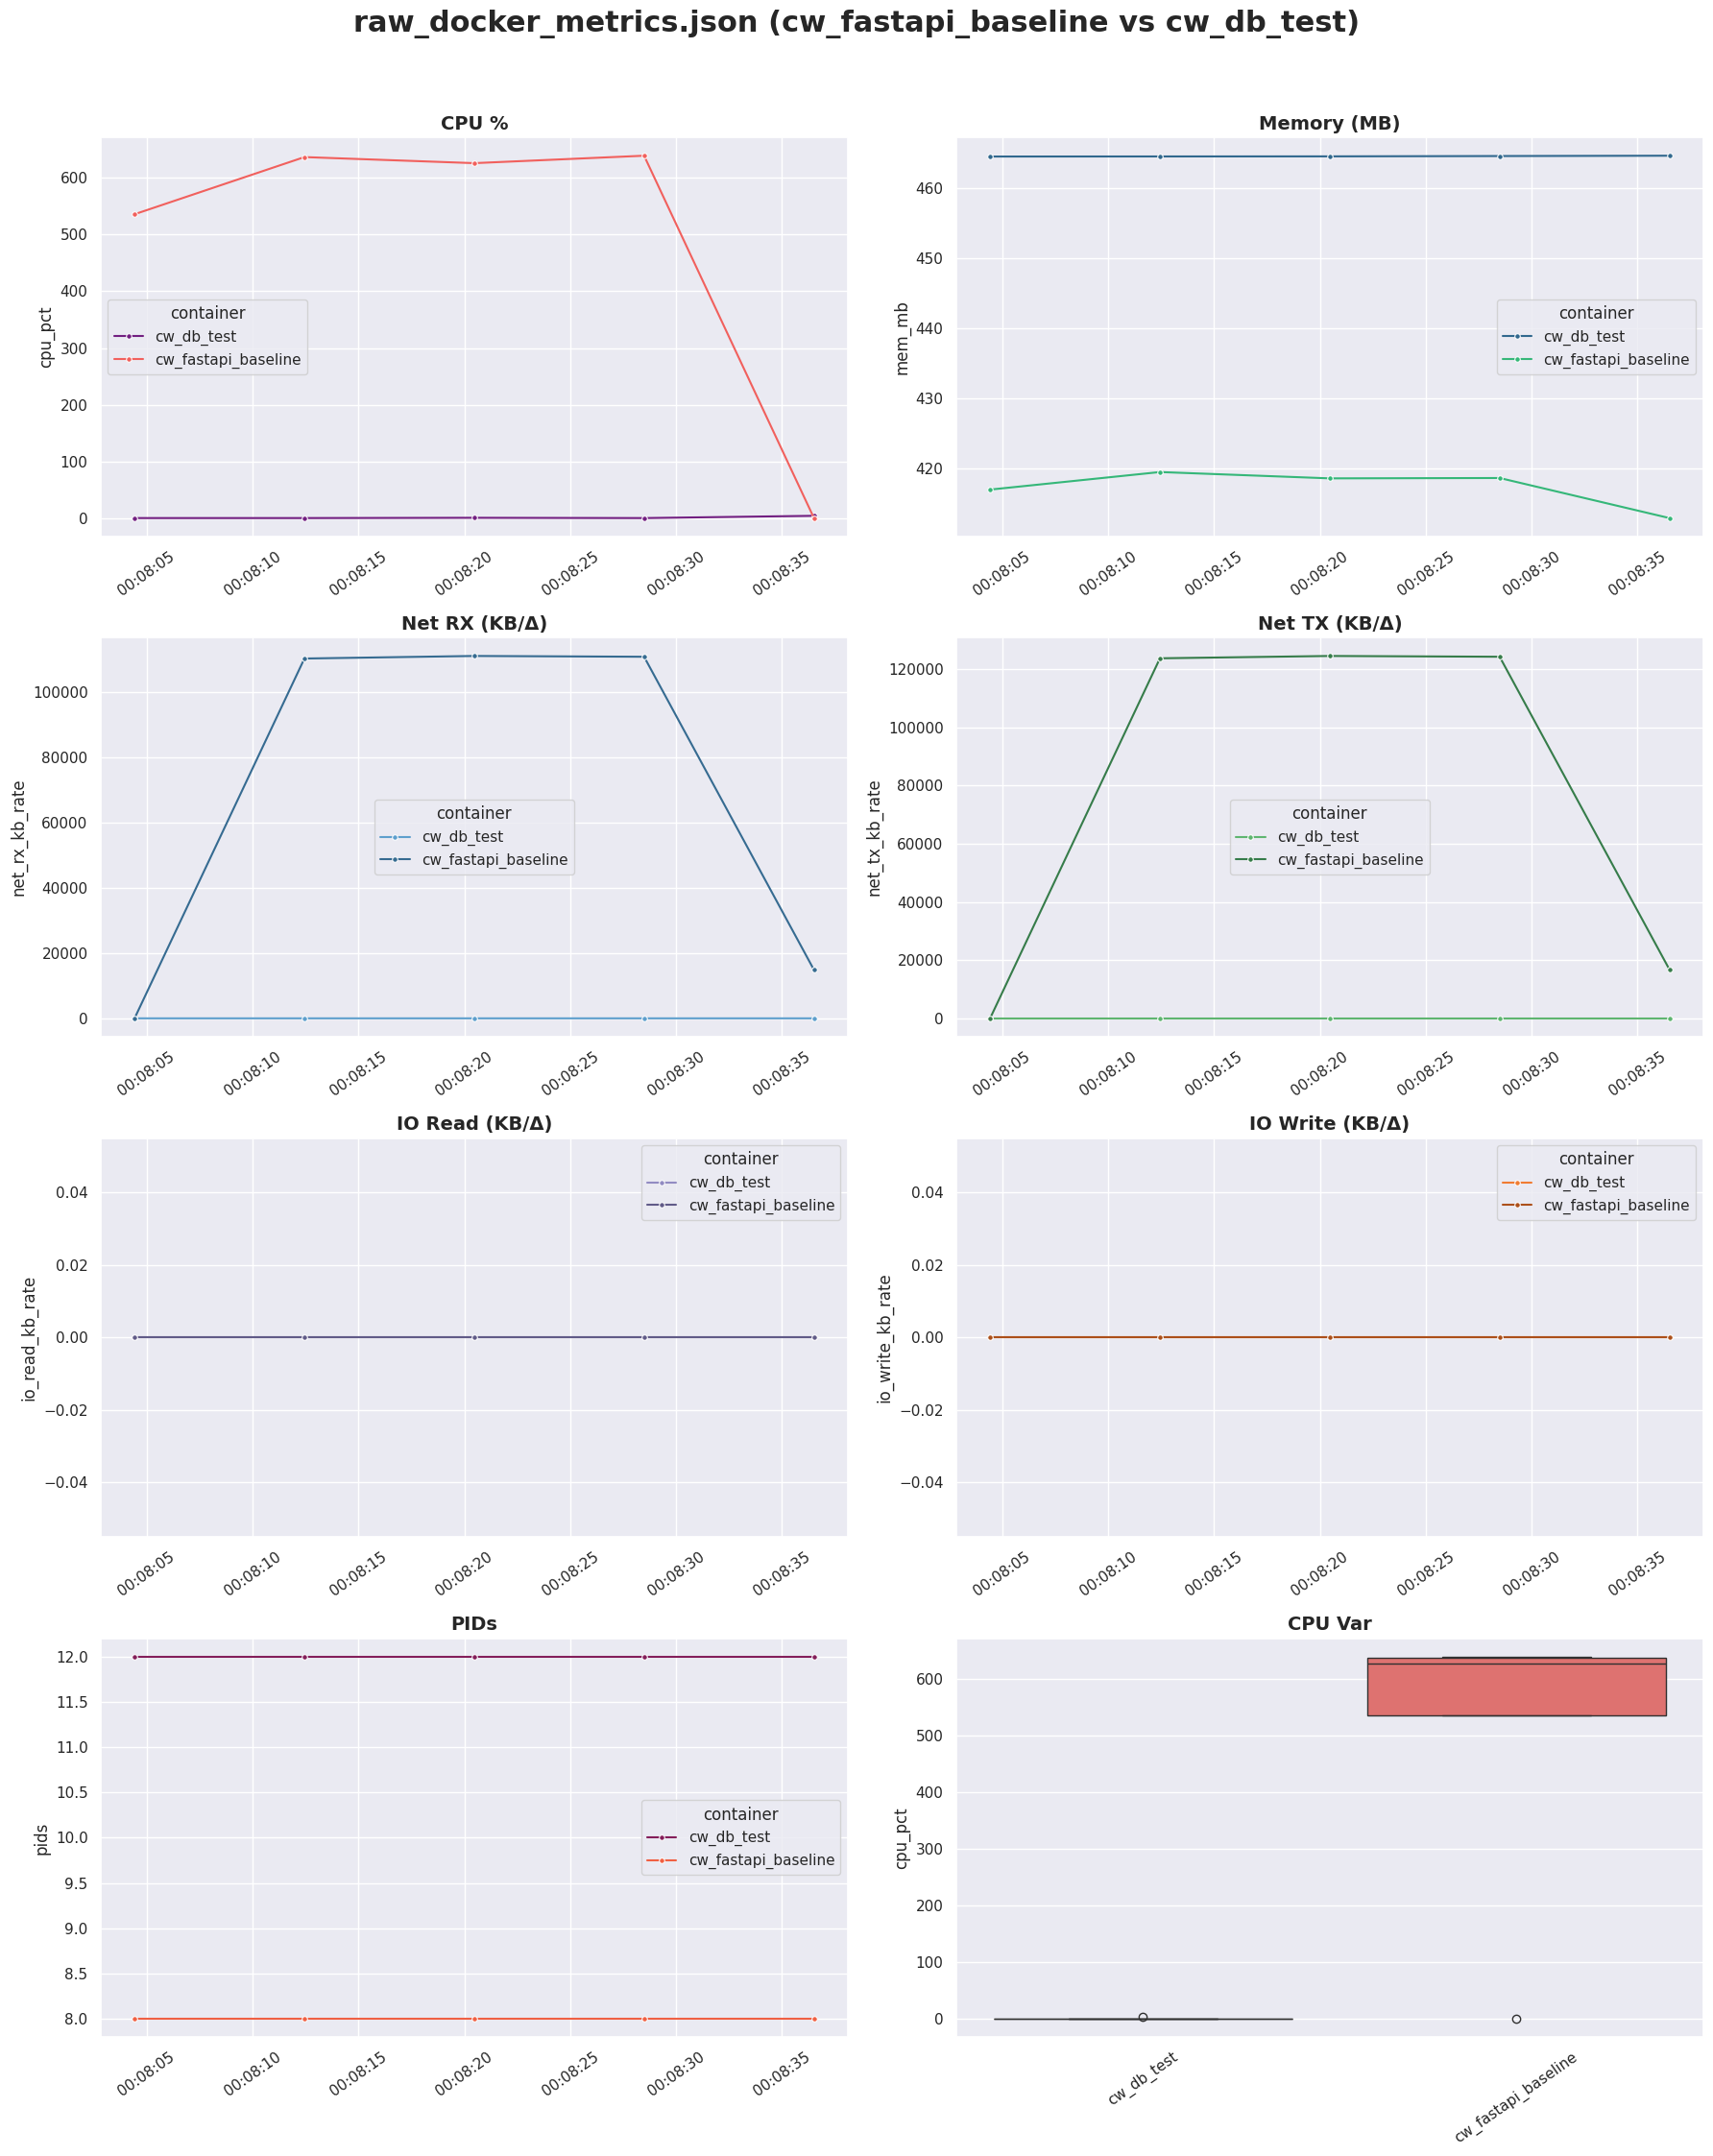

## Test Results

---

Diagram exported as: test_results/hey_2m_1k/1/fastapi/test_details_analysis.png


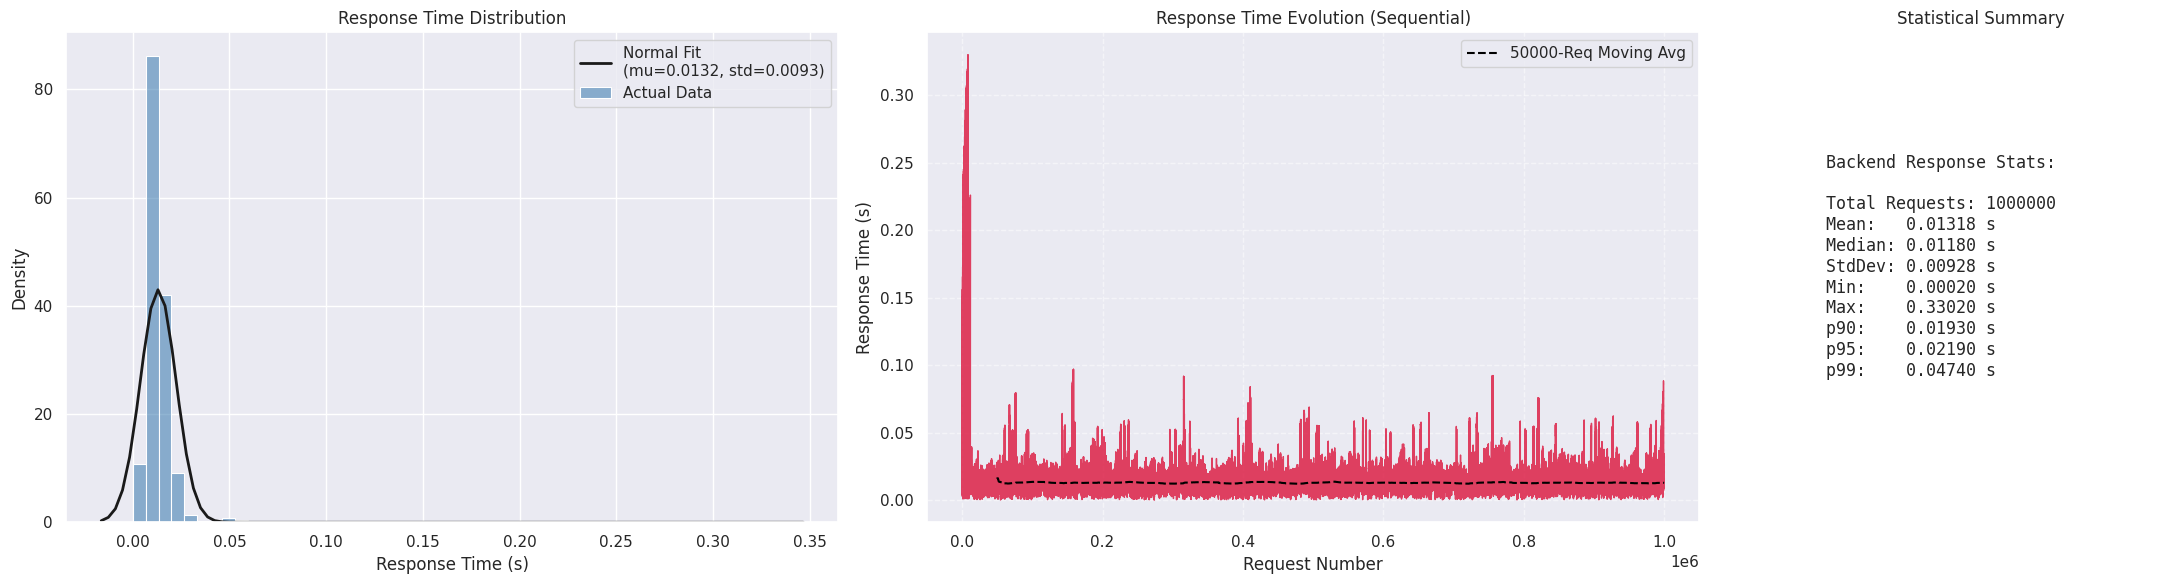

---

# ITERATION 2

---

# locust_v_1_0_0 / axum

---

## System Usage

---

--- raw_docker_metrics.json ---
             cpu_pct        mem_mb         pids
                mean   max    mean     max  max
container                                      
cw_axum_test    0.62  1.96    6.76    7.27   41
cw_db_test      1.21  3.53  533.59  533.64   27
Diagram exported as: test_results/locust_v_1_0_0/2/axum/raw_docker_metrics_analysis.png


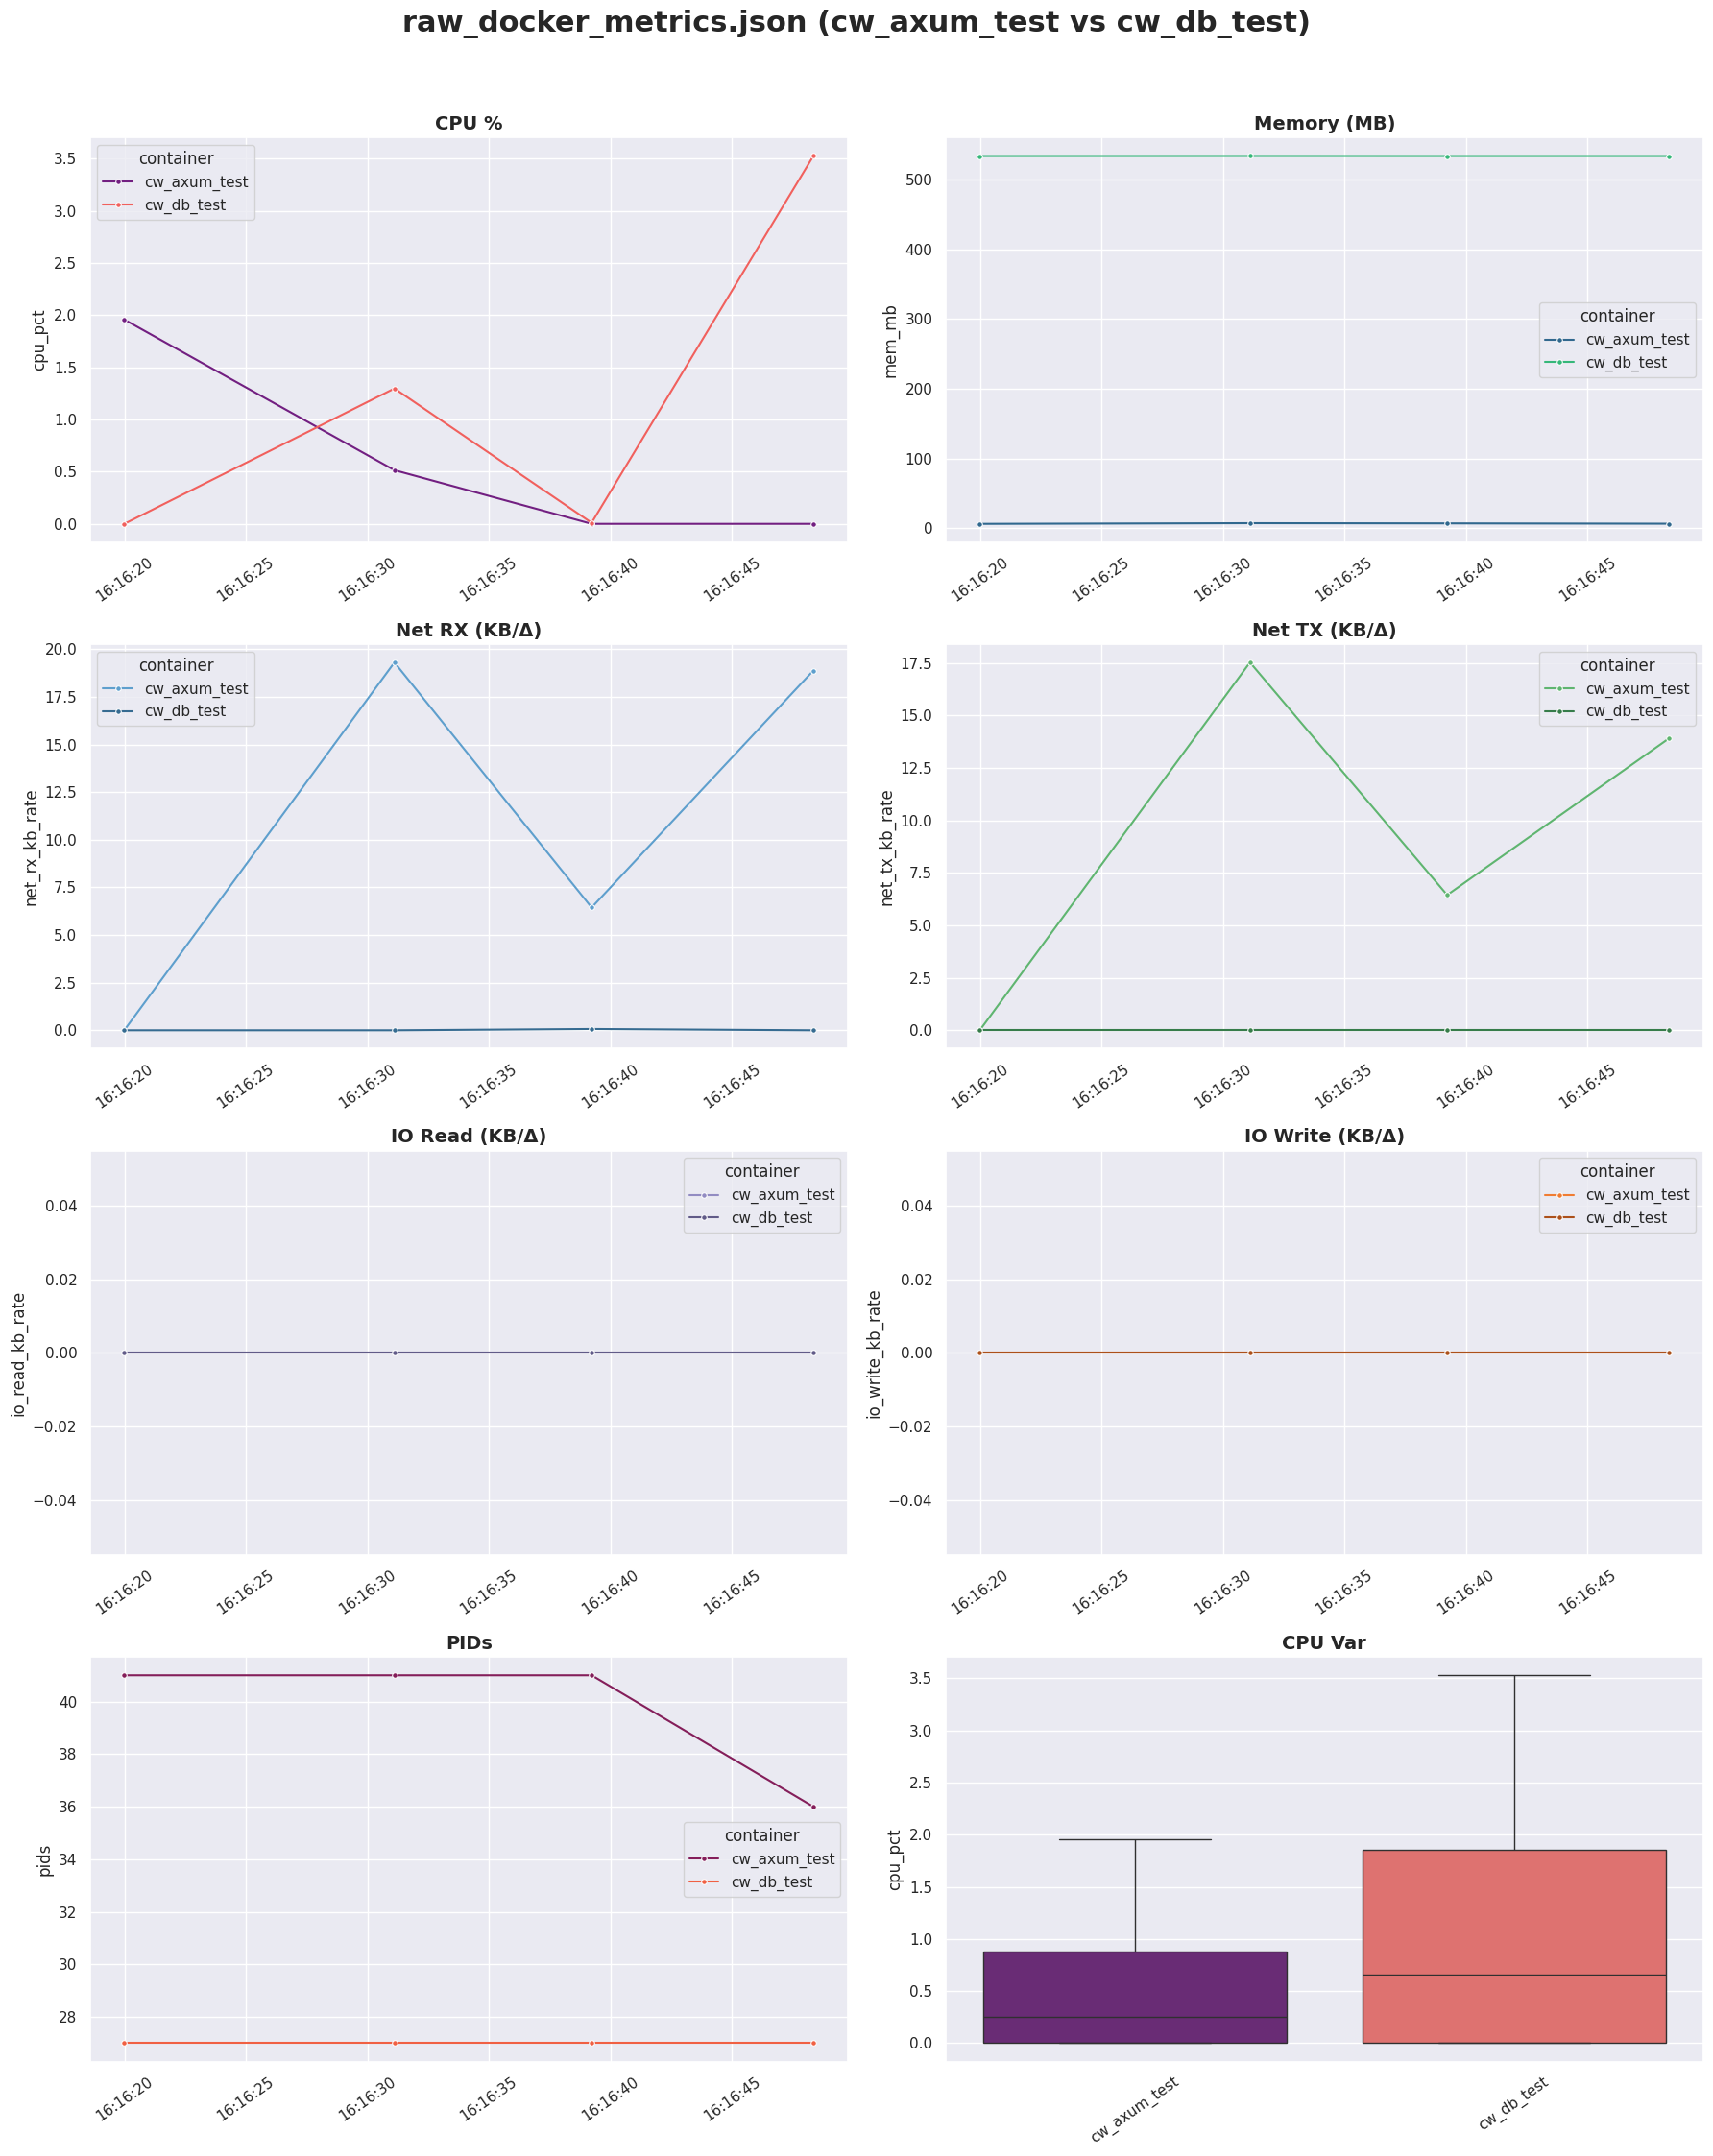

## Test Results

---

--- Grouped Locust Analysis: test_details.json ---
             Endpoint  Requests  Avg RT (ms)    Max_RT        RPS
 /recipes/recipe/{id}      3685     3.498102 73.116439 123.349558
/recipes/recipes/{id}      3659     3.415408 70.729427 122.585791
      /recipes/dishes      1842     3.248731 67.781366  61.725228
Diagram exported as: test_results/locust_v_1_0_0/2/axum/test_details_analysis.png


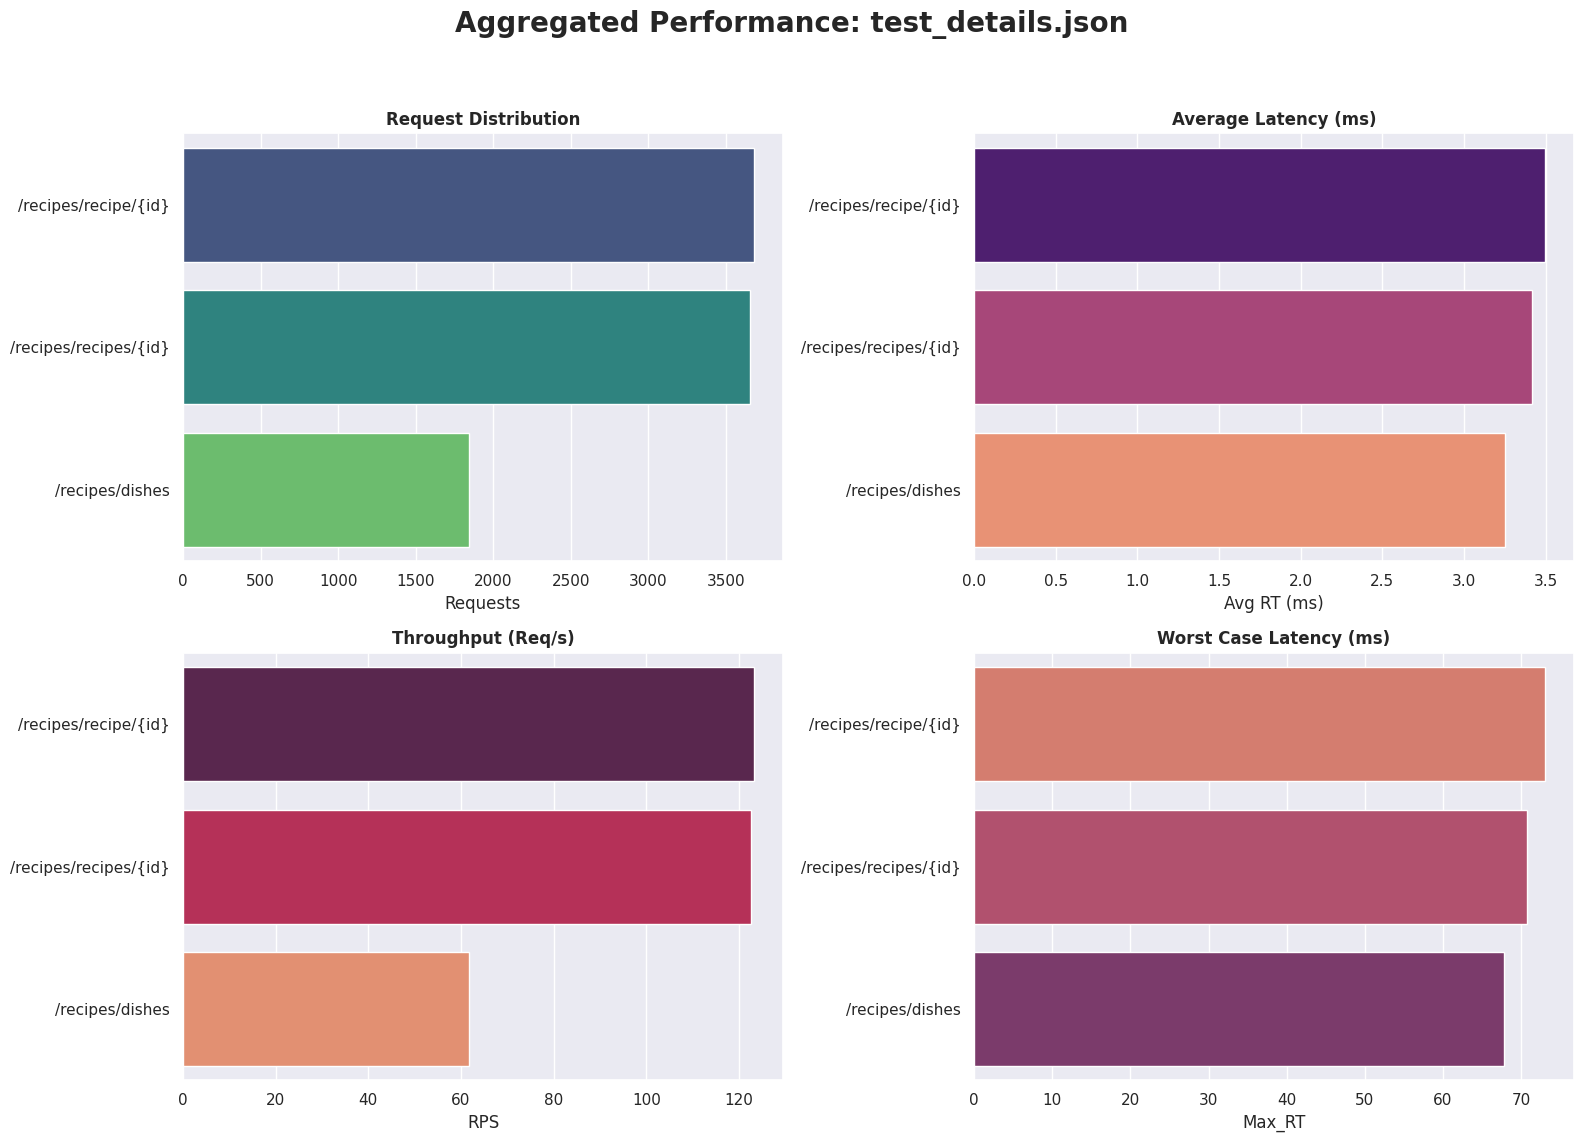

# locust_v_1_0_0 / fastapi

---

## System Usage

---

--- raw_docker_metrics.json ---
                    cpu_pct           mem_mb          pids
                       mean     max     mean      max  max
container                                                 
cw_db_test             0.11    0.42   533.56   533.57   27
cw_fastapi_baseline   77.19  108.12  1571.85  1572.27   62
Diagram exported as: test_results/locust_v_1_0_0/2/fastapi/raw_docker_metrics_analysis.png


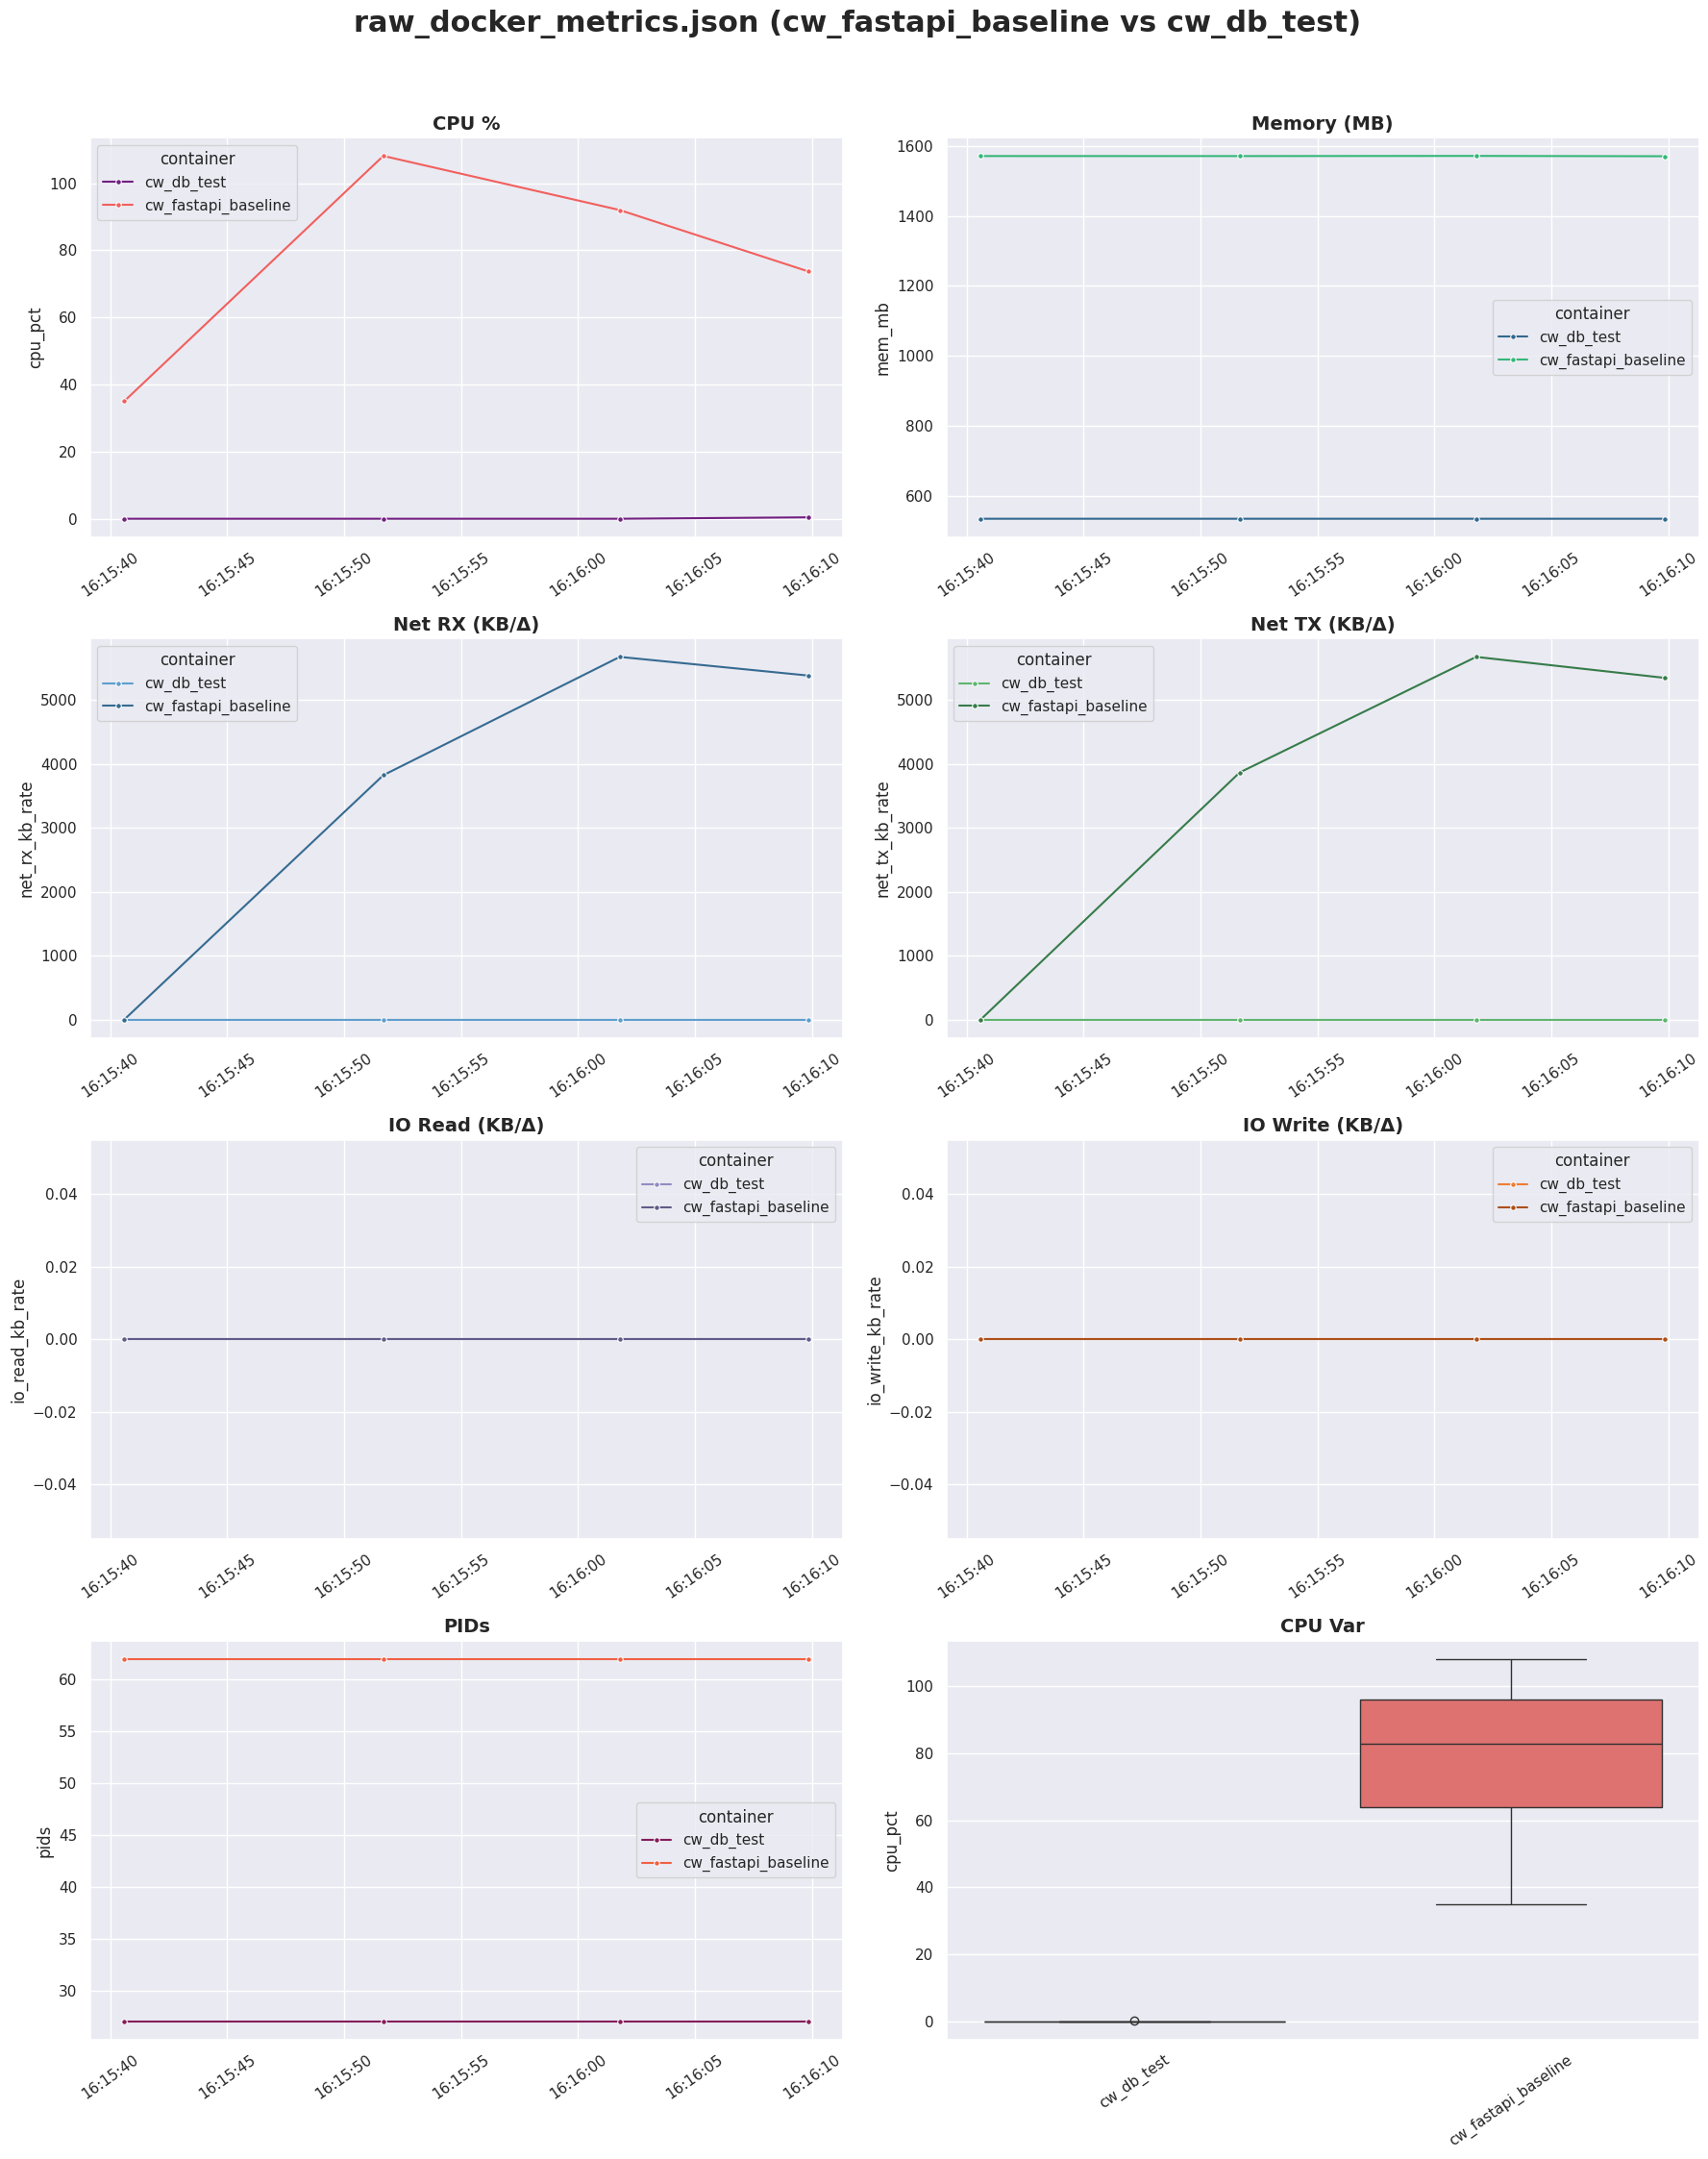

## Test Results

---

--- Grouped Locust Analysis: test_details.json ---
             Endpoint  Requests  Avg RT (ms)    Max_RT        RPS
 /recipes/recipe/{id}      3717     5.241280 72.807387 124.332196
/recipes/recipes/{id}      3650     4.971564 71.951817 122.110619
      /recipes/dishes      1856     5.040666 71.789785  62.121794
Diagram exported as: test_results/locust_v_1_0_0/2/fastapi/test_details_analysis.png


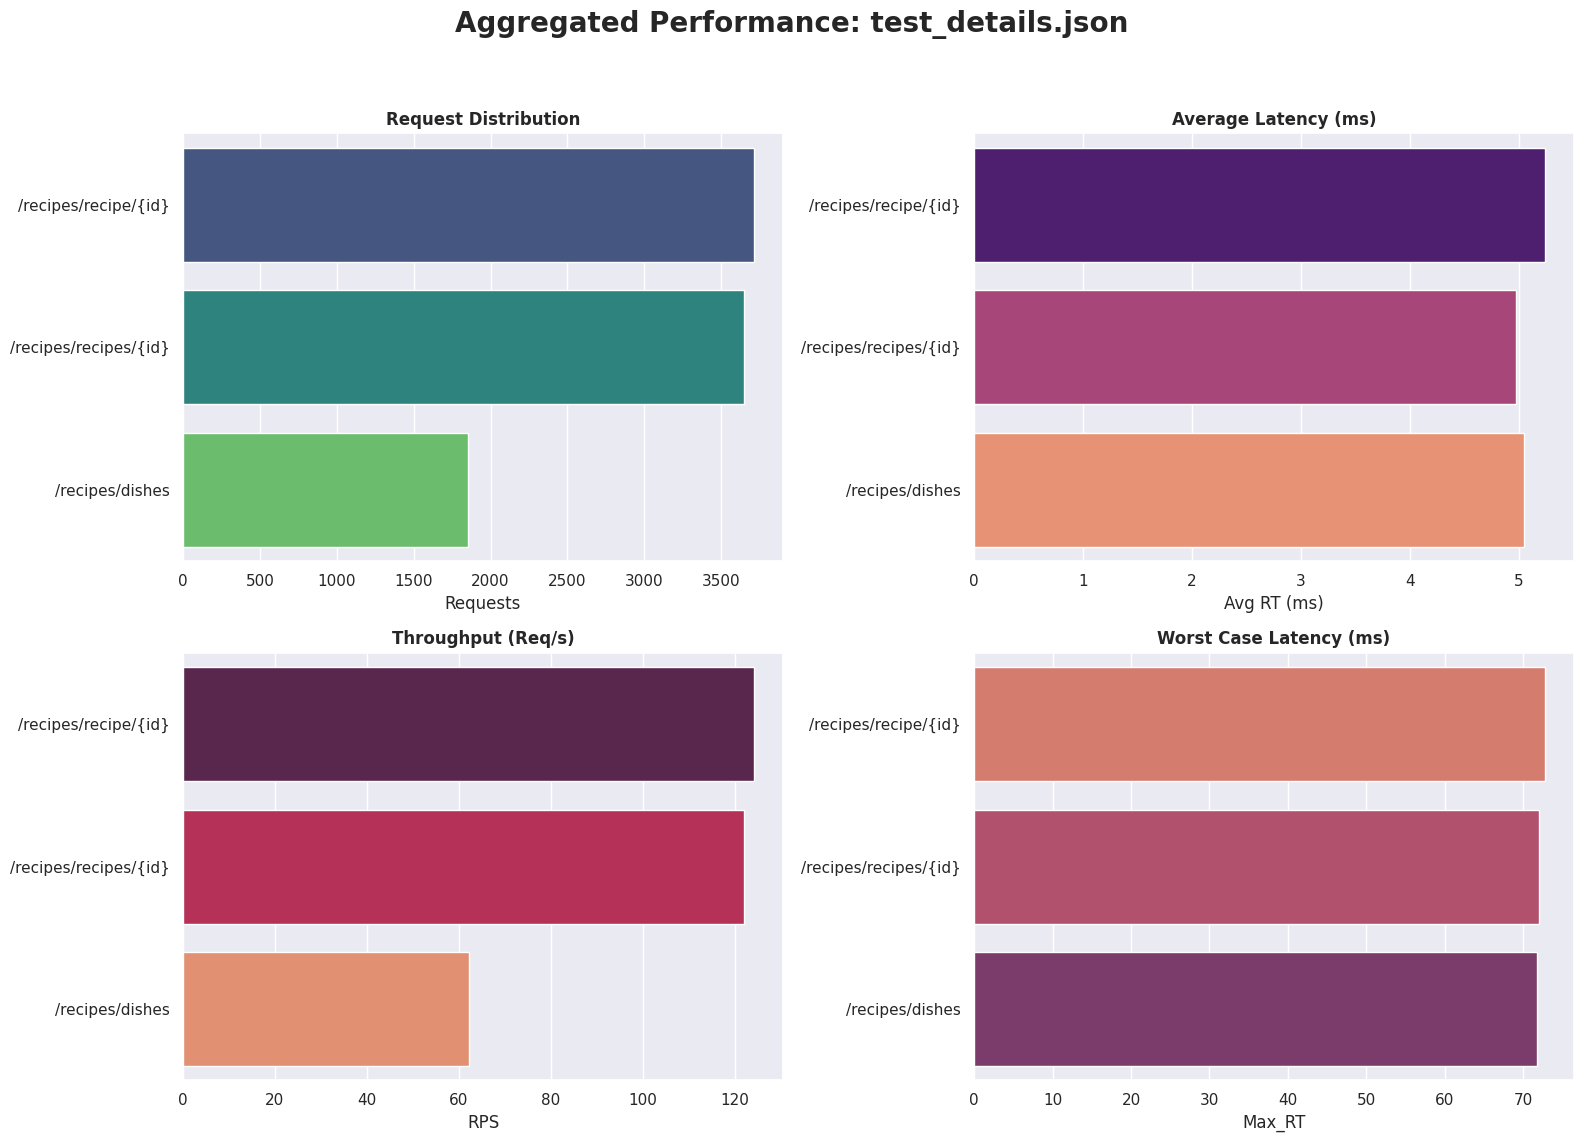

# k6_break_test / axum

---

## System Usage

---

--- raw_docker_metrics.json ---
             cpu_pct        mem_mb         pids
                mean   max    mean     max  max
container                                      
cw_axum_test    0.48  0.96    2.73    3.34   22
cw_db_test      1.40  2.95  533.59  533.63   27
Diagram exported as: test_results/k6_break_test/2/axum/raw_docker_metrics_analysis.png


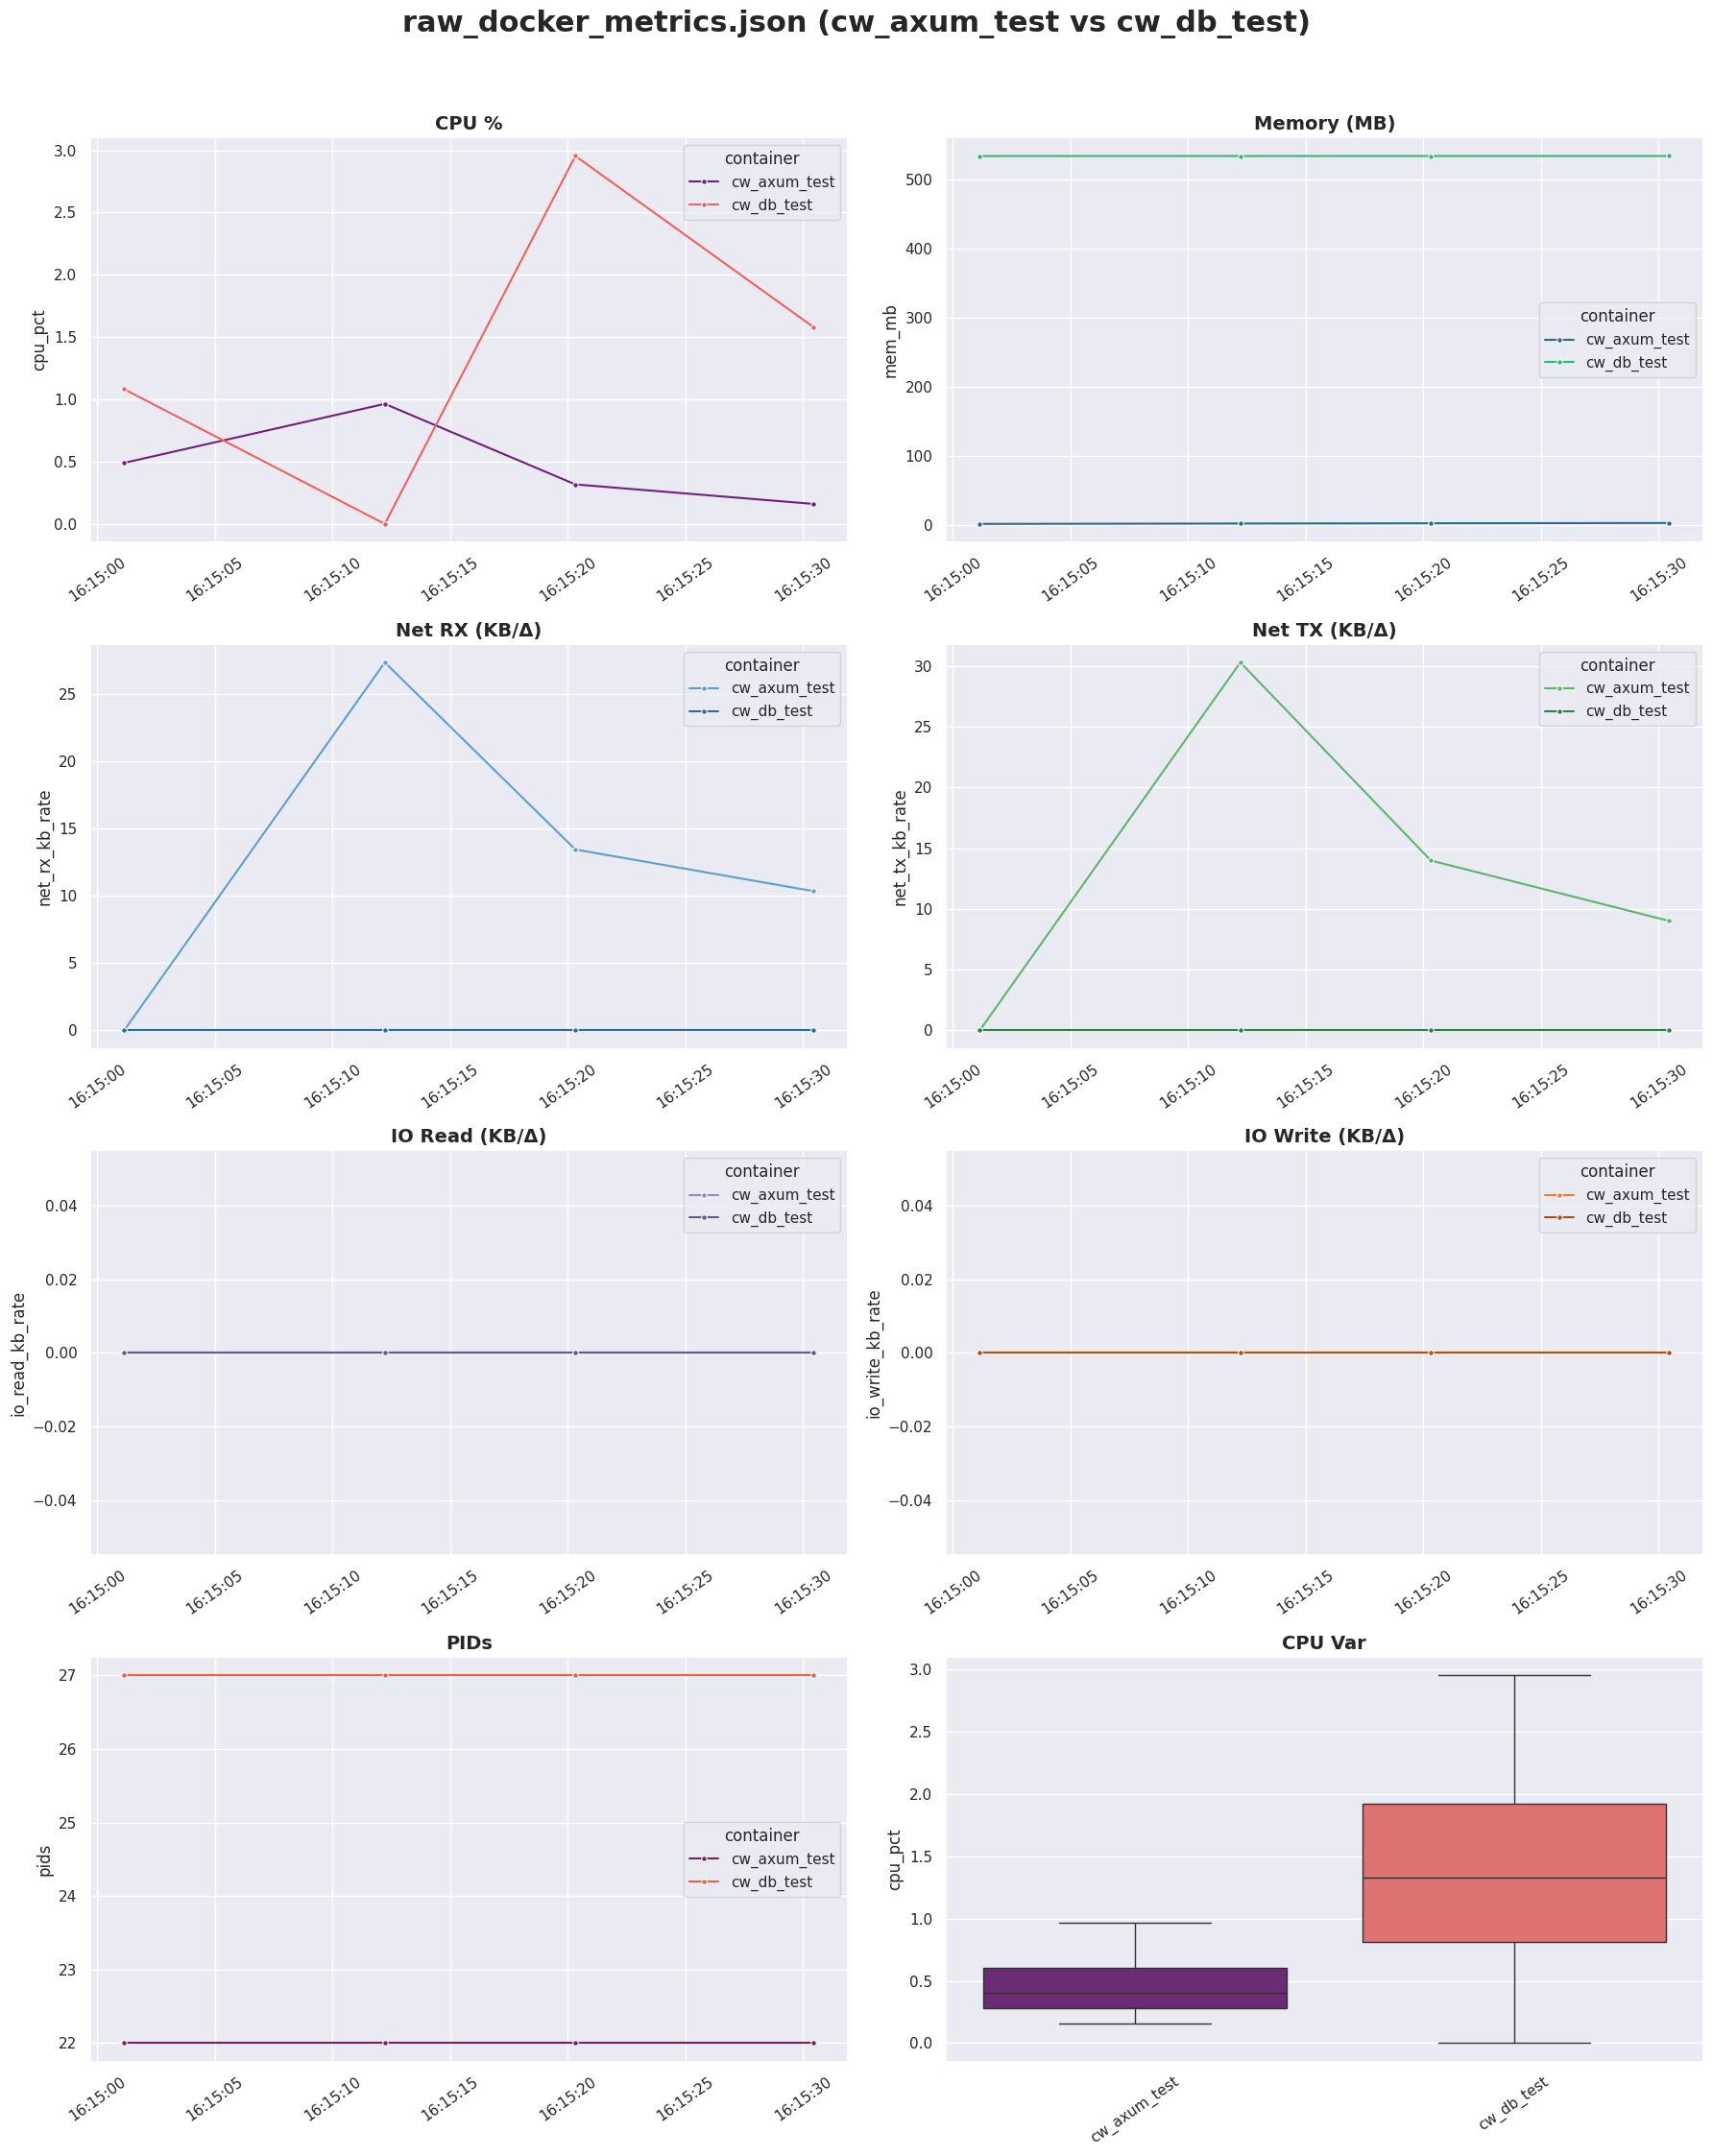

## Test Results

---

 K6 LOAD TEST ANALYSIS: test_details.json
Throughput:      17165.60 req/s
Total Requests:  7,235,266
Max Concurrency: 50000 VUs
Failure Rate:    0.57%
----------------------------------------
Latency (Duration):
  Avg: 197.06ms
  Med: 40.74ms
  p(90): 525.72ms
  p(95): 815.87ms
  Max: 5204.94ms

Diagram exported as: test_results/k6_break_test/2/axum/test_details_analysis.png


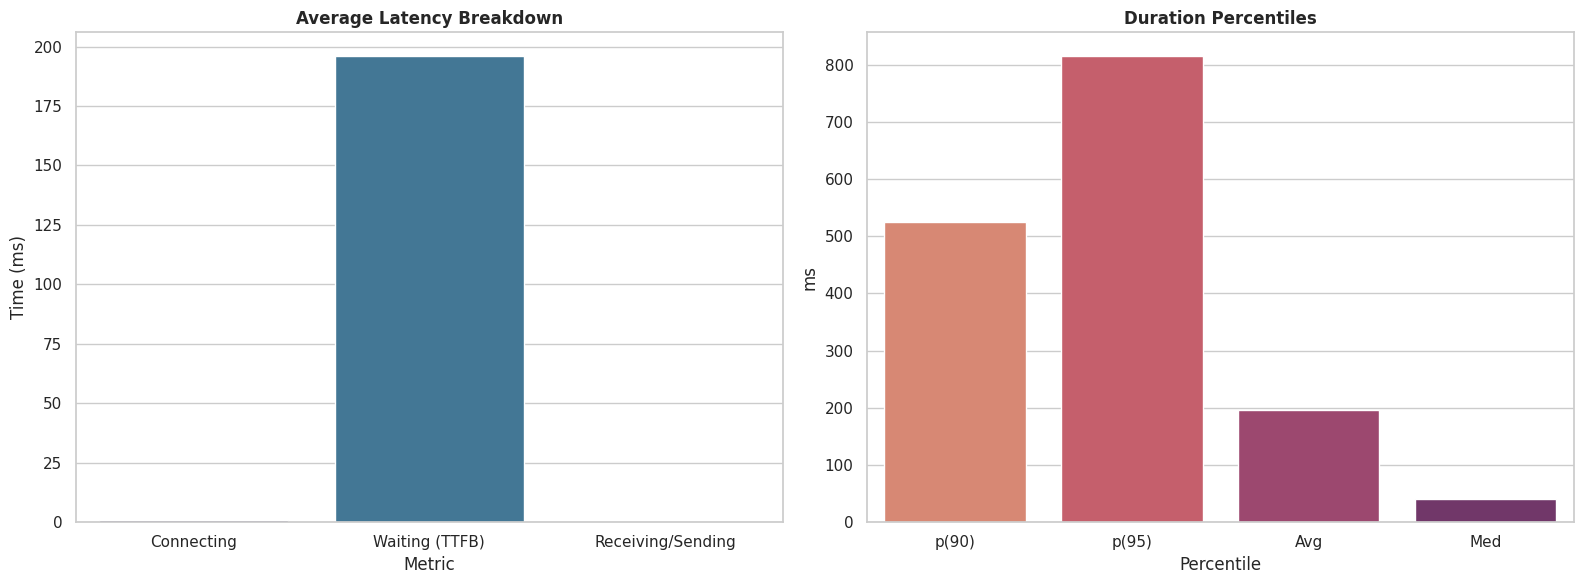

# k6_break_test / fastapi

---

## System Usage

---

--- raw_docker_metrics.json ---
                    cpu_pct            mem_mb          pids
                       mean      max     mean      max  max
container                                                  
cw_db_test             0.92    12.54   533.20   533.59   27
cw_fastapi_baseline  605.56  1172.37  1096.95  1584.62   62
Diagram exported as: test_results/k6_break_test/2/fastapi/raw_docker_metrics_analysis.png


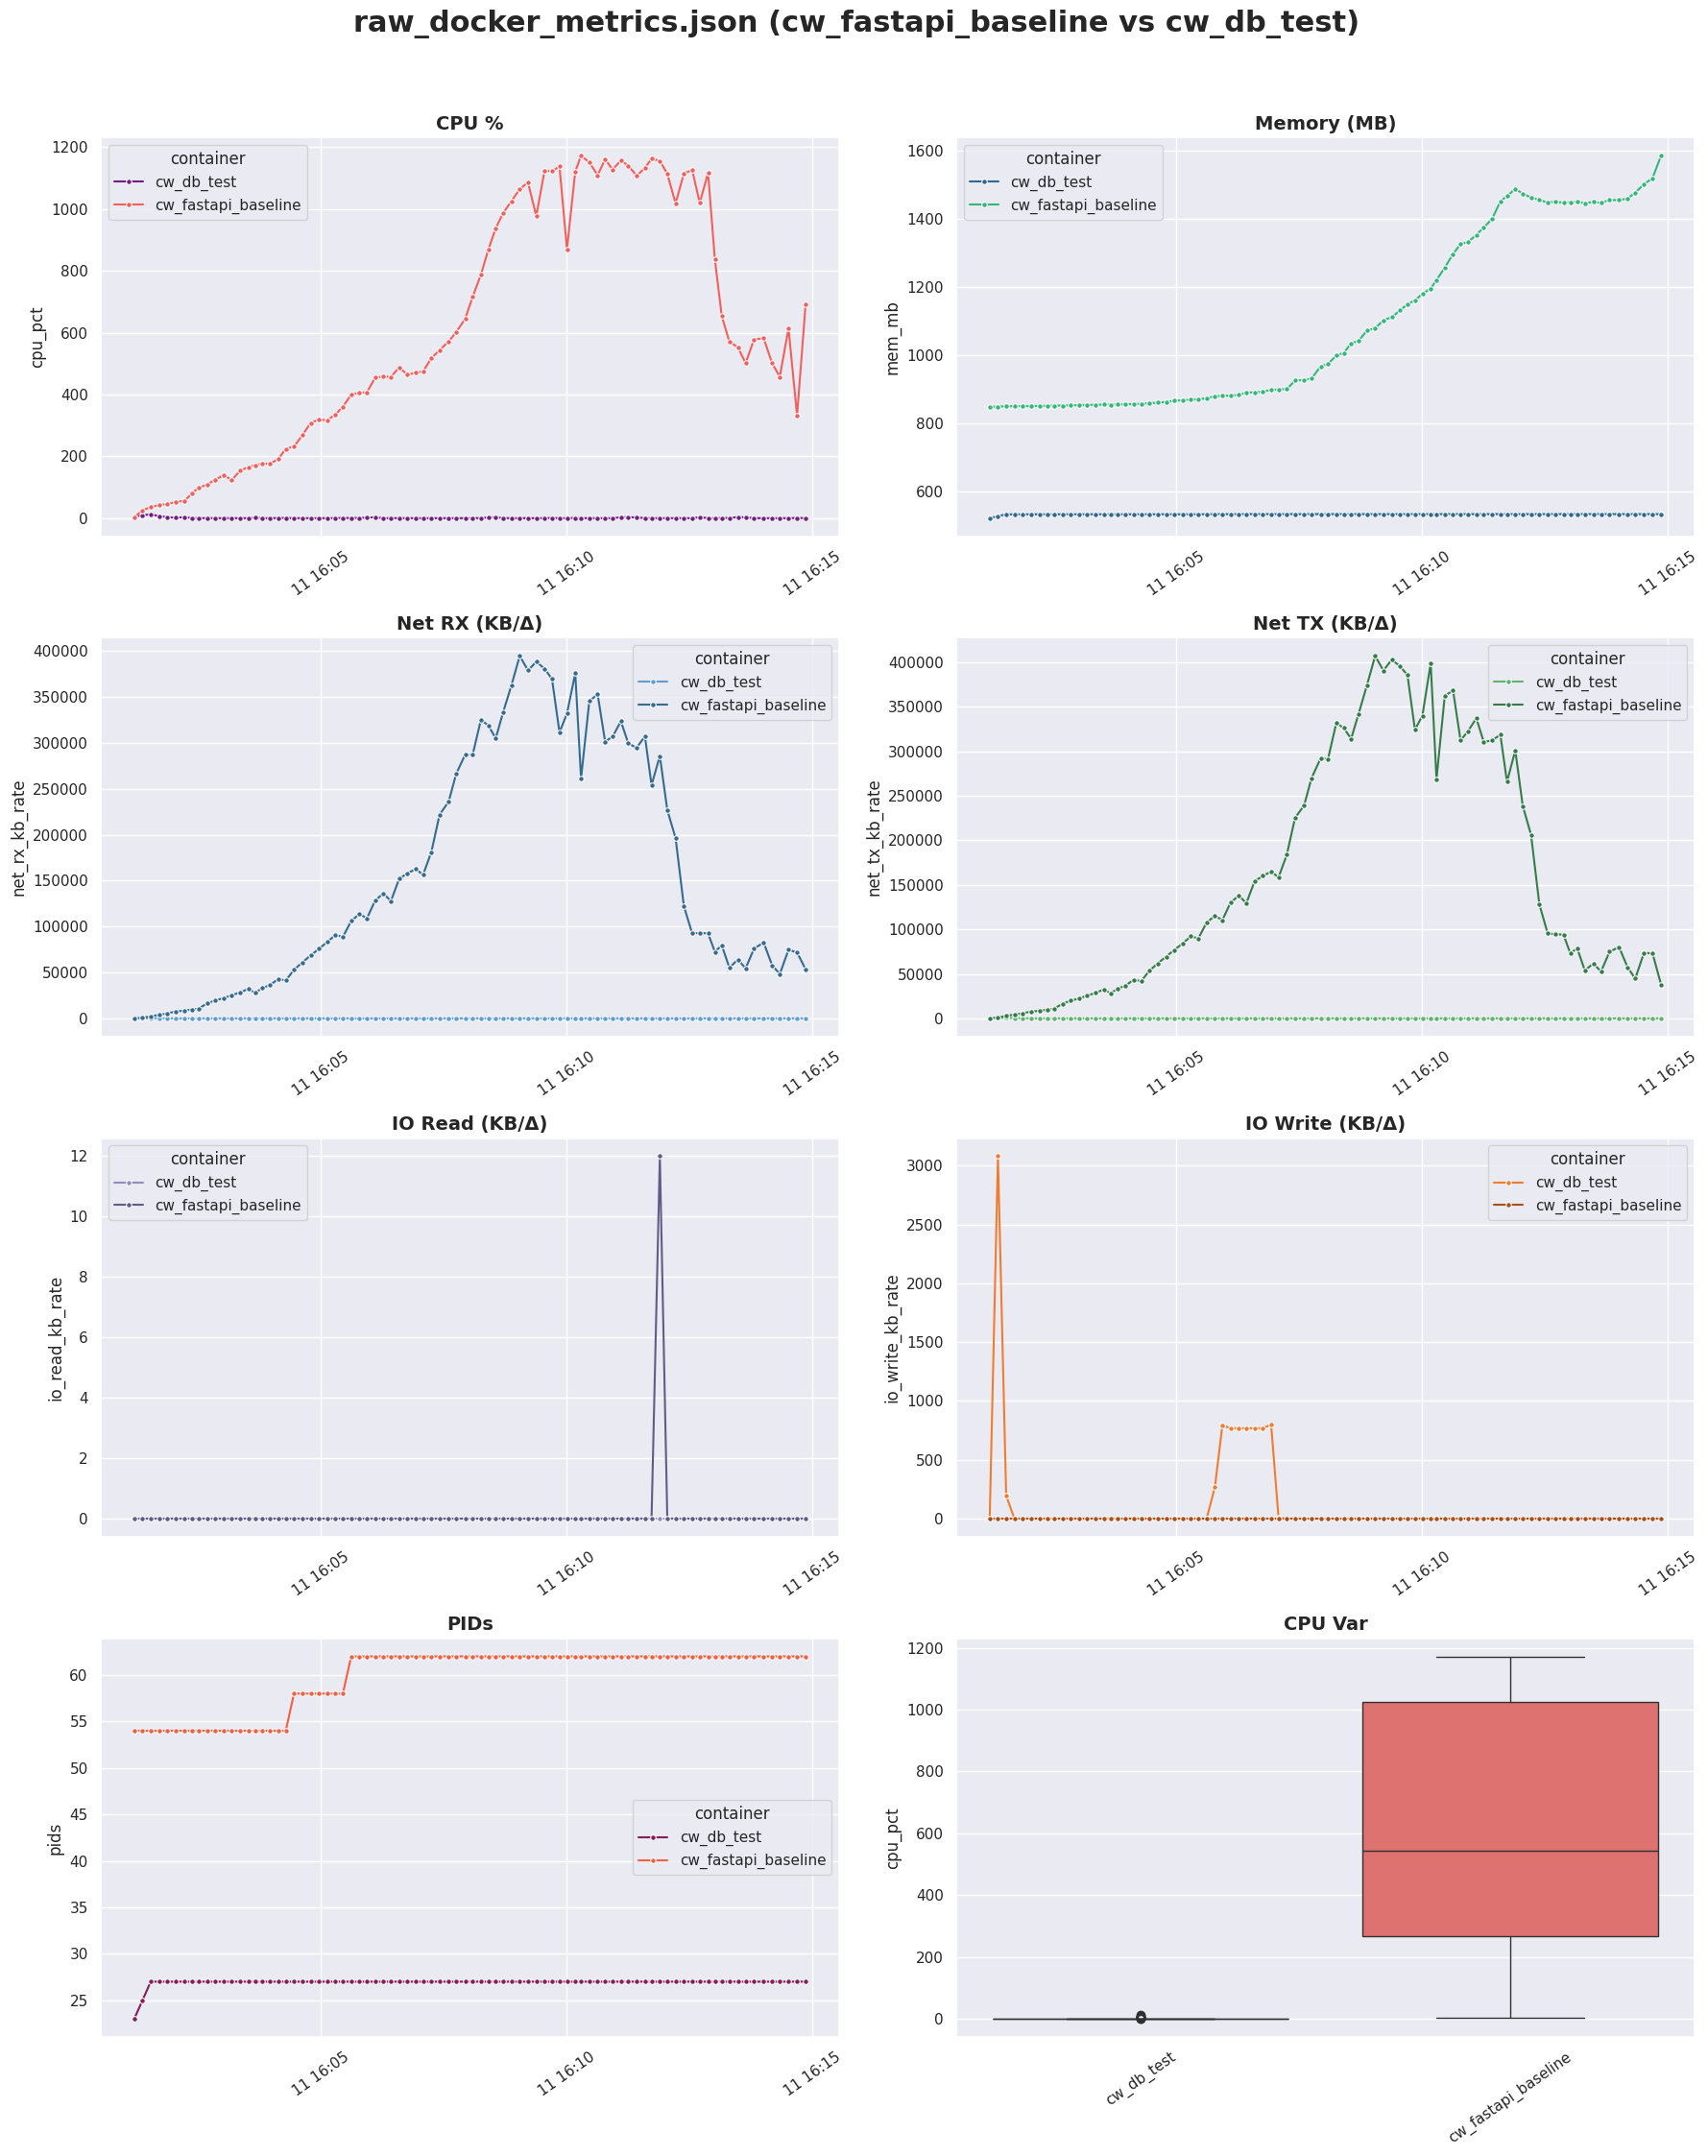

## Test Results

---

 K6 LOAD TEST ANALYSIS: test_details.json
Throughput:      6700.39 req/s
Total Requests:  2,318,697
Max Concurrency: 50000 VUs
Failure Rate:    0.60%
----------------------------------------
Latency (Duration):
  Avg: 927.18ms
  Med: 263.06ms
  p(90): 939.95ms
  p(95): 1584.75ms
  Max: 62319.52ms

Diagram exported as: test_results/k6_break_test/2/fastapi/test_details_analysis.png


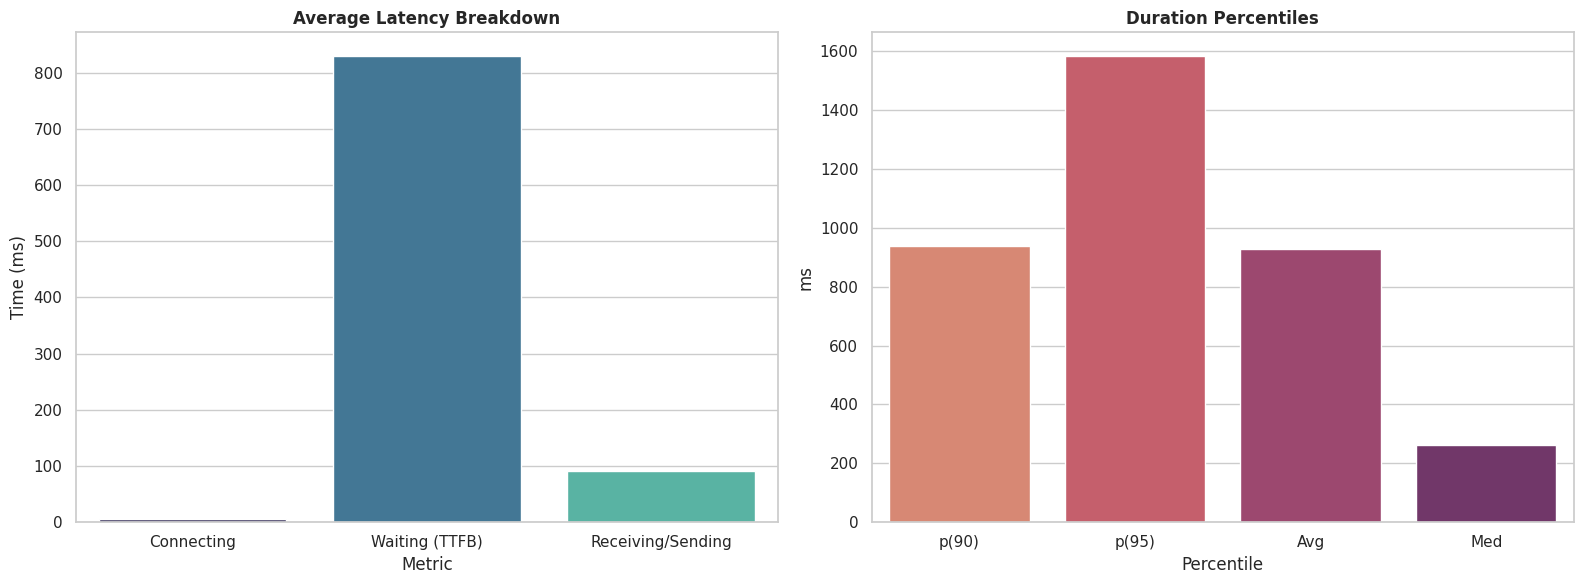

# ITERATION 3

---

# locust_v_1_0_0 / axum

---

## System Usage

---

--- raw_docker_metrics.json ---
             cpu_pct          mem_mb         pids
                mean     max    mean     max  max
container                                        
cw_axum_test     6.5   10.72  727.27  735.94   21
cw_db_test     200.8  296.70  774.27  776.40   45
Diagram exported as: test_results/locust_v_1_0_0/3/axum/raw_docker_metrics_analysis.png


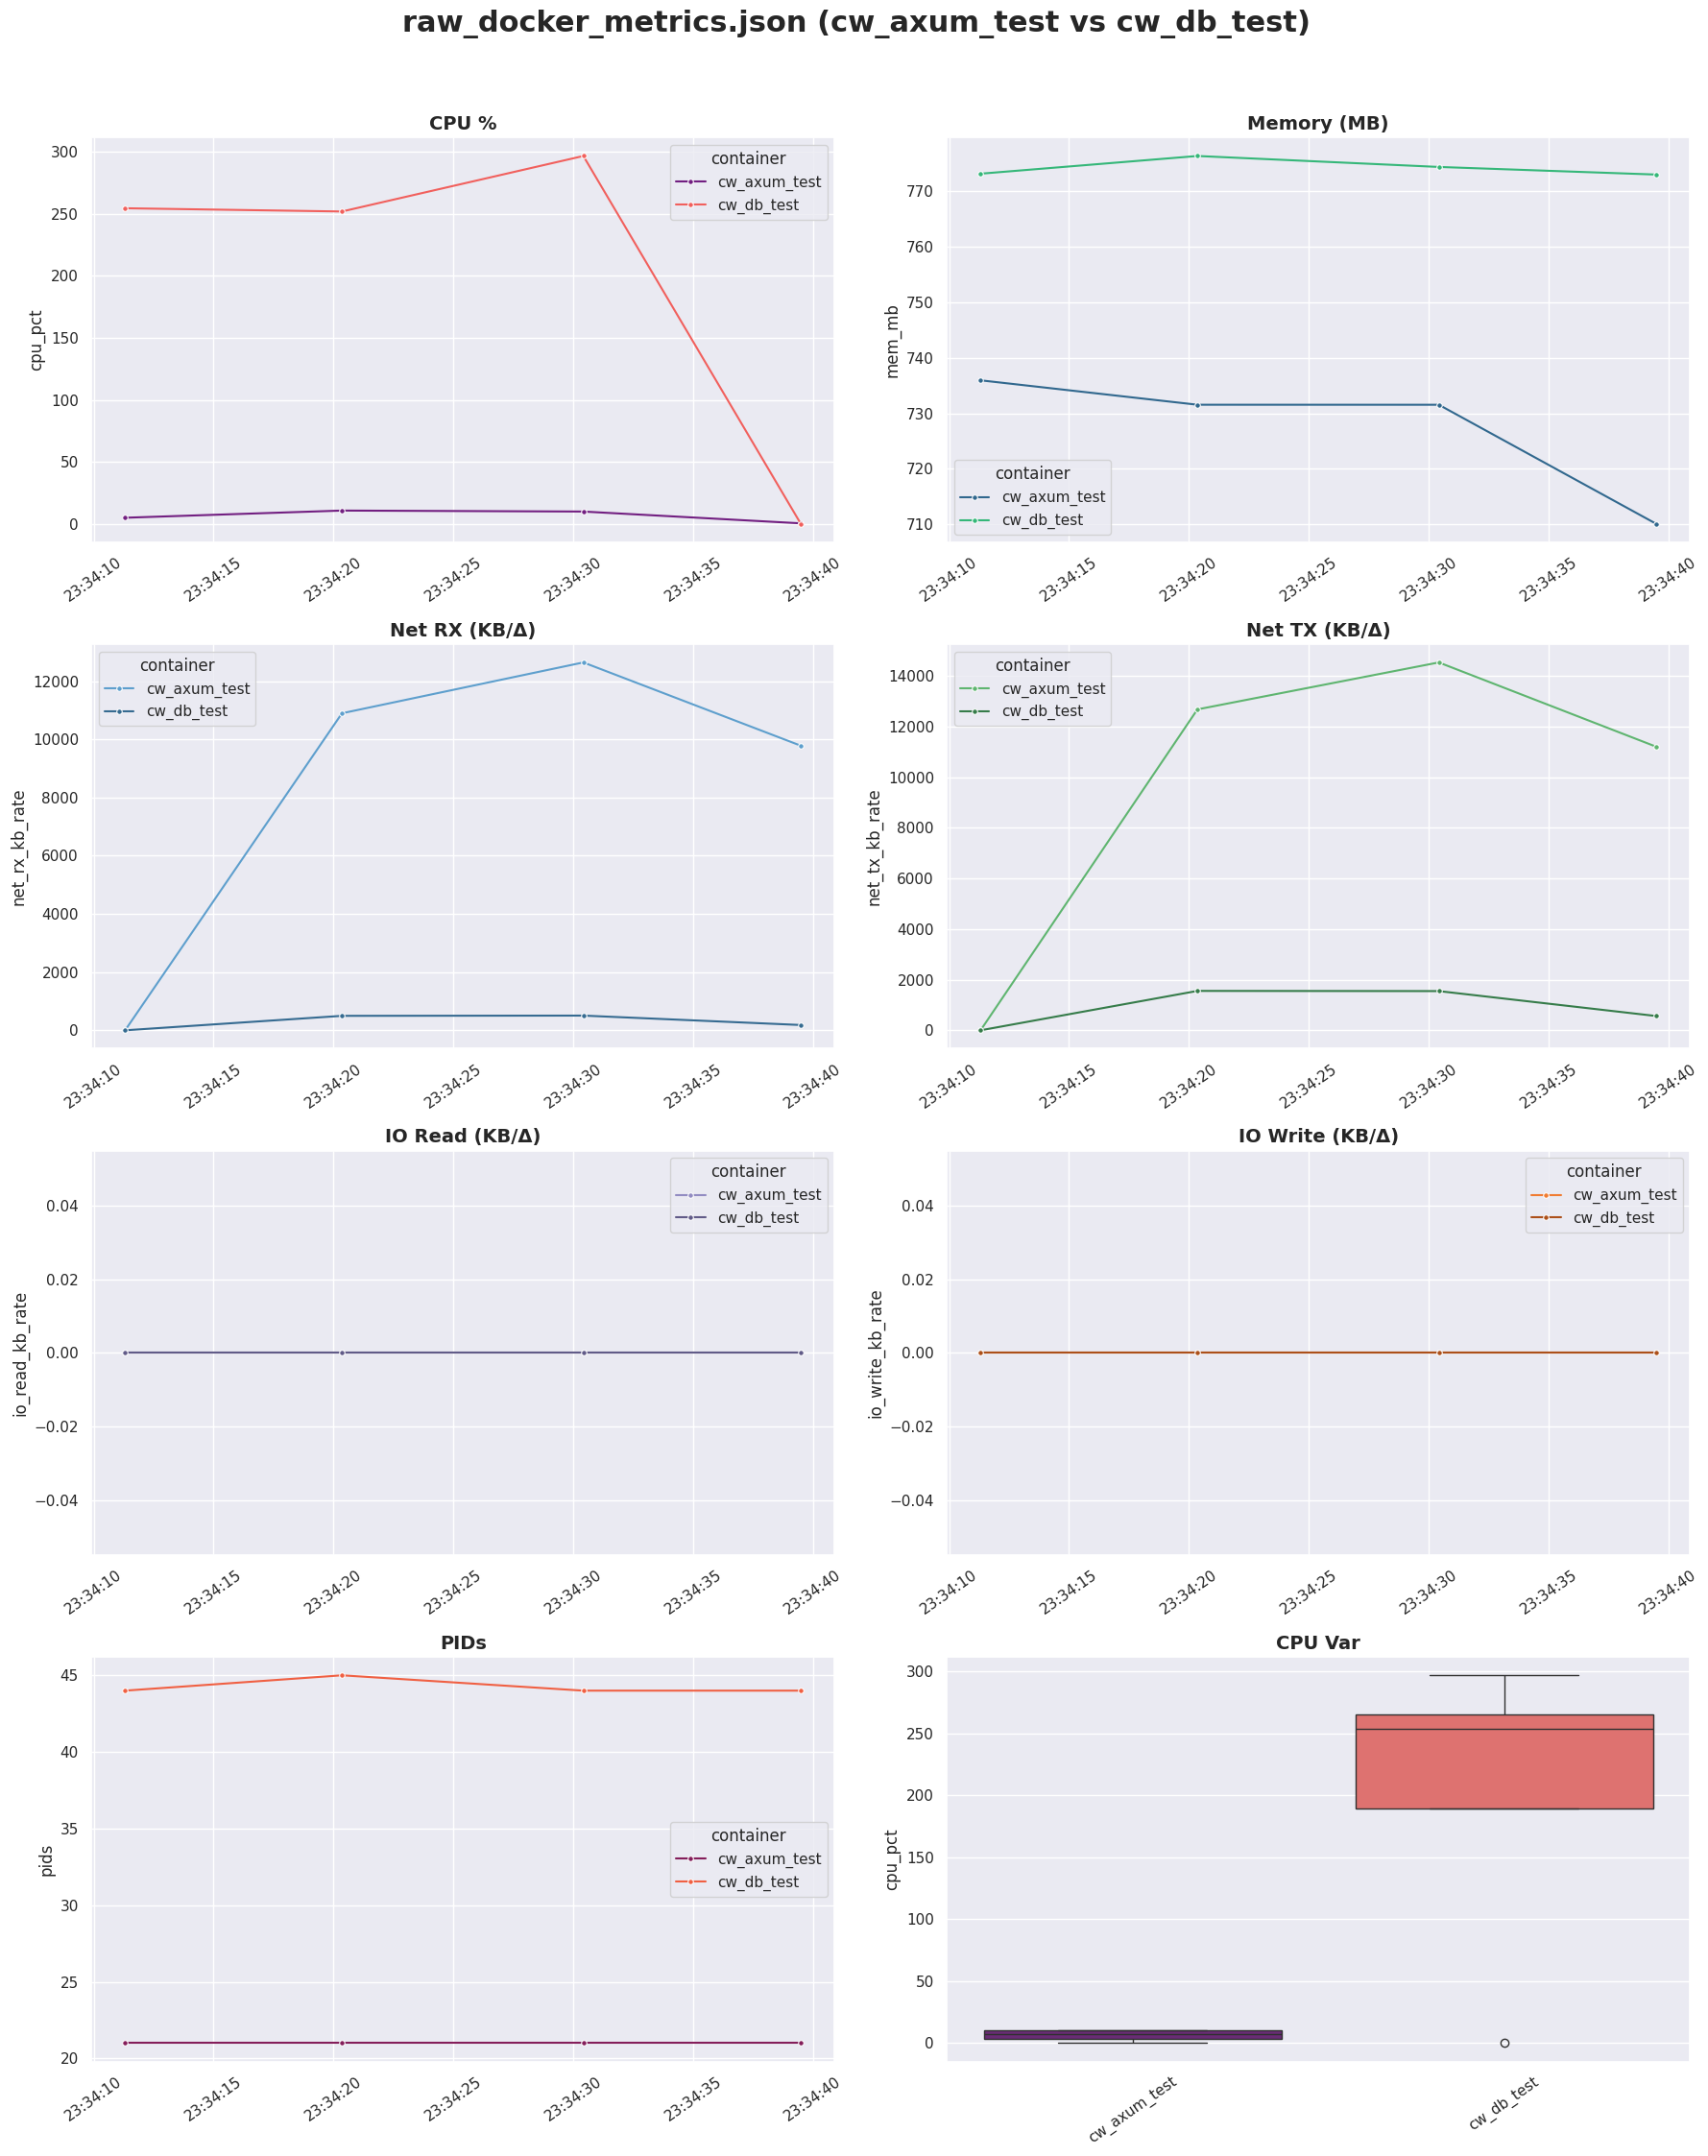

## Test Results

---

--- Grouped Locust Analysis: test_details.json ---
             Endpoint  Requests  Avg RT (ms)    Max_RT        RPS
 /recipes/recipe/{id}      3688     3.480245 61.334529 123.452699
/recipes/recipes/{id}      3676     3.564329 64.067456 122.989301
      /recipes/dishes      1830     3.433486 62.345895  61.275300
Diagram exported as: test_results/locust_v_1_0_0/3/axum/test_details_analysis.png


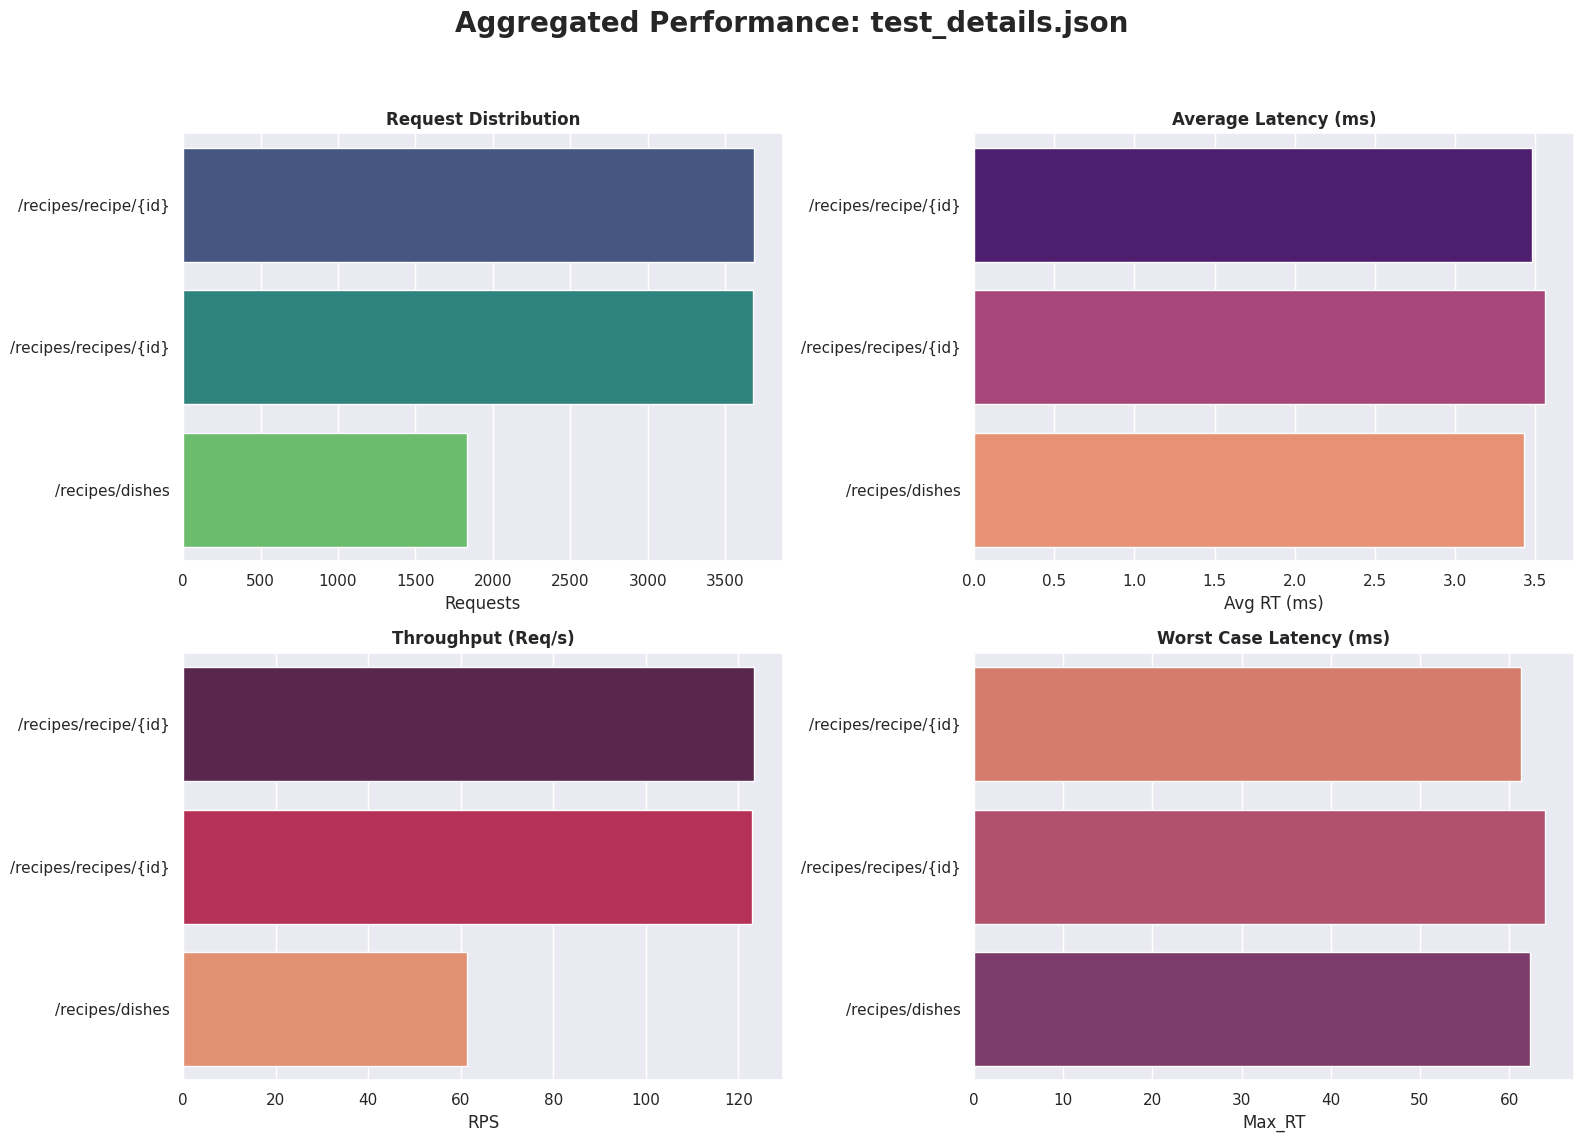

# locust_v_1_0_0 / fastapi

---

## System Usage

---

--- raw_docker_metrics.json ---
                    cpu_pct          mem_mb         pids
                       mean     max    mean     max  max
container                                               
cw_db_test           186.53  259.37  772.45  775.92   45
cw_fastapi_baseline   52.12   63.85  465.02  466.57   32
Diagram exported as: test_results/locust_v_1_0_0/3/fastapi/raw_docker_metrics_analysis.png


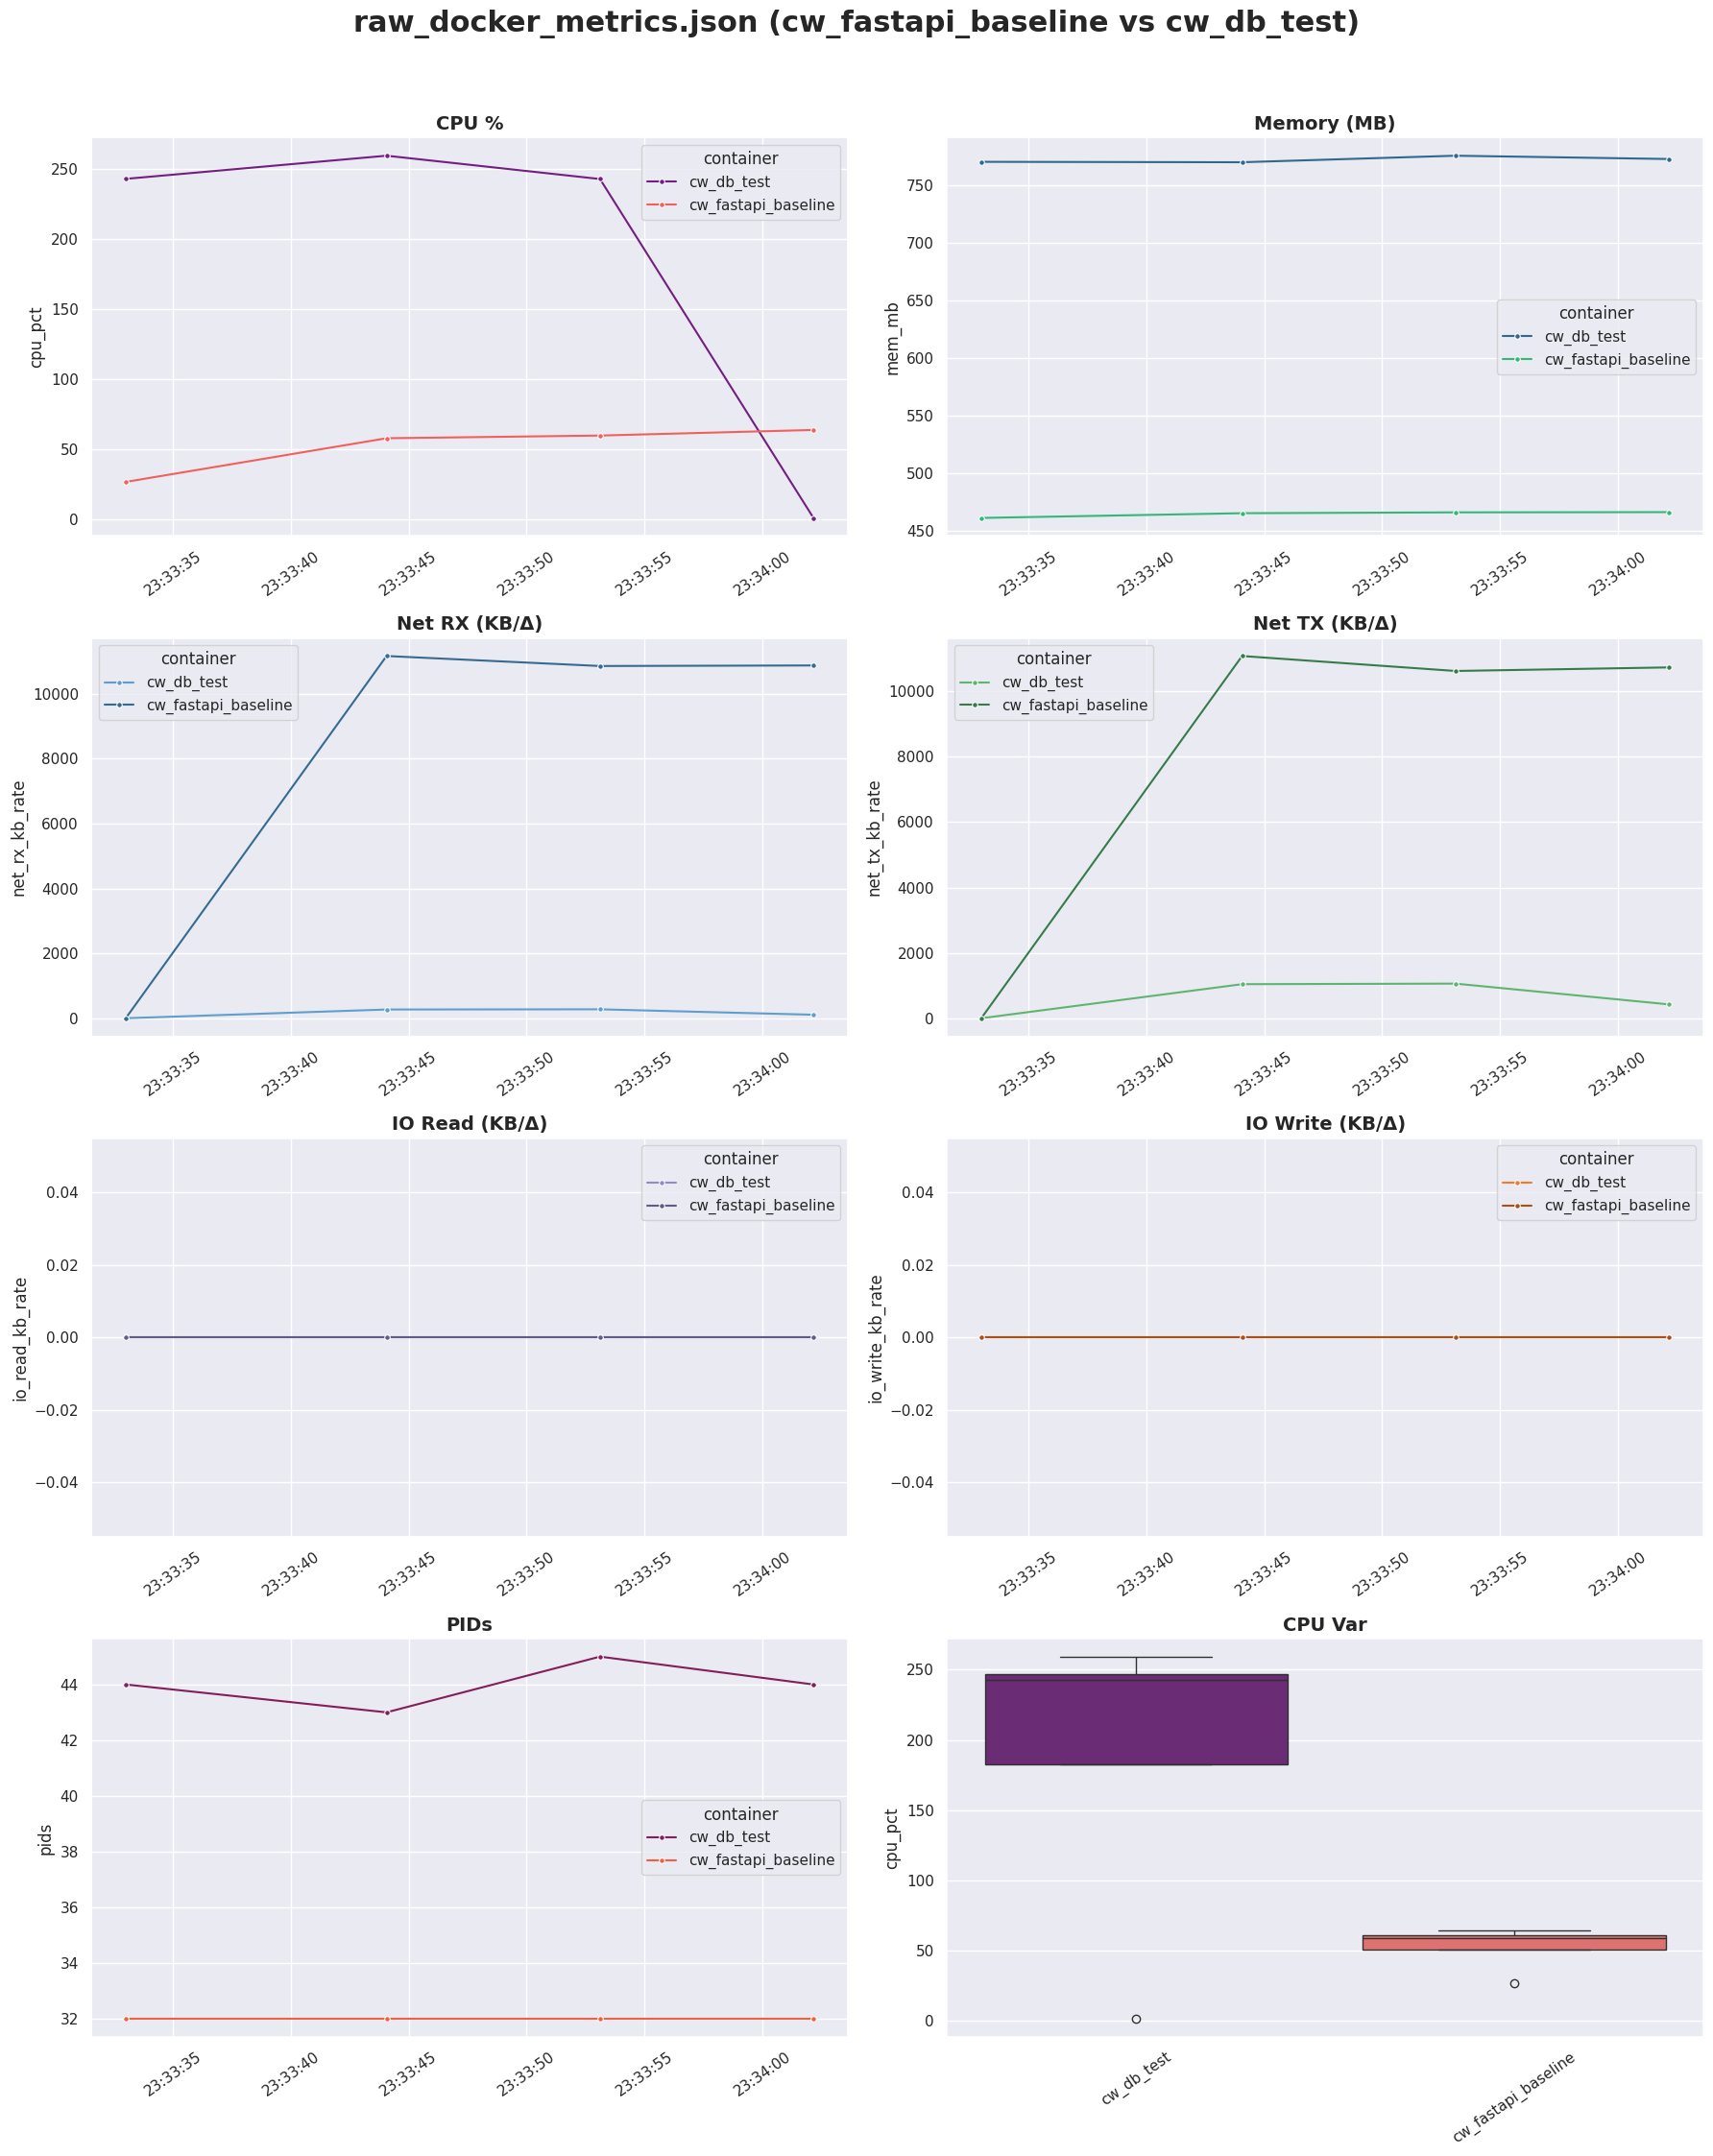

## Test Results

---

--- Grouped Locust Analysis: test_details.json ---
             Endpoint  Requests  Avg RT (ms)    Max_RT        RPS
 /recipes/recipe/{id}      3713     4.855632 64.440831 124.183085
/recipes/recipes/{id}      3635     4.768250 65.346424 121.611070
      /recipes/dishes      1820     4.815429 65.561907  60.845088
Diagram exported as: test_results/locust_v_1_0_0/3/fastapi/test_details_analysis.png


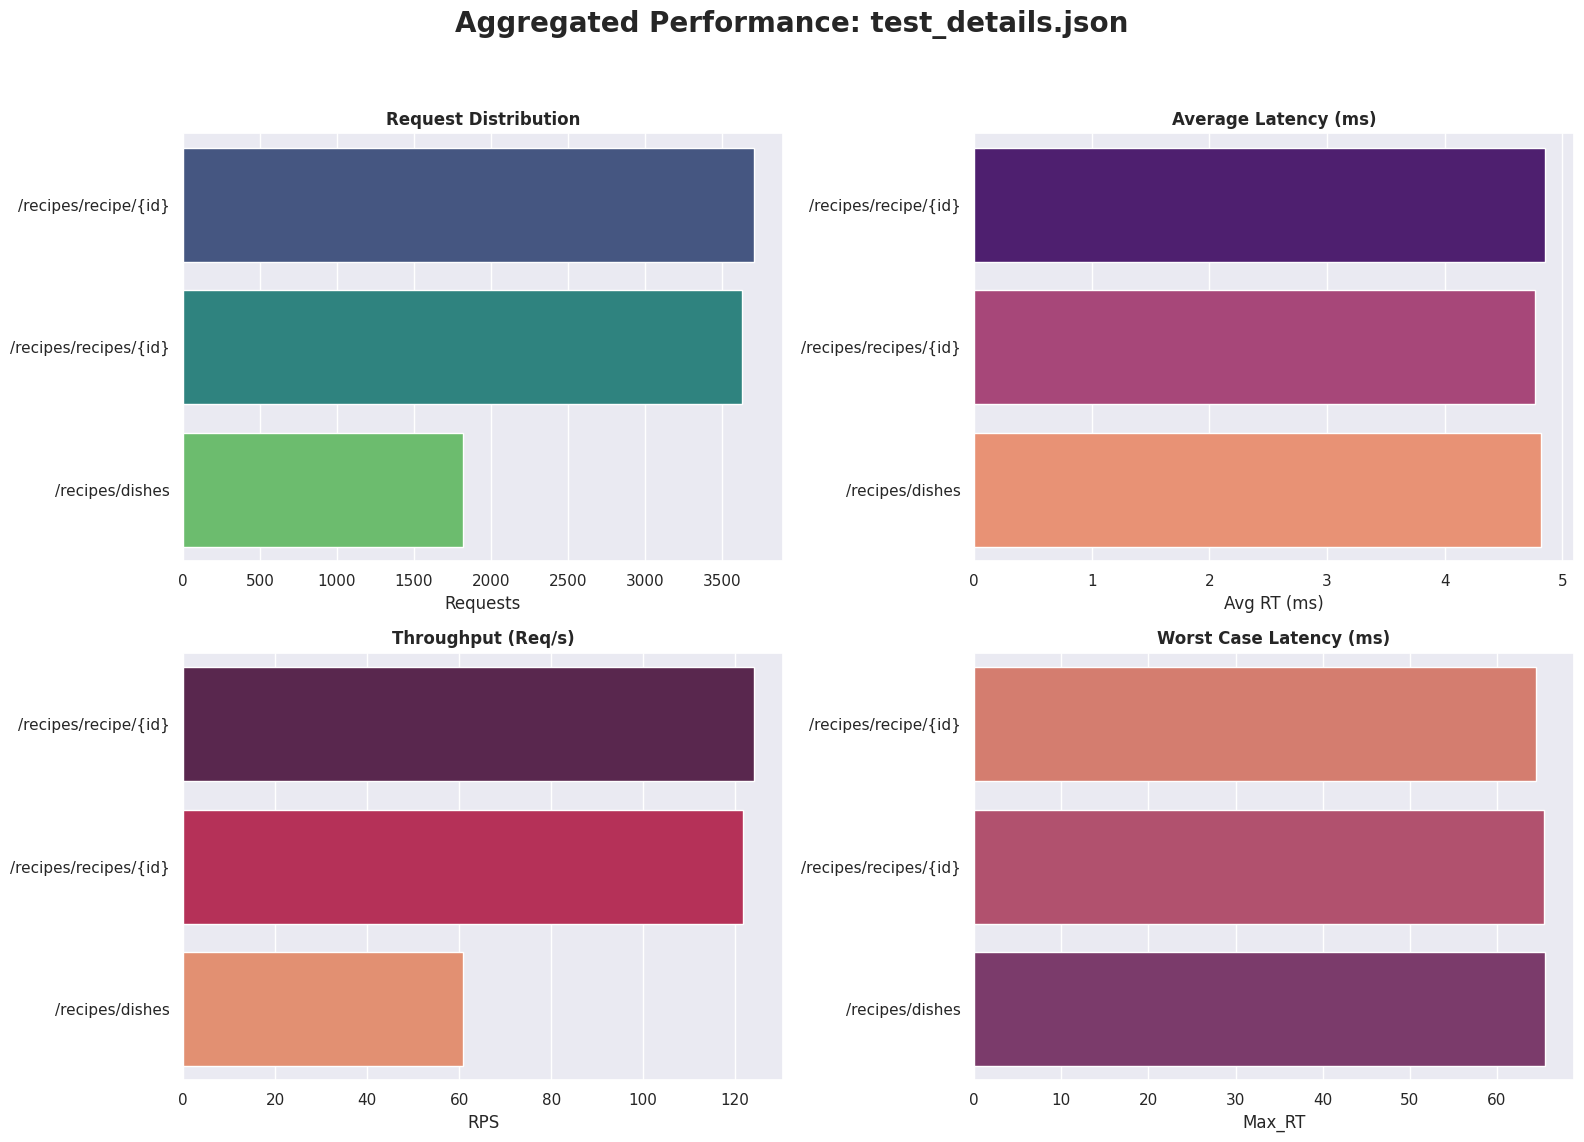

# k6_break_test / axum

---

## System Usage

---

--- raw_docker_metrics.json ---
             cpu_pct          mem_mb         pids
                mean      max   mean     max  max
container                                        
cw_axum_test   25.85    35.28  764.5  779.11   23
cw_db_test    856.90  1063.93  737.3  898.70   85
Diagram exported as: test_results/k6_break_test/3/axum/raw_docker_metrics_analysis.png


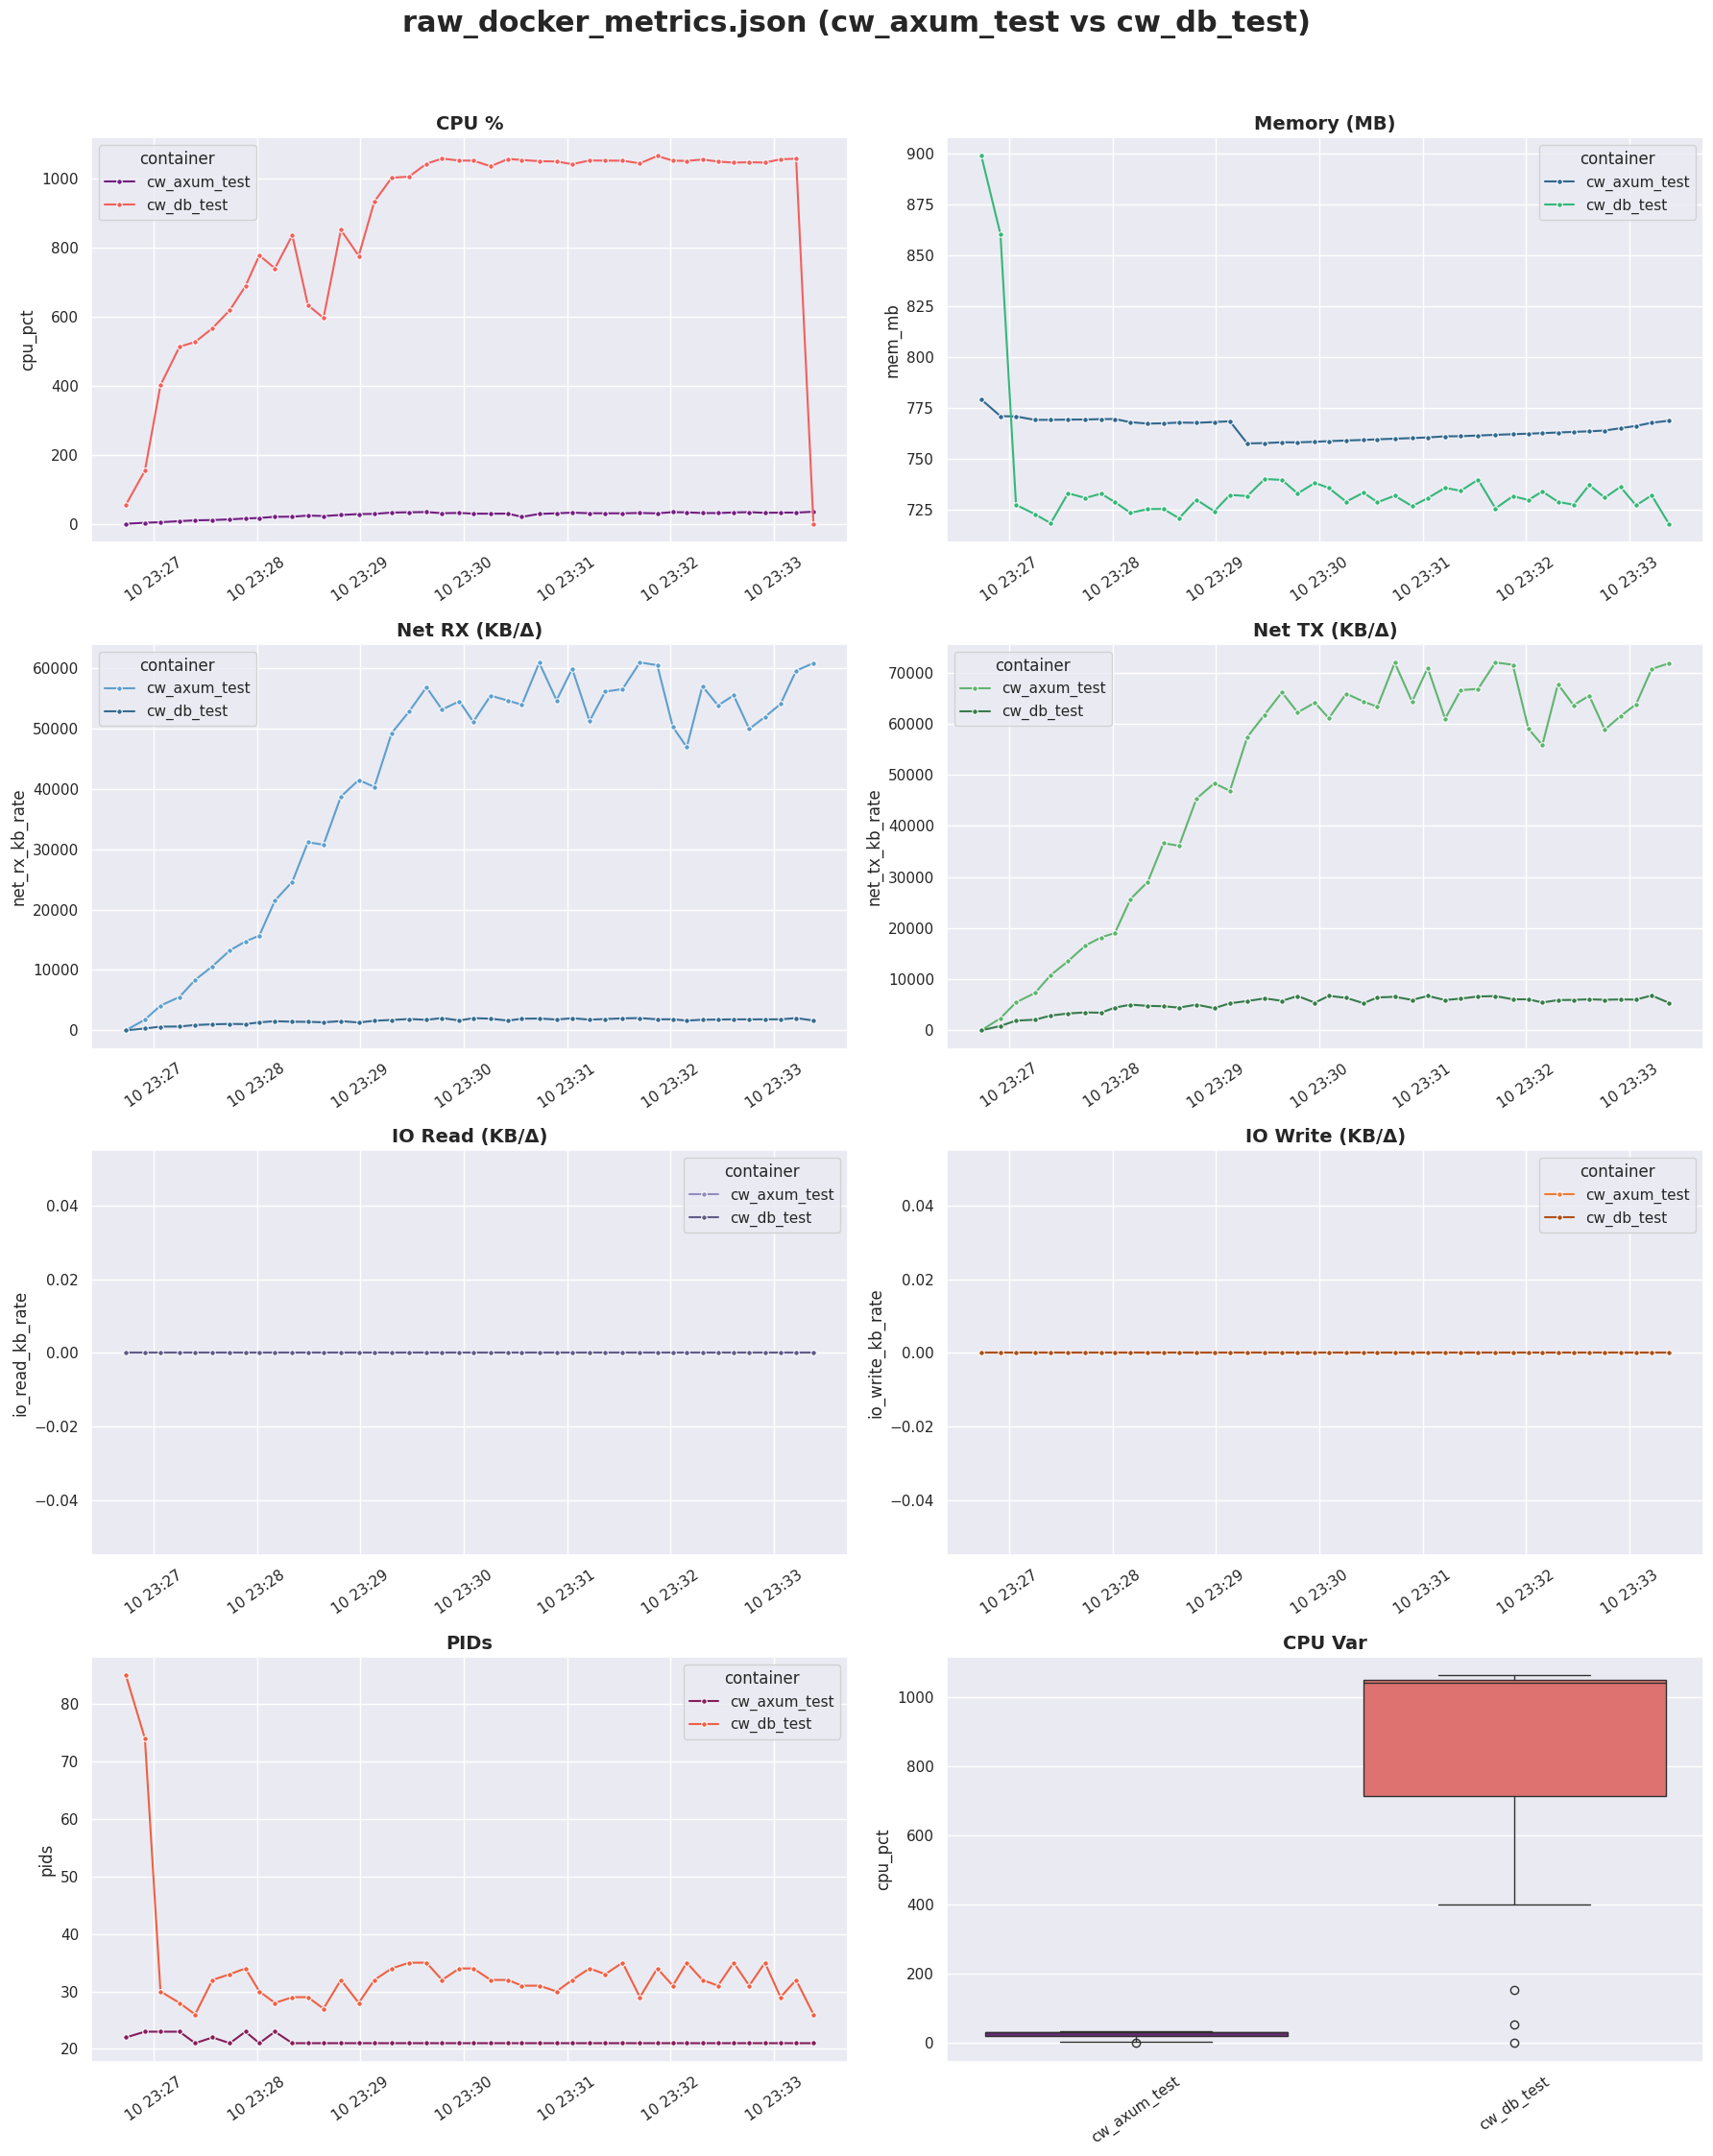

## Test Results

---

 K6 LOAD TEST ANALYSIS: test_details.json
Throughput:      16164.98 req/s
Total Requests:  7,024,122
Max Concurrency: 50000 VUs
Failure Rate:    0.62%
----------------------------------------
Latency (Duration):
  Avg: 199.09ms
  Med: 46.31ms
  p(90): 555.25ms
  p(95): 736.59ms
  Max: 4964.65ms

Diagram exported as: test_results/k6_break_test/3/axum/test_details_analysis.png


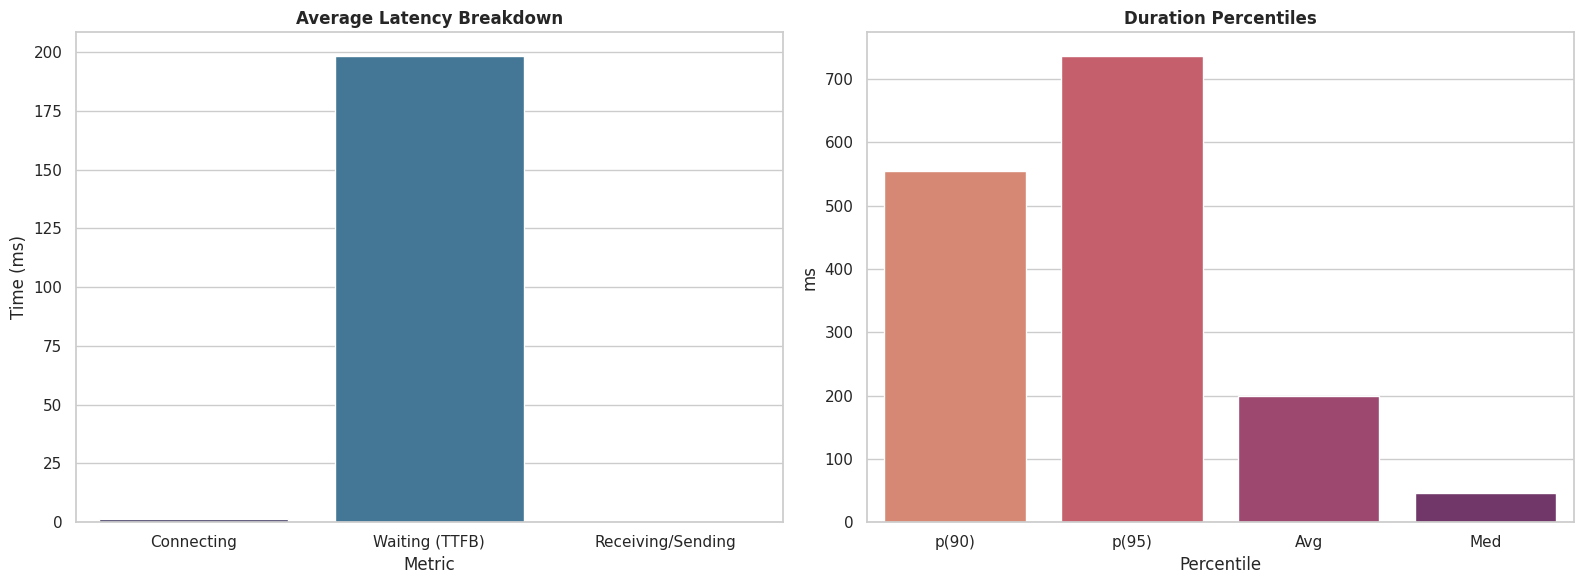

# k6_break_test / fastapi

---

## System Usage

---

--- raw_docker_metrics.json ---
                    cpu_pct           mem_mb          pids
                       mean      max    mean      max  max
container                                                 
cw_db_test           862.42  1457.05  916.12  1023.62  121
cw_fastapi_baseline  217.04   400.42  724.55   748.10   32
Diagram exported as: test_results/k6_break_test/3/fastapi/raw_docker_metrics_analysis.png


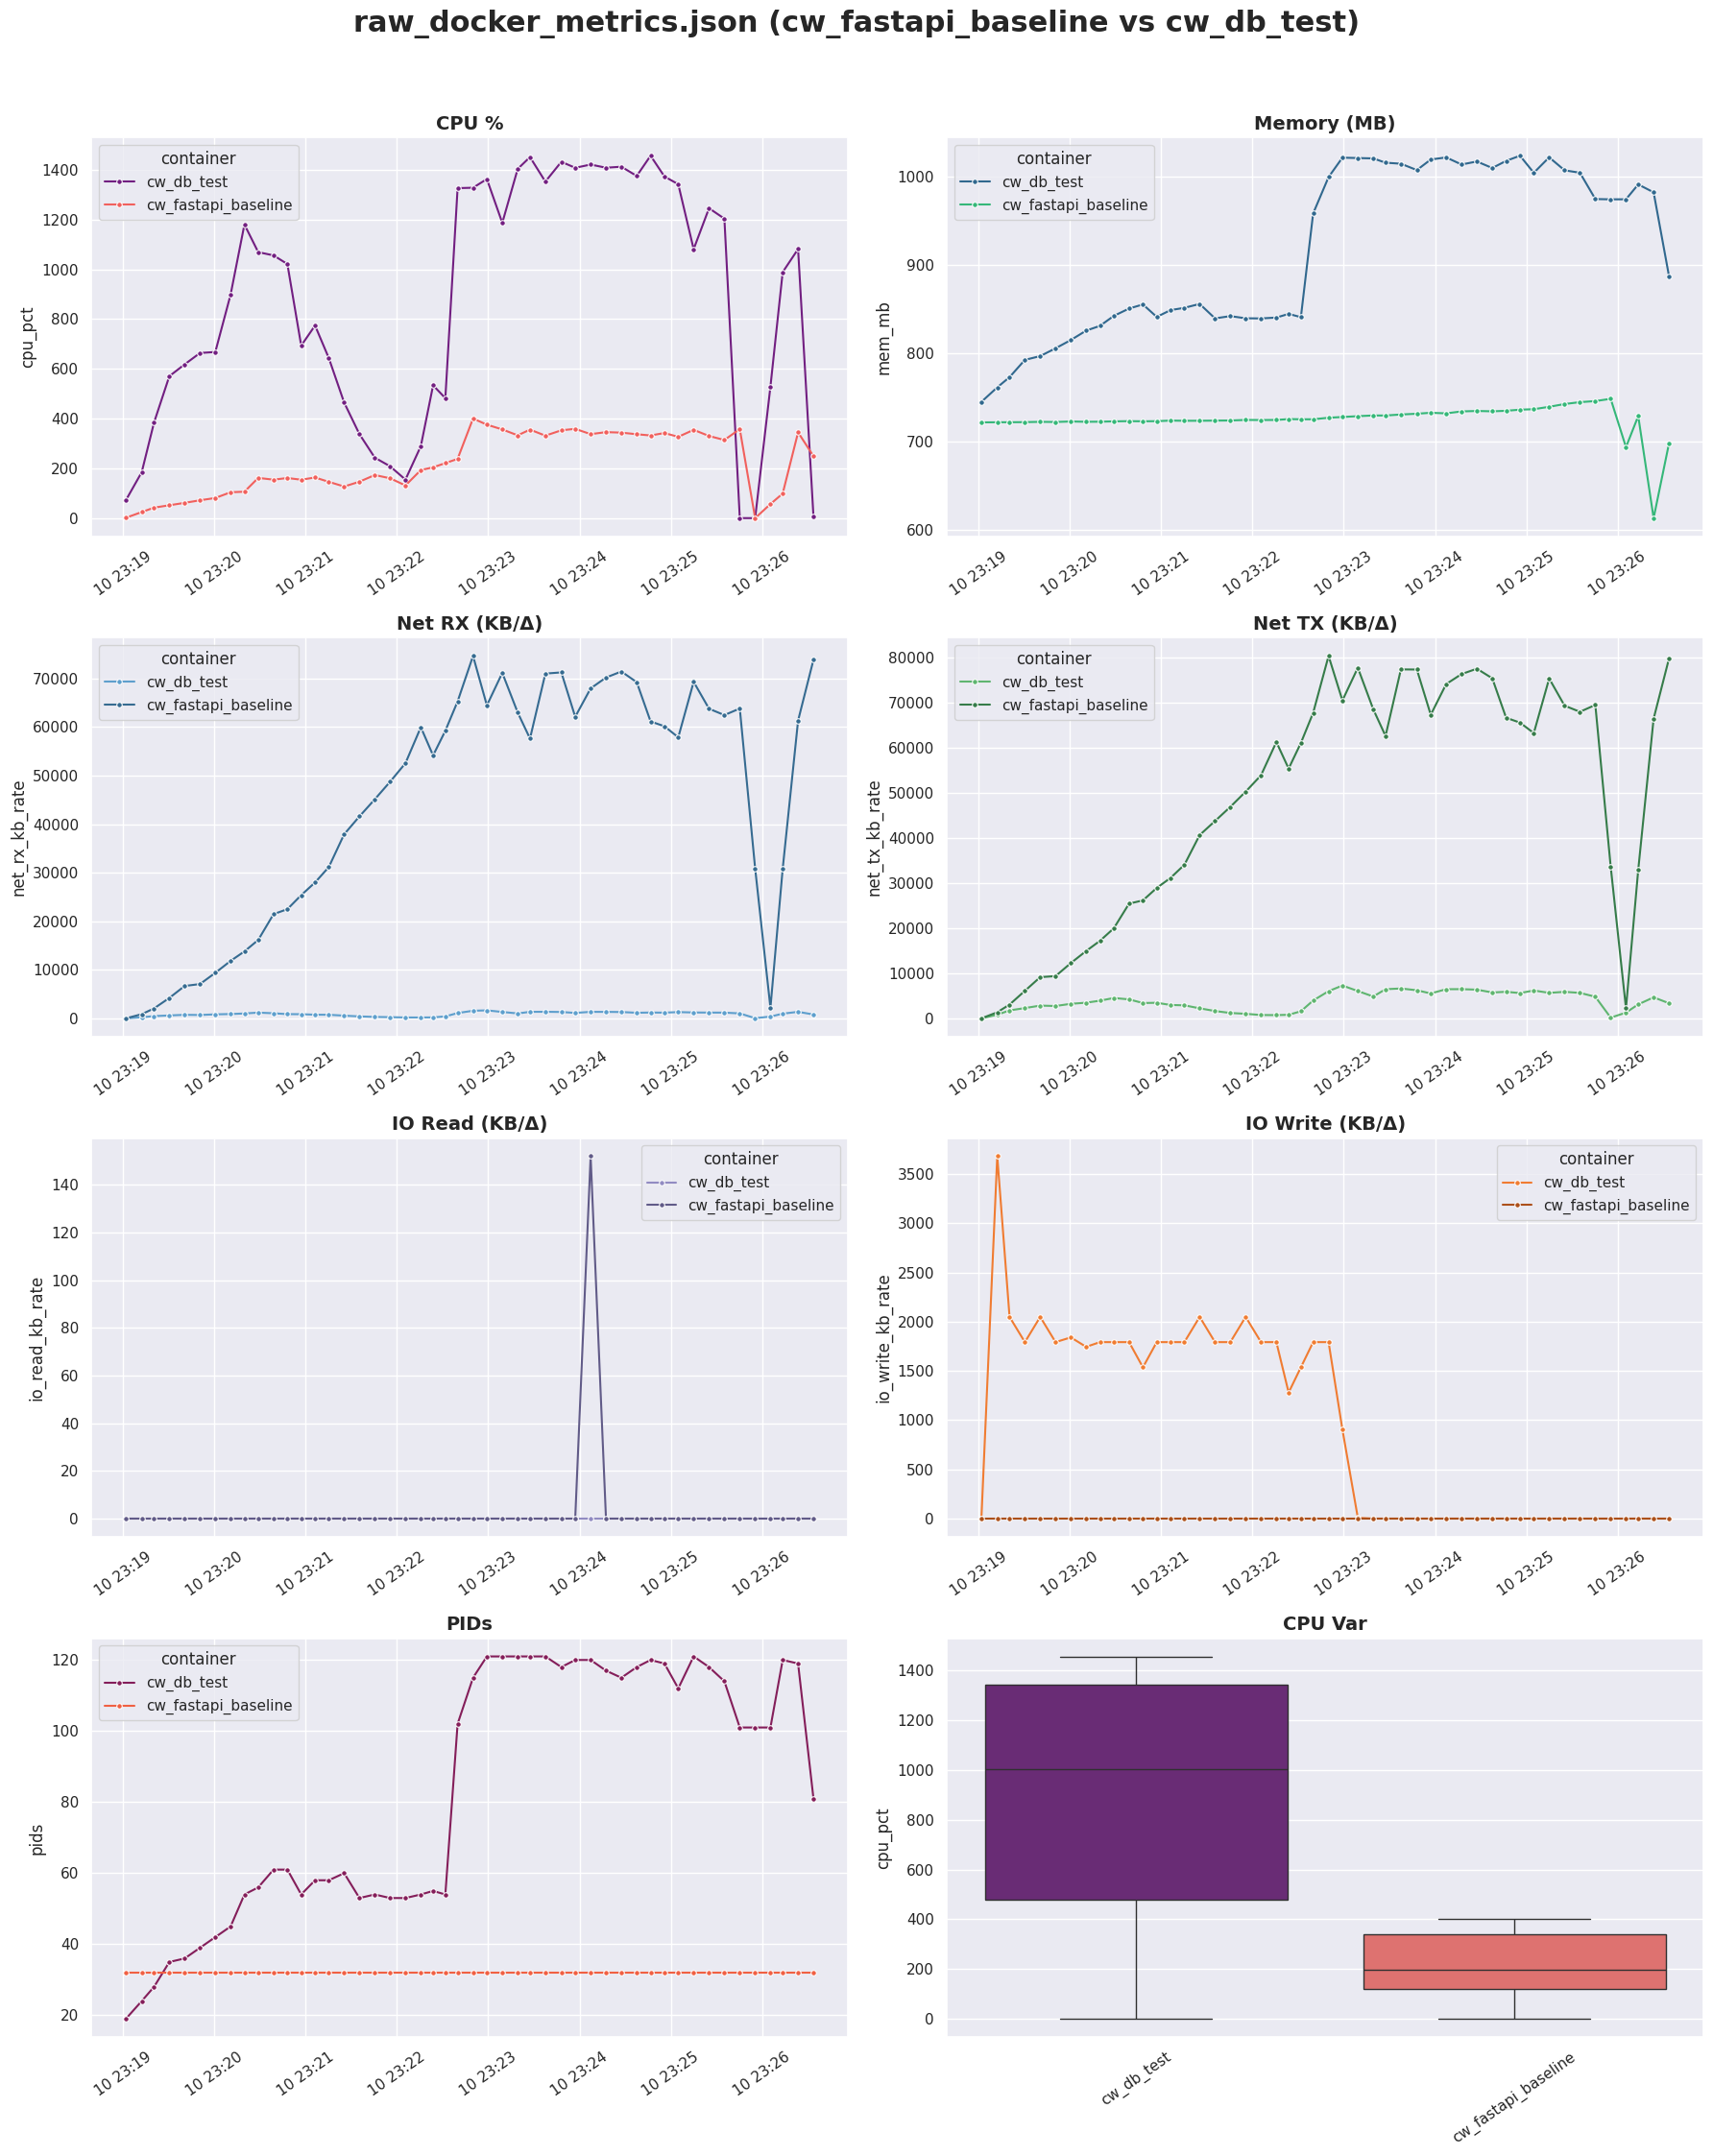

## Test Results

---

 K6 LOAD TEST ANALYSIS: test_details.json
Throughput:      6133.47 req/s
Total Requests:  2,032,002
Max Concurrency: 50000 VUs
Failure Rate:    0.75%
----------------------------------------
Latency (Duration):
  Avg: 865.11ms
  Med: 254.78ms
  p(90): 1148.14ms
  p(95): 1554.31ms
  Max: 62887.60ms

Diagram exported as: test_results/k6_break_test/3/fastapi/test_details_analysis.png


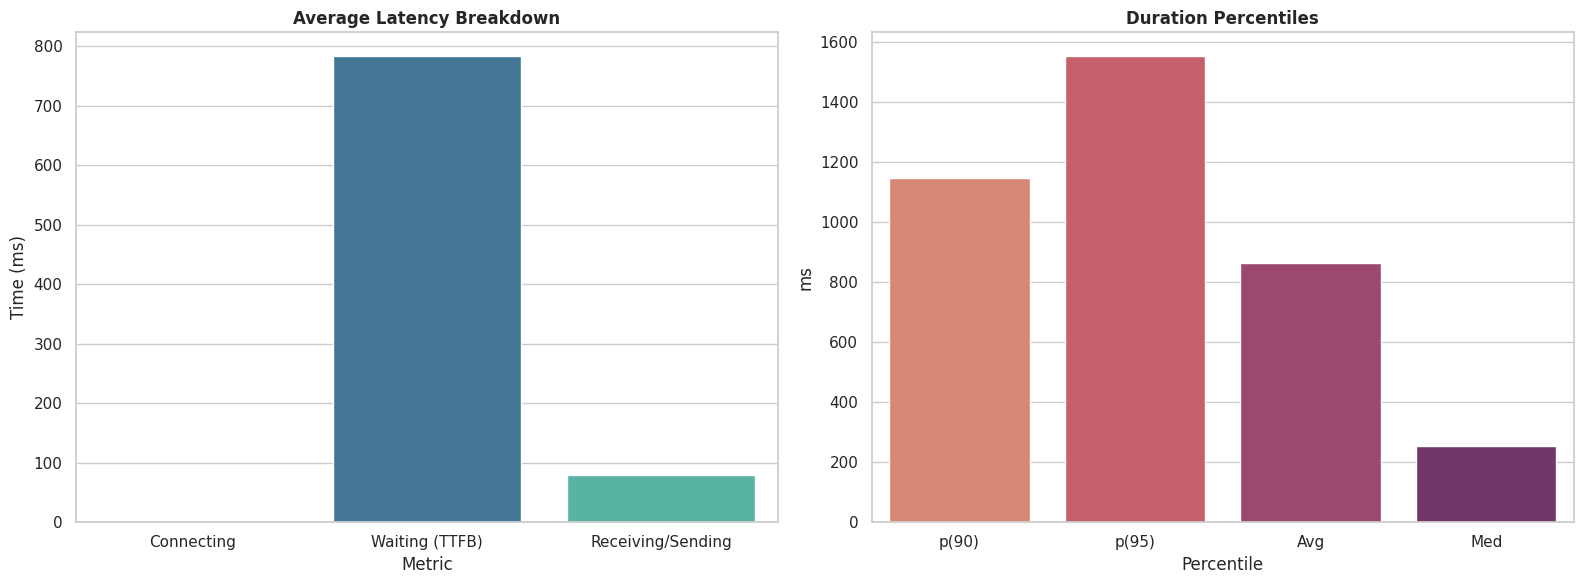

In [6]:

main_folder = Path("test_results")
iteration = 1
test_list  = [f.name for f in main_folder.iterdir()]
display(Markdown(f"# ITERATION 1"))
display(Markdown("---"))
for test in test_list:
    test_path = main_folder.joinpath(test,str(iteration))
    container_list  = [f.name for f in test_path.iterdir()]
    for container in container_list:
        display(Markdown(f"# {test} / {container}"))
        display(Markdown("---"))
        display(Markdown(f"## System Usage"))
        display(Markdown("---"))
        target_dcontainer = f"cw_{container}_test" if not "fastapi" in container else "cw_fastapi_baseline"
        docker_stats_analysis(test_path.joinpath(container,'raw_docker_metrics.json'),target_dcontainer)
        if "hey" in test:
            display(Markdown(f"## Test Results"))
            display(Markdown("---"))
            hey_stats_analysis(test_path.joinpath(container,'test_details.csv'))
            display(Markdown("---"))
        elif "locust" in test:
            display(Markdown(f"## Test Results"))
            display(Markdown("---"))
            locust_stats_analysis(test_path.joinpath(container,'test_details.json'))
        elif "k6" in test:
            display(Markdown(f"## Test Results"))
            display(Markdown("---"))
            k6_stats_analysis(test_path.joinpath(container,'test_details.json'))
iteration = 2   
display(Markdown(f"# ITERATION 2"))
display(Markdown("---"))
for test in test_list:
    test_path = main_folder.joinpath(test,str(iteration))
    if test_path.exists() and test_path.is_dir():
        container_list  = [f.name for f in test_path.iterdir()]
        for container in container_list:
            display(Markdown(f"# {test} / {container}"))
            display(Markdown("---"))
            display(Markdown(f"## System Usage"))
            display(Markdown("---"))
            target_dcontainer = f"cw_{container}_test" if not "fastapi" in container else "cw_fastapi_baseline"
            docker_stats_analysis(test_path.joinpath(container,'raw_docker_metrics.json'),target_dcontainer)
            if "hey" in test:
                display(Markdown(f"## Test Results"))
                display(Markdown("---"))
                hey_stats_analysis(test_path.joinpath(container,'test_details.csv'))
                display(Markdown("---"))
            elif "locust" in test:
                display(Markdown(f"## Test Results"))
                display(Markdown("---"))
                locust_stats_analysis(test_path.joinpath(container,'test_details.json'))
            elif "k6" in test:
                display(Markdown(f"## Test Results"))
                display(Markdown("---"))
                k6_stats_analysis(test_path.joinpath(container,'test_details.json'))
iteration = 3
display(Markdown(f"# ITERATION 3"))
display(Markdown("---"))
for test in test_list:
    test_path = main_folder.joinpath(test,str(iteration))
    if test_path.exists() and test_path.is_dir():
        container_list  = [f.name for f in test_path.iterdir()]
        for container in container_list:
            display(Markdown(f"# {test} / {container}"))
            display(Markdown("---"))
            display(Markdown(f"## System Usage"))
            display(Markdown("---"))
            target_dcontainer = f"cw_{container}_test" if not "fastapi" in container else "cw_fastapi_baseline"
            docker_stats_analysis(test_path.joinpath(container,'raw_docker_metrics.json'),target_dcontainer)
            if "hey" in test:
                display(Markdown(f"## Test Results"))
                display(Markdown("---"))
                hey_stats_analysis(test_path.joinpath(container,'test_details.csv'))
                display(Markdown("---"))
            elif "locust" in test:
                display(Markdown(f"## Test Results"))
                display(Markdown("---"))
                locust_stats_analysis(test_path.joinpath(container,'test_details.json'))
            elif "k6" in test:
                display(Markdown(f"## Test Results"))
                display(Markdown("---"))
                k6_stats_analysis(test_path.joinpath(container,'test_details.json'))

